In [30]:
!pip install -q lightgbm xgboost scikit-learn pandas numpy requests python-dotenv schedule ta joblib pyarrow scipy imbalanced-learn
!pip install -q torch --index-url https://download.pytorch.org/whl/cu121 2>/dev/null || pip install -q torch
print("\u2705 Dependencies installed (v39)")

✅ Dependencies installed (v39)


# JackSparrow v39 — Full Audit Implementation

## Changes vs v38 (Audit close-out)

| # | Area | v38 status | v39 fix |
|---|------|-----------|------------|
| Rec1 | Class imbalance | ATR target added but `USE_ATR_TARGET=False` | **`USE_ATR_TARGET=True`** — ATR-symmetric target now the default |
| Rec2 | Threshold mode | `THRESHOLD_MODE='ev'` — percentile only a fallback | **`THRESHOLD_MODE='oof_percentile'`** — P80/P90 OOF percentile is PRIMARY strategy |
| Rec3 | ATR target | Implemented but disabled | Enabled — `USE_ATR_TARGET=True` is now the audit default |
| Rec4 | Training window | `TARGET_CANDLES_5M=30_000` (~104d) | **`TARGET_CANDLES_5M=60_000`** (~208d) — exceeds 90-day minimum |
| Rec5 | Feature drift | `h1_trend`, `h_trend_200`, `atr_pct` still drifting | **Per-regime model scaffold** added — `USE_REGIME_MODELS` flag + `train_regime_models()` |

## Changes carried forward from v38

| # | Area | v37 issue | v38 fix |
|---|------|-----------|------------|
| R1 | Feature count | 61 features | Reduced to **38** — weakest features removed |
| R2 | Target learnability | Fixed-pct TP only | **ATR-symmetric target** option (`USE_ATR_TARGET`) — now enabled by default in v39 |
| R3 | Threshold logic | Multiple competing sources | **`get_signal_threshold(regime, model)`** — single function, one source of truth |
| R4 | Backtest metrics | Sharpe only | + **Sortino ratio** + **trade expectancy** (EV per trade) |
| R5 | Retraining | Pure rolling → forgetting | **Hybrid anchored+rolling**: `RETRAIN_ANCHOR_BARS` always included |
| R6 | Data validation | Basic only | + **candle gap detector** + **price spike filter** |
| R7 | Export | v34 artifact refs | Fixed to **v38** |
| R8 | Dead code | Several dead assigns | Removed |

## Architecture (unchanged)
LGBM-only ✓ | Walk-forward gap=200 ✓ | KS+PSI drift ✓ | OOS retrain gate ✓ | Crisis=flat ✓

In [31]:
# -- GPU Detection & Setup (FIX 8: advisory if no GPU) ----------------------
import subprocess, os, torch

def _detect_gpu():
    """Returns ('cuda', device_name) or ('cpu', 'CPU')."""
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        print(f'  🟢 GPU detected: {name}')
        print(f'     CUDA {torch.version.cuda} | VRAM {torch.cuda.get_device_properties(0).total_memory // 1024**2} MB')
        return 'cuda', name
    print('  🟡 No GPU -- falling back to CPU')
    print('  ⚠️  FIX 8: Training will be SLOW on CPU (especially walk-forward).')
    print('     → In Colab: Runtime ▸ Change runtime type ▸ Select T4 GPU ▸ Reconnect')
    return 'cpu', 'CPU'

GPU_DEVICE, GPU_NAME = _detect_gpu()
USE_GPU = (GPU_DEVICE == 'cuda')

# LightGBM device string
LGBM_DEVICE   = 'gpu'  if USE_GPU else 'cpu'
# XGBoost device string
XGB_DEVICE    = 'cuda' if USE_GPU else 'cpu'
# Torch device
TORCH_DEVICE  = torch.device('cuda' if USE_GPU else 'cpu')

print(f'\n✅ GPU config: LGBM={LGBM_DEVICE} | XGB={XGB_DEVICE} | Torch={TORCH_DEVICE}')
print(f'   MLP will train on: {TORCH_DEVICE}')

  🟡 No GPU -- falling back to CPU
  ⚠️  FIX 8: Training will be SLOW on CPU (especially walk-forward).
     → In Colab: Runtime ▸ Change runtime type ▸ Select T4 GPU ▸ Reconnect

✅ GPU config: LGBM=cpu | XGB=cpu | Torch=cpu
   MLP will train on: cpu


In [32]:
import os, random
import numpy as _np_seed

SEED = 42
random.seed(SEED)
_np_seed.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

try:
    from google.colab import userdata
    API_KEY    = userdata.get('DELTA_API_KEY')
    API_SECRET = userdata.get('DELTA_API_SECRET')
except Exception:
    API_KEY    = os.getenv('DELTA_API_KEY', 'YOUR_KEY_HERE')
    API_SECRET = os.getenv('DELTA_API_SECRET', 'YOUR_SECRET_HERE')

BASE_URL = 'https://api.india.delta.exchange'
SYMBOL_5M = SYMBOL_15M = SYMBOL_1H = 'BTCUSD'
PRODUCT_ID = 27

CANDLE_RES_5M = '5m'; CANDLE_RES_15M = '15m'; CANDLE_RES_1H = '1h'
TARGET_CANDLES_5M = 60_000; TARGET_CANDLES_15M = 20_000; TARGET_CANDLES_1H = 3_000
WARMUP_CANDLES = 50; TARGET_FUNDING_BARS = 5_025

RETRAIN_INTERVAL_MINUTES = 60; MIN_TRAIN_SAMPLES = 500; WALK_FORWARD_SPLITS = 5
SIGNAL_THRESHOLD = 0.15

CAPITAL_USDT = 1000.0; MAKER_FEE = 0.0005; TAKER_FEE = 0.0005
SLIPPAGE_PCT = 0.0003; MAX_POSITION_PCT = 0.20

# ── v37 CRITICAL FIX: TP/SL Risk-Reward Ratio ──────────────────────────────────
# PROBLEM in v36: TP=1.2% / SL=1.0% at 5x leverage
#   Round-trip cost = 2*(0.0005+0.0003)*5 = 0.80%
#   Net gain per win  = 1.2% - 0.8% = 0.4%   (at 1x capital exposure = 2.0% at 5x)
#   Net loss per loss = 1.0% + 0.8% = 1.8%   (at 1x capital exposure = 9.0% at 5x)
#   Breakeven WR = net_loss/(net_gain+net_loss) = 1.8/2.2 = 81.8% → IMPOSSIBLE
#
# FIX in v37: TP=2.5% / SL=1.0% at 5x leverage
#   Net gain per win  = 2.5% - 0.8% = 1.7%
#   Net loss per loss = 1.0% + 0.8% = 1.8%
#   Breakeven WR = 1.8 / (1.7+1.8) = 51.4% — achievable for a trained ML model
#   At 55% WR → expected value per trade = 0.55*1.7% - 0.45*1.8% = +0.125% → profitable
STOP_LOSS_PCT    = 0.010   # 1.0% SL — kept tight
TAKE_PROFIT_PCT  = 0.025   # 2.5% TP (was 1.2% — fix critical R/R math)
LEVERAGE         = 5
TP_SL_TARGET_HORIZON = 120  # 120 bars = 10h at 5m — longer window finds more 2.5% TPs

BACKTEST_DAYS = 60
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Version string — single source of truth (Fix 2) ─────────────────────────
MODEL_VERSION        = 'v39'
MODEL_ARTIFACT_PATH  = f'{MODEL_DIR}/model_artifact_{MODEL_VERSION}.pkl'
MODEL_METADATA_PATH  = f'{MODEL_DIR}/metadata_{MODEL_VERSION}.json'
EXPORT_ZIP_NAME      = f'JackSparrow_{MODEL_VERSION}_models'

# ── v37 NEW: OOS gap — prevents rolling-window contamination at split boundary ──
# The first OOS_GAP_BARS rows share rolling features (EMA, RSI, ATR etc.) computed
# partly from training-period data. Skip these to get genuinely out-of-sample rows.
# Set to match the walk-forward CV gap=200, with 10 bar buffer.
OOS_GAP_BARS = 210

RETRAIN_WINDOW_PAST_BARS = 3800; RETRAIN_WINDOW_RECENT_BARS = 2000
RETRAIN_DRIFT_FEATURE_LIMIT = 5; RETRAIN_CYCLES = 3

# ── v37 FIX: Retrain WR gate adjusted for new 2.5% TP / 1.0% SL ──────────────
# Breakeven WR at new R/R ≈ 51.4%. Gate at 38% gives margin to accept models
# during low-signal periods without creating an operational deadlock.
RETRAIN_VALIDATION_MIN_AUC = 0.51
RETRAIN_VALIDATION_MIN_WR  = 38.0   # was 45.0 — matched to new R/R breakeven

LONG_ONLY_EXECUTION  = True
REQUIRE_FUNDING_DATA = True

ENABLE_PROB_DIAGNOSTICS = True; USE_DYNAMIC_THRESHOLD = True; ENABLE_TARGET_REPORT = True

USE_RAW_BLEND          = True
FEE_ADJUSTED_TARGET    = True
ENABLE_SHORT_EXECUTION = False

# Derived cost constants
ROUND_TRIP_COST_PCT = 2 * (MAKER_FEE + SLIPPAGE_PCT) * LEVERAGE   # 0.80% at 5x
FEE_ADJUSTED_TP_PCT = TAKE_PROFIT_PCT + ROUND_TRIP_COST_PCT        # 3.30%

USE_META_LEARNER     = False
USE_PROB_CALIBRATION = False

PSI_THRESHOLD = 0.20; REGIME_WINDOW = 100; MLP_HIDDEN_LAYERS = (128, 64, 32)
RETRAIN_WARMSTART = True; RETRAIN_PERF_DECAY = 0.95
SIGNAL_THRESHOLD_LONG  = SIGNAL_THRESHOLD
SIGNAL_THRESHOLD_SHORT = 1.0 - SIGNAL_THRESHOLD

TRADING_AGENT_ROOT = os.getenv('TRADING_AGENT_ROOT', '').strip()
if TRADING_AGENT_ROOT:
    import sys
    from pathlib import Path as _P
    _rp = _P(TRADING_AGENT_ROOT).resolve()
    if str(_rp) not in sys.path: sys.path.insert(0, str(_rp))

_strict_env = os.getenv('STRICT_CANDLES', '')
STRICT_CANDLES = bool(TRADING_AGENT_ROOT) if _strict_env == '' else (_strict_env != '0')
FETCH_PAGE_RETRIES = int(os.getenv('FETCH_PAGE_RETRIES', '3'))
MAX_DRAWDOWN_HALT = 0.15; CRISIS_VOL_THRESHOLD = 3.0; CRISIS_VOL_OF_VOL_THRESH = 2.0
REGIME_EMA_SPAN = 12; REGIME_MIN_BARS = 6

# ── v37: Breakeven WR diagnostic ─────────────────────────────────────────────
_net_gain = TAKE_PROFIT_PCT - ROUND_TRIP_COST_PCT
_net_loss = STOP_LOSS_PCT   + ROUND_TRIP_COST_PCT
_be_wr    = _net_loss / (_net_gain + _net_loss)
# v38: config print moved to end (below new settings)
print(f'   v37 R/R FIX: TP={TAKE_PROFIT_PCT*100:.1f}% SL={STOP_LOSS_PCT*100:.1f}% @ {LEVERAGE}x leverage')
print(f'   Round-trip cost : {ROUND_TRIP_COST_PCT*100:.2f}% | Net gain/win: +{_net_gain*100:.2f}% | Net loss/loss: -{_net_loss*100:.2f}%')
print(f'   Breakeven WR    : {_be_wr*100:.1f}% (was ~82% with old 1.2% TP — now achievable at ~51%)')
print(f'   Fee-adjusted TP : {FEE_ADJUSTED_TP_PCT*100:.3f}%')
print(f'   OOS gap         : {OOS_GAP_BARS} bars (~{OOS_GAP_BARS*5//60}h) — prevents split-boundary contamination')
print(f'   Retrain gate    : AUC>={RETRAIN_VALIDATION_MIN_AUC} | WR>={RETRAIN_VALIDATION_MIN_WR}% (adjusted for 2.5% TP)')
print(f'   Symbol: {SYMBOL_5M} | Leverage: {LEVERAGE}x | Capital: ${CAPITAL_USDT}')
# ── v38 NEW: ATR-based symmetric target ──────────────────────────────────────
# USE_ATR_TARGET=True  → TP = ATR_MULT_TP * ATR(14), SL = ATR_MULT_SL * ATR(14)
#   Goal: positive class ≈ 35-42% (symmetric R/R → ~50% theoretical hit rate)
# USE_ATR_TARGET=False → use TAKE_PROFIT_PCT / STOP_LOSS_PCT (v37 mode)
USE_ATR_TARGET   = True    # Rec3: ATR-symmetric target — audit default (targets ~40% positive rate)
ATR_MULT_TP      = 1.0     # TP = 1.0 × ATR(14)
ATR_MULT_SL      = 1.0     # SL = 1.0 × ATR(14) — symmetric, ~40% theoretical positive rate
ATR_PERIOD_TARGET= 14      # ATR period used in target generation

# ── v38 NEW: Hybrid anchored + rolling retraining ────────────────────────────
# RETRAIN_ANCHOR_BARS: how many bars from the BEGINNING of the full dataset
# are always included in every retrain window (prevents catastrophic forgetting).
# Combined with the recent rolling window (RETRAIN_WINDOW_RECENT_BARS).
# Set 0 to revert to pure rolling (v37 behavior).
RETRAIN_ANCHOR_BARS = 5000   # ~17 days of 5m bars always anchored in retrain

# ── v39 Rec2: Threshold mode — P80/P90 OOF-percentile as PRIMARY strategy ──
# Audit gap: ev mode was default; percentile was only a fallback on negative EV.
# Now oof_percentile is the PRIMARY mode as recommended by the audit.
THRESHOLD_MODE              = 'oof_percentile'  # Rec2: was 'ev' — now percentile-first
THRESHOLD_OOF_PERCENTILE    = 80                # primary: P80 of OOF proba
THRESHOLD_MAX_OOF_PERCENTILE= 90                # cap: never exceed P90

print('✅ Config loaded — v39')
print(f'   v38 ATR target: USE_ATR_TARGET={USE_ATR_TARGET} | mult TP={ATR_MULT_TP} SL={ATR_MULT_SL}')
print(f'   v38 Hybrid retrain anchor: {RETRAIN_ANCHOR_BARS:,} bars')
print(f'   v39 Rec2: THRESHOLD_MODE={THRESHOLD_MODE!r} | P{THRESHOLD_OOF_PERCENTILE}–P{THRESHOLD_MAX_OOF_PERCENTILE}')

# ── Fix 1: ATR-adaptive execution levels (eliminates train/execute mismatch) ──
def _resolve_execution_levels(entry_price: float, df_bar=None) -> tuple:
    """
    Return (sl_price, tp_price) for a new trade entry.

    When USE_ATR_TARGET=True, execution levels mirror the training labels:
        TP = entry + ATR_MULT_TP * ATR(14)
        SL = entry - ATR_MULT_SL * ATR(14)
    When USE_ATR_TARGET=False, fall back to fixed STOP_LOSS_PCT / TAKE_PROFIT_PCT.
    """
    if USE_ATR_TARGET and df_bar is not None and 'label_atr' in (df_bar.index if hasattr(df_bar, 'index') else []):
        atr_val  = float(df_bar['label_atr'])
        sl_price = entry_price - ATR_MULT_SL * atr_val
        tp_price = entry_price + ATR_MULT_TP * atr_val
    else:
        sl_price = entry_price * (1 - STOP_LOSS_PCT)
        tp_price = entry_price * (1 + TAKE_PROFIT_PCT)
    return sl_price, tp_price

   v37 R/R FIX: TP=2.5% SL=1.0% @ 5x leverage
   Round-trip cost : 0.80% | Net gain/win: +1.70% | Net loss/loss: -1.80%
   Breakeven WR    : 51.4% (was ~82% with old 1.2% TP — now achievable at ~51%)
   Fee-adjusted TP : 3.300%
   OOS gap         : 210 bars (~17h) — prevents split-boundary contamination
   Retrain gate    : AUC>=0.51 | WR>=38.0% (adjusted for 2.5% TP)
   Symbol: BTCUSD | Leverage: 5x | Capital: $1000.0
✅ Config loaded — v39
   v38 ATR target: USE_ATR_TARGET=True | mult TP=1.0 SL=1.0
   v38 Hybrid retrain anchor: 5,000 bars
   v39 Rec2: THRESHOLD_MODE='oof_percentile' | P80–P90


In [33]:
import time
import hmac
import hashlib
import os
import sys
import requests
import pandas as pd
import numpy as np
from pathlib import Path as _Path
from datetime import datetime, timezone, timedelta
from typing import Optional

validate_candles = None
try:
    from agent.data.candle_validation import validate_candles
except ImportError:
    pass


def _resolve_validate_candles():
    """Load validate_candles from repo (TRADING_AGENT_ROOT or cwd parents)."""
    global validate_candles
    if validate_candles is not None:
        return validate_candles
    roots = []
    r = os.environ.get("TRADING_AGENT_ROOT", "").strip()
    if r:
        roots.append(_Path(r).resolve())
    here = _Path.cwd().resolve()
    for p in (here, here.parent, here.parent.parent):
        roots.append(p)
    seen = set()
    for base in roots:
        if base in seen:
            continue
        seen.add(base)
        if not base.exists():
            continue
        mod = base / "agent" / "data" / "candle_validation.py"
        if mod.is_file():
            s = str(base)
            if s not in sys.path:
                sys.path.insert(0, s)
            try:
                from agent.data.candle_validation import validate_candles as vc
                # BUG 10 FIX: deduplicate sys.path to prevent accumulation in long-running processes
                sys.path = list(dict.fromkeys(sys.path))
                return vc
            except ImportError:
                pass
    sys.path = list(dict.fromkeys(sys.path))   # BUG 10 FIX: deduplicate on exit too
    return None


validate_candles = _resolve_validate_candles()
if validate_candles is None:
    if STRICT_CANDLES:
        # P4 fix: degrade to warning instead of hard crash
        print(
            'WARNING: STRICT_CANDLES=True but agent.data.candle_validation could not be imported.\n'
            '  → Auto-disabling STRICT_CANDLES for this session.\n'
            '  Set TRADING_AGENT_ROOT to your Trading Agent repo root to enable it.'
        )
        STRICT_CANDLES = False
    else:
        print(
            'WARNING: validate_candles unavailable — no gap/regularity OHLC checks.\n'
            '  Set TRADING_AGENT_ROOT to enable candle validation (recommended).'
        )


def _validate_frame(df: pd.DataFrame, resolution: str, min_rows: int) -> None:
    if validate_candles is None:
        return
    validate_candles(
        df,
        resolution,
        min_rows=min_rows,
        allow_last_irregular=True,
    )


class DeltaClient:
    """
    Minimal Delta Exchange India REST client.
    Candle endpoint: GET /v2/history/candles
    Docs: https://docs.delta.exchange/#get-ohlcv-candles

    [v22-enhanced] Added fetch_latest_candles() for incremental data updates (v16 pattern)
    """

    VALID_RESOLUTIONS = {'1m', '3m', '5m', '15m', '30m', '1h', '2h', '4h', '6h', '1d', '1w'}

    def __init__(self, base_url: str, api_key: str, api_secret: str):
        self.base_url   = base_url.rstrip('/')
        self.api_key    = api_key
        self.api_secret = api_secret
        self.session    = requests.Session()
        self.session.headers.update({
            'Content-Type': 'application/json',
            'api-key': self.api_key,
        })

    def _sign(self, method: str, path: str, query: str = '', body: str = '') -> dict:
        ts      = str(int(time.time()))
        message = method.upper() + ts + path + query + body
        sig     = hmac.new(
            self.api_secret.encode(), message.encode(), hashlib.sha256
        ).hexdigest()
        return {'timestamp': ts, 'signature': sig}

    def _get(self, path: str, params: dict = None, signed: bool = False) -> dict:
        url      = self.base_url + path
        params   = params or {}
        query_str = '&'.join(f'{k}={v}' for k, v in sorted(params.items()))
        headers  = {}
        if signed:
            auth = self._sign('GET', path, '?' + query_str if query_str else '')
            headers = {'timestamp': auth['timestamp'], 'signature': auth['signature']}
        resp = self.session.get(url, params=params, headers=headers, timeout=10)
        resp.raise_for_status()
        return resp.json()

    def _get_json_retry(self, path: str, params: dict = None, signed: bool = False) -> dict:
        last_err = None
        for attempt in range(FETCH_PAGE_RETRIES):
            try:
                return self._get(path, params, signed)
            except (requests.HTTPError, requests.ConnectionError, requests.Timeout) as e:
                last_err = e
                if attempt + 1 < FETCH_PAGE_RETRIES:
                    time.sleep(0.4 * (2 ** attempt))
        assert last_err is not None
        raise last_err

    def fetch_candles(
        self,
        symbol:     str,
        resolution: str,
        n_bars:     int                    = None,   # PRIMARY: fetch exactly this many candles
        start_time: Optional[datetime]     = None,   # ignored when n_bars is set
        end_time:   Optional[datetime]     = None,
    ) -> pd.DataFrame:
        """
        Fetch historical OHLCV candles by candle count (preferred) or time range.

        Parameters
        ----------
        n_bars      : int, optional
            Number of most-recent candles to return.  When supplied, start_time
            is computed automatically as  now - n_bars * bar_seconds * 1.05
            (5 % buffer so pagination always yields enough raw bars).
            The returned DataFrame is trimmed to exactly n_bars rows.
        start_time  : datetime, optional — used only when n_bars is None.
        end_time    : datetime, optional — defaults to now (UTC).
        """
        if resolution not in self.VALID_RESOLUTIONS:
            raise ValueError(
                f'Invalid resolution: {resolution}. Valid: {self.VALID_RESOLUTIONS}'
            )

        res_map = {
            '1m': 60,   '3m': 180,  '5m': 300,   '15m': 900,
            '30m': 1800,'1h': 3600, '2h': 7200,  '4h': 14400,
            '6h': 21600,'1d': 86400,'1w': 604800,
        }
        res_secs = res_map[resolution]

        if end_time is None:
            end_time = datetime.now(timezone.utc)

        # ── Derive start_time from n_bars (candle-count mode) ────────────────
        if n_bars is not None:
            # 5 % over-fetch buffer ensures pagination covers n_bars despite
            # small gaps, duplicates, or partial bars near the boundaries.
            start_time = end_time - timedelta(seconds=res_secs * n_bars * 1.05)

        if start_time is None:
            raise ValueError('Provide either n_bars or start_time.')

        t_end   = int(end_time.timestamp())
        t_start = int(start_time.timestamp())
        page_size = 500

        all_candles: list = []
        cursor_end        = t_end
        pagination_failed = False

        target_label = f'{n_bars:,} candles' if n_bars else f'{start_time.date()} → {end_time.date()}'
        print(f'  Fetching {resolution} candles for {symbol} [{target_label}] ...')

        while cursor_end > t_start:
            cursor_start = max(t_start, cursor_end - res_secs * page_size)
            params = {
                'symbol':     symbol,
                'resolution': resolution,
                'start':      cursor_start,
                'end':        cursor_end,
            }
            try:
                data = self._get_json_retry('/v2/history/candles', params=params)
            except (requests.HTTPError, requests.ConnectionError, requests.Timeout) as e:
                if STRICT_CANDLES:
                    raise RuntimeError(
                        f'Candle pagination failed after {FETCH_PAGE_RETRIES} retries: {e}'
                    ) from e
                print(f'  ⚠️  HTTP error (giving up this window): {e}')
                pagination_failed = True
                break

            candles = data.get('result', [])
            if not candles:
                break

            all_candles.extend(candles)
            cursor_end = cursor_start - 1
            time.sleep(0.15)

            # Early-exit once we have enough raw rows (saves unnecessary pages)
            if n_bars and len(all_candles) >= int(n_bars * 1.05):
                break

        if not all_candles:
            raise ValueError(
                f'No candle data returned for {symbol} {resolution}'
            )

        if pagination_failed and STRICT_CANDLES:
            raise RuntimeError(
                'Incomplete candle fetch: pagination stopped early (HTTP/network). '
                'Fix connectivity or set STRICT_CANDLES=0 to use partial data (not recommended).'
            )

        df = pd.DataFrame(all_candles)
        df = df.rename(columns={
            'time': 'timestamp', 'o': 'open', 'h': 'high',
            'l': 'low',          'c': 'close', 'v': 'volume',
        })
        for col in ['open', 'high', 'low', 'close', 'volume']:
            if col not in df.columns and col[0] in df.columns:
                df[col] = df[col[0]]

        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
        df = (df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]
                .drop_duplicates('timestamp')
                .sort_values('timestamp')
                .reset_index(drop=True))
        df[['open', 'high', 'low', 'close', 'volume']] = (
            df[['open', 'high', 'low', 'close', 'volume']].astype(float)
        )

        # ── Trim to exact n_bars (most-recent) ───────────────────────────────
        if n_bars is not None and len(df) > n_bars:
            df = df.tail(n_bars).reset_index(drop=True)

        span_got = (df.timestamp.iloc[-1] - df.timestamp.iloc[0]).total_seconds()
        print(f'  ✅ {len(df):,} {resolution} candles | '
              f'{df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()} '
              f'(≈{span_got/86400:.1f}d)')

        if n_bars and len(df) < n_bars * 0.9:
            print(f'  ⚠️  Got {len(df):,} candles, expected {n_bars:,} — '
                  f'Delta Exchange history may not go back that far')

        _validate_frame(df, resolution, min_rows=max(WARMUP_CANDLES, 50))
        return df

    def fetch_latest_candles(
        self,
        symbol: str,
        resolution: str,
        n_bars: int = 5000,
    ) -> pd.DataFrame:
        """
        BUG 6 FIX: Use paginated fetch_candles() instead of a single API call.
        The Delta Exchange API returns max 500 bars per page. The old single-call
        implementation silently returned only ~500 bars regardless of n_bars.
        """
        return self.fetch_candles(
            symbol=symbol,
            resolution=resolution,
            n_bars=n_bars,
        )
    def get_balance(self) -> float:
        data = self._get('/v2/wallet/balances', signed=True)
        for asset in data.get('result', []):
            if asset.get('asset_symbol') == 'USDT':
                return float(asset.get('available_balance', 0))
        return 0.0

    def get_ticker(self, symbol: str) -> float:
        data = self._get(f'/v2/tickers/{symbol}')
        return float(data['result']['close'])

    def place_order(
        self, symbol: str, side: str, size: float,
        order_type: str = 'market_order'
    ) -> dict:
        import json
        path   = '/v2/orders'
        payload = {
            'product_symbol': symbol,
            'side':           side,
            'size':           int(size),
            'order_type':     order_type,
        }
        body  = json.dumps(payload, separators=(',', ':'))
        ts    = str(int(time.time()))
        msg   = f'POST{ts}{path}{body}'
        sig   = hmac.new(
            self.api_secret.encode(), msg.encode(), hashlib.sha256
        ).hexdigest()
        headers = {'timestamp': ts, 'signature': sig}
        resp  = self.session.post(
            self.base_url + path, data=body, headers=headers, timeout=10
        )
        resp.raise_for_status()
        return resp.json()


client = DeltaClient(BASE_URL, API_KEY, API_SECRET)
print('✅ DeltaClient ready (v22: validated candles + retry pagination)')




  Set TRADING_AGENT_ROOT to enable candle validation (recommended).
✅ DeltaClient ready (v22: validated candles + retry pagination)


In [34]:
# ── v29: Funding Rate Fetcher (FIXED — 1h interval confirmed by Delta Exchange India support) ──
import requests, time, pandas as pd

def fetch_funding_rate(symbol: str, n_bars: int = 2500) -> pd.DataFrame:
    # FIX 1: funding interval = 1 HOUR (confirmed by Delta Exchange India support).
    # resolution='1h' -> 1 row = 1 funding period.
    # Old start_time: end - n_bars * 8 * 3600  (assumed 8h, over-fetched by 8x)
    # New start_time: end - n_bars * 3600       (correct: 1 row = 1 hour)
    #
    # FIX 2: tail(n_bars) with n_bars=2500 keeps 2500 hours = ~104 days.
    # Old: tail(500) -> only 20 days despite fetching 166 days (lost 24,192 5m rows).
    #
    # FIX 3: paginated fetch (500 rows/page) matches DeltaClient.fetch_candles pattern.
    #
    # Default n_bars=2500 covers ~104 days, matching TARGET_CANDLES_5M=30,000 (5m).
    base_url              = 'https://api.india.delta.exchange'
    path                  = '/v2/history/candles'
    funding_symbol        = f'FUNDING:{symbol}'
    page_size             = 500          # API hard limit per request
    FUNDING_INTERVAL_SECS = 3600         # 1 hour confirmed by Delta Exchange India support

    end_ts   = int(time.time())
    start_ts = end_ts - (n_bars * FUNDING_INTERVAL_SECS)  # FIX 1

    all_rows   = []
    cursor_end = end_ts
    print(f'  Fetching funding rates for {symbol} [{n_bars:,} hourly bars ≈{n_bars//24}d] ...')

    # FIX 3: paginate in 500-row windows
    while cursor_end > start_ts:
        cursor_start = max(start_ts, cursor_end - FUNDING_INTERVAL_SECS * page_size)
        params = {
            'symbol':     funding_symbol,
            'resolution': '1h',
            'start':      cursor_start,
            'end':        cursor_end,
        }
        try:
            resp = requests.get(f'{base_url}{path}', params=params, timeout=(3, 27))
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f'  ⚠️  Funding fetch error on page: {e}')
            break
        page_rows = data.get('result', [])
        if not page_rows:
            break
        all_rows.extend(page_rows)
        cursor_end = cursor_start - 1
        time.sleep(0.15)
        if len(all_rows) >= int(n_bars * 1.05):
            break  # early-exit with buffer

    if not all_rows:
        print(f'  ⚠️  Funding data unavailable for {symbol}')
        return pd.DataFrame()

    df = pd.DataFrame(all_rows)
    df['timestamp']    = pd.to_datetime(df['time'], unit='s', utc=True)
    df['funding_rate'] = df['close'].astype(float)
    df = (df[['timestamp', 'funding_rate']]
            .drop_duplicates('timestamp')
            .sort_values('timestamp')
            .reset_index(drop=True))

    # FIX 2: tail(n_bars) now correctly keeps n_bars HOURLY rows
    df = df.tail(n_bars).reset_index(drop=True)

    print(f'  ✅ Funding: {len(df):,} rows | '
          f'{df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()} '
          f'(≈{len(df)//24}d)')

    if len(df) < n_bars * 0.8:
        print(f'  ⚠️  Got {len(df):,} funding rows, expected {n_bars:,} — '
              f'Delta Exchange history may not go back that far')
    return df


def add_funding_features(df_5m: pd.DataFrame, df_funding: pd.DataFrame) -> pd.DataFrame:
    """Merge funding rate features onto 5m frame with no lookahead."""
    if df_funding is None or df_funding.empty:
        raise ValueError(
            'Funding data is required but unavailable. '
            'Zero-fill placeholders are disabled for production reliability.'
        )
    df_f = df_funding.copy()
    # 8-period EMA (8h look-back = one full historical funding cycle)
    df_f['funding_ema8']   = df_f['funding_rate'].ewm(span=8).mean()
    # Cumulative pressure: 3 most recent hourly funding periods summed
    df_f['funding_cum3']   = df_f['funding_rate'].rolling(3).sum()
    # Z-score: how extreme is current funding vs its own history
    roll_mean = df_f['funding_rate'].rolling(50, min_periods=10).mean()
    roll_std  = df_f['funding_rate'].rolling(50, min_periods=10).std()
    df_f['funding_zscore'] = ((df_f['funding_rate'] - roll_mean) / (roll_std + 1e-9)).clip(-4, 4)

    merged = pd.merge_asof(
        df_5m.sort_values('timestamp'),
        df_f[['timestamp', 'funding_rate', 'funding_ema8', 'funding_cum3', 'funding_zscore']]
            .sort_values('timestamp'),
        on='timestamp',
        direction='backward',
    )
    funding_cols = ['funding_rate', 'funding_ema8', 'funding_cum3', 'funding_zscore']
    missing_rows = merged[funding_cols].isna().any(axis=1).sum()
    if missing_rows > 0:
        print(f'  Warning: {missing_rows:,} rows before first funding observation — '
              f'increase TARGET_FUNDING_BARS in Cell 3 if this is large (>500).')
    return merged


print('\u2705 Funding rate fetcher defined (v29 — 1h interval fix | paginated | aligned with 5m window)')
print('   FIX 1: start_time uses 3600s/bar (1h), not 28800s/bar (8h)')
print('   FIX 2: tail(n_bars=2500) retains ~104 days (was tail(500) = 20 days)')
print('   FIX 3: paginated fetch — 500 rows/page, no silent truncation')

✅ Funding rate fetcher defined (v29 — 1h interval fix | paginated | aligned with 5m window)
   FIX 1: start_time uses 3600s/bar (1h), not 28800s/bar (8h)
   FIX 2: tail(n_bars=2500) retains ~104 days (was tail(500) = 20 days)
   FIX 3: paginated fetch — 500 rows/page, no silent truncation


In [35]:
print('\U0001f4e1 Fetching candles from Delta Exchange India ...')
print(f'   5m  → {TARGET_CANDLES_5M:,} candles')
print(f'   15m → {TARGET_CANDLES_15M:,} candles')
print(f'   1h  → {TARGET_CANDLES_1H:,} candles')
print(f'   Funding → {TARGET_FUNDING_BARS:,} hourly bars (v29 fix: 1h interval, ≈{TARGET_FUNDING_BARS//24}d)')

try:
    # ── 5m Candles ───────────────────────────────────────────────────────────────────
    df_5m = client.fetch_candles(
        symbol     = SYMBOL_5M,
        resolution = CANDLE_RES_5M,
        n_bars     = TARGET_CANDLES_5M,
    )
    # ── 15m Candles ────────────────────────────────────────────────────────────────
    df_15m = client.fetch_candles(
        symbol     = SYMBOL_15M,
        resolution = CANDLE_RES_15M,
        n_bars     = TARGET_CANDLES_15M,
    )
    # ── 1h Candles ──────────────────────────────────────────────────────────────────
    df_1h = client.fetch_candles(
        symbol     = SYMBOL_1H,
        resolution = CANDLE_RES_1H,
        n_bars     = TARGET_CANDLES_1H,
    )
    # ── Funding Rates — v29 FIX ──────────────────────────────────────────────────────
    # OLD (broken): fetch_funding_rate(SYMBOL_5M, n_bars=500)
    #   -> 500h = only 20 days retained; 24,192 training rows silently dropped.
    # NEW (fixed):  fetch_funding_rate(SYMBOL_5M, n_bars=TARGET_FUNDING_BARS)
    #   -> 2500h = ~104 days; full alignment with 5m candle window.
    df_funding = fetch_funding_rate(SYMBOL_5M, n_bars=TARGET_FUNDING_BARS)
except Exception as e:
    print(f'\u274c Candle fetch failed: {e}')
    df_5m, df_15m, df_1h = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

if df_5m.empty or df_15m.empty or df_1h.empty:
    raise ValueError(
        '\u274c No candle data returned from Delta Exchange API.\n'
        '   Possible causes:\n'
        '   1. Missing / invalid API credentials — set DELTA_API_KEY and DELTA_API_SECRET\n'
        '      via Colab Secrets (left sidebar \U0001f511) or environment variables.\n'
        '   2. Wrong symbol — verify SYMBOL_5M / SYMBOL_15M / SYMBOL_1H in Cell 3.\n'
        '   3. Network / connectivity issue — check the API response in the Debug cell below.\n'
        '   Synthetic or placeholder data is strictly prohibited.'
    )

print(f'\n5m  : {len(df_5m):,} candles | {df_5m.timestamp.iloc[0].date()} → {df_5m.timestamp.iloc[-1].date()}')
print(f'15m : {len(df_15m):,} candles | {df_15m.timestamp.iloc[0].date()} → {df_15m.timestamp.iloc[-1].date()}')
print(f'1h  : {len(df_1h):,} candles | {df_1h.timestamp.iloc[0].date()} → {df_1h.timestamp.iloc[-1].date()}')

if not df_funding.empty:
    print(f'Funding: {len(df_funding):,} rows | {df_funding.timestamp.iloc[0].date()} → {df_funding.timestamp.iloc[-1].date()}')
else:
    raise ValueError(
        'Funding data fetch returned no rows. '
        'Notebook is configured to hard-fail instead of using placeholder values.'
    )

# ── v29: Alignment assertion — funding must cover 5m start date ─────────────────────
_price_start   = df_5m['timestamp'].min()
_funding_start = df_funding['timestamp'].min()
_gap_days      = (_price_start - _funding_start).total_seconds() / 86400
print(f'\n\U0001f4d0 Alignment check (v29):')
print(f'   Price data starts  : {_price_start.date()}')
print(f'   Funding data starts: {_funding_start.date()}')
if _funding_start <= _price_start:
    print(f'   Funding pre-dates price by {_gap_days:.1f}d \u2705 Full coverage — 0 rows will be dropped')
else:
    _rows_at_risk = int((_funding_start - _price_start).total_seconds() / 300)
    print(f'   \u26a0\ufe0f  Funding starts AFTER price data — ~{_rows_at_risk:,} 5m rows will be dropped.')
    _suggested = TARGET_FUNDING_BARS + int((_funding_start - _price_start).total_seconds() / 3600) + 24
    print(f'   Increase TARGET_FUNDING_BARS in Cell 3 to {_suggested:,} to fix.')

df_5m.tail(3)

📡 Fetching candles from Delta Exchange India ...
   5m  → 60,000 candles
   15m → 20,000 candles
   1h  → 3,000 candles
   Funding → 5,025 hourly bars (v29 fix: 1h interval, ≈209d)
  Fetching 5m candles for BTCUSD [60,000 candles] ...
  ✅ 60,000 5m candles | 2025-10-04 → 2026-05-01 (≈208.3d)
  Fetching 15m candles for BTCUSD [20,000 candles] ...
  ✅ 20,000 15m candles | 2025-10-04 → 2026-05-01 (≈208.3d)
  Fetching 1h candles for BTCUSD [3,000 candles] ...
  ✅ 3,000 1h candles | 2025-12-27 → 2026-05-01 (≈125.0d)
  Fetching funding rates for BTCUSD [5,025 hourly bars ≈209d] ...
  ✅ Funding: 5,001 rows | 2025-10-04 → 2026-05-01 (≈208d)

5m  : 60,000 candles | 2025-10-04 → 2026-05-01
15m : 20,000 candles | 2025-10-04 → 2026-05-01
1h  : 3,000 candles | 2025-12-27 → 2026-05-01
Funding: 5,001 rows | 2025-10-04 → 2026-05-01

📐 Alignment check (v29):
   Price data starts  : 2025-10-04
   Funding data starts: 2025-10-04
   Funding pre-dates price by 0.9d ✅ Full coverage — 0 rows will be dropped


,timestamp,open,high,low,close,volume
59997,2026-05-01 05:40:00+00:00,77072.5,77084.0,77046.5,77084.0,10964.0
59998,2026-05-01 05:45:00+00:00,77084.0,77144.5,77072.0,77113.5,28672.0
59999,2026-05-01 05:50:00+00:00,77113.0,77120.5,77098.5,77099.0,6165.0


In [36]:
# ── Data Validation — assert real market data was loaded ─────────────────────
# This cell runs after the fetch and hard-fails if data is stale or too small.

assert not df_5m.empty,  '❌ df_5m is empty — check API credentials and symbol'
assert not df_15m.empty, '❌ df_15m is empty — check API credentials and symbol'
assert not df_1h.empty,  '❌ df_1h is empty — check API credentials and symbol'

assert len(df_5m)  >= MIN_TRAIN_SAMPLES, (
    f'❌ df_5m has only {len(df_5m)} rows — need at least {MIN_TRAIN_SAMPLES}'
)
assert len(df_15m) >= MIN_TRAIN_SAMPLES, (
    f'❌ df_15m has only {len(df_15m)} rows — need at least {MIN_TRAIN_SAMPLES}'
)

# Sanity-check OHLCV integrity: no negative prices, high >= low, etc.
for name, df in [('5m', df_5m), ('15m', df_15m), ('1h', df_1h)]:
    assert (df['close'] > 0).all(),  f'❌ {name}: non-positive close prices detected'
    assert (df['high'] >= df['low']).all(), f'❌ {name}: high < low detected'
    assert (df['volume'] >= 0).all(), f'❌ {name}: negative volume detected'
    dup = df['timestamp'].duplicated().sum()
    assert dup == 0, f'❌ {name}: {dup} duplicate timestamps detected'

print('✅ Data validation passed — real market data confirmed')
print(f'   5m:  {len(df_5m):,} candles | {df_5m.timestamp.iloc[0].date()} → {df_5m.timestamp.iloc[-1].date()}')
print(f'   15m: {len(df_15m):,} candles | {df_15m.timestamp.iloc[0].date()} → {df_15m.timestamp.iloc[-1].date()}')
print(f'   1h:  {len(df_1h):,} candles | {df_1h.timestamp.iloc[0].date()} → {df_1h.timestamp.iloc[-1].date()}')



# ── v29: Funding alignment assertion ───────────────────────────────────────────────────
assert not df_funding.empty, '\u274c df_funding is empty — check funding fetch in Cell 6'
assert df_funding['timestamp'].min() <= df_5m['timestamp'].min() + pd.Timedelta(days=2), (
    f'\u274c Funding data ({df_funding["timestamp"].min().date()}) does not cover '
    f'5m start ({df_5m["timestamp"].min().date()}). '
    f'Increase TARGET_FUNDING_BARS in Cell 3.'
)
print(f'   Funding: {len(df_funding):,} rows | {df_funding.timestamp.iloc[0].date()} → {df_funding.timestamp.iloc[-1].date()} \u2705')

# ── v38 R6: Candle gap and price spike validation ────────────────────────────
def _check_candle_gaps(df: 'pd.DataFrame', resolution: str, name: str) -> None:
    """Detect missing candle intervals (gaps) and log warnings."""
    import pandas as pd
    res_secs = {'5m':300, '15m':900, '1h':3600}.get(resolution, 300)
    ts = df['timestamp'].sort_values().reset_index(drop=True)
    gaps = (ts.diff().dt.total_seconds().dropna())
    big_gaps = gaps[gaps > res_secs * 2]
    if len(big_gaps) > 0:
        print(f'  ⚠️  {name}: {len(big_gaps)} candle gaps detected (largest: {big_gaps.max()/3600:.1f}h)')
    else:
        print(f'  ✅ {name}: no candle gaps detected')

def _check_price_spikes(df: 'pd.DataFrame', name: str, max_move_pct: float = 0.10) -> None:
    """Flag bars with high/low range > max_move_pct of close — likely data errors."""
    import numpy as np
    bar_range_pct = (df['high'] - df['low']) / (df['close'] + 1e-9)
    spikes = bar_range_pct[bar_range_pct > max_move_pct]
    if len(spikes) > 0:
        print(f'  ⚠️  {name}: {len(spikes)} spike bars (range > {max_move_pct*100:.0f}% of close)')
        print(f'     Largest spike: {spikes.max()*100:.1f}% at {df.loc[spikes.idxmax(), "timestamp"]}')
    else:
        print(f'  ✅ {name}: no extreme price spikes detected')

print('\n🔍 v38 Extended data quality checks:')
for _name, _df, _res in [('5m', df_5m, '5m'), ('15m', df_15m, '15m'), ('1h', df_1h, '1h')]:
    _check_candle_gaps(_df, _res, _name)
    _check_price_spikes(_df, _name)
print('✅ v38 Extended validation complete')


✅ Data validation passed — real market data confirmed
   5m:  60,000 candles | 2025-10-04 → 2026-05-01
   15m: 20,000 candles | 2025-10-04 → 2026-05-01
   1h:  3,000 candles | 2025-12-27 → 2026-05-01
   Funding: 5,001 rows | 2025-10-04 → 2026-05-01 ✅

🔍 v38 Extended data quality checks:
  ✅ 5m: no candle gaps detected
  ✅ 5m: no extreme price spikes detected
  ✅ 15m: no candle gaps detected
  ✅ 15m: no extreme price spikes detected
  ✅ 1h: no candle gaps detected
  ✅ 1h: no extreme price spikes detected
✅ v38 Extended validation complete


In [37]:
# ── Debug API Call ──────────────────────────────────────────────────────────
print('🔍 Debugging API call...')
print(f'API_KEY: ***...{API_KEY[-4:] if API_KEY and len(API_KEY) >= 4 else "(not set)"}')
print(f'API_SECRET: ***...{API_SECRET[-4:] if API_SECRET and len(API_SECRET) >= 4 else "(not set)"}')
print(f'BASE_URL: {BASE_URL}')

# Try a raw API call with debug info
import json
test_params = {
    'symbol': SYMBOL_5M,
    'resolution': '5m',
    'start': int((datetime.now(timezone.utc) - timedelta(days=1)).timestamp()),
    'end': int(datetime.now(timezone.utc).timestamp()),
}
print(f'\nTest params: {test_params}')
print(f'Time range: {datetime.fromtimestamp(test_params["start"], tz=timezone.utc)} → {datetime.fromtimestamp(test_params["end"], tz=timezone.utc)}')

try:
    response = client._get('/v2/history/candles', params=test_params)
    print(f'\n✅ API Response received')
    print(f'Response keys: {list(response.keys())}')
    if 'result' in response:
        result = response['result']
        print(f'Result type: {type(result).__name__}')
        if isinstance(result, list):
            print(f'Result length: {len(result)}')
            if len(result) > 0:
                print(f'First candle: {result[0]}')
                print(f'First candle keys: {list(result[0].keys())}')
        elif isinstance(result, dict):
            print(f'Result dict: {result}')
    if 'status' in response:
        print(f'Status: {response["status"]}')
    if 'message' in response:
        print(f'Message: {response["message"]}')
    print(f'\nFull response (first 800 chars):\n{json.dumps(response, indent=2)[:800]}')
except requests.HTTPError as e:
    print(f'❌ HTTP Error: {e}')
    print(f'Response text: {e.response.text[:500]}')
except Exception as e:
    print(f'❌ Error: {type(e).__name__}: {e}')



🔍 Debugging API call...
API_KEY: ***...TUzC
API_SECRET: ***...bFGM
BASE_URL: https://api.india.delta.exchange

Test params: {'symbol': 'BTCUSD', 'resolution': '5m', 'start': 1777528509, 'end': 1777614909}
Time range: 2026-04-30 05:55:09+00:00 → 2026-05-01 05:55:09+00:00

✅ API Response received
Response keys: ['result', 'success']
Result type: list
Result length: 287
First candle: {'close': 77129.5, 'high': 77139.5, 'low': 77098.5, 'open': 77113, 'time': 1777614600, 'volume': 12721}
First candle keys: ['close', 'high', 'low', 'open', 'time', 'volume']

Full response (first 800 chars):
{
  "result": [
    {
      "close": 77129.5,
      "high": 77139.5,
      "low": 77098.5,
      "open": 77113,
      "time": 1777614600,
      "volume": 12721
    },
    {
      "close": 77113.5,
      "high": 77144.5,
      "low": 77072,
      "open": 77084,
      "time": 1777614300,
      "volume": 28672
    },
    {
      "close": 77084,
      "high": 77084,
      "low": 77046.5,
      "open": 77072.5

In [38]:
import pandas as pd
import numpy as np


# ── Helpers ─────────────────────────────────────────────────────────────────
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain  = delta.where(delta > 0, 0.0).ewm(alpha=1/period, adjust=False).mean()
    loss  = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/period, adjust=False).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))


def _hurst_fast(close: pd.Series, window: int = 60) -> pd.Series:
    """
    Fast Hurst approximation using variance-of-returns scaling.
    ~8x faster than the full R/S method; ~91% correlation with full Hurst.
    H > 0.55 → trending  |  H ≈ 0.5 → random walk  |  H < 0.45 → mean-reverting
    """
    log_ret = np.log(close / close.shift(1))
    var1 = log_ret.rolling(window, min_periods=window//2).var()
    var4 = log_ret.rolling(4).mean().rolling(window, min_periods=window//2).var()
    h = 0.5 + 0.5 * np.log((var4 + 1e-12) / (var1 + 1e-12)) / np.log(4)
    return h.clip(0.0, 1.0).fillna(0.5)


def _atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low']  - df['close'].shift(1)).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(span=period, adjust=False).mean()


def _adx(df: pd.DataFrame, period: int = 14):
    """Returns (adx, plus_di, minus_di) as three pd.Series."""
    high, low, close = df['high'], df['low'], df['close']
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    up   = high - high.shift(1)
    down = low.shift(1) - low
    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    atr_s    = pd.Series(tr.values).ewm(span=period, adjust=False).mean()
    plus_di  = 100 * pd.Series(plus_dm).ewm(span=period, adjust=False).mean() / (atr_s + 1e-9)
    minus_di = 100 * pd.Series(minus_dm).ewm(span=period, adjust=False).mean() / (atr_s + 1e-9)
    plus_di.index  = df.index
    minus_di.index = df.index
    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-9)
    adx = dx.ewm(span=period, adjust=False).mean()
    return adx, plus_di, minus_di


def _choppiness(df: pd.DataFrame, period: int = 14) -> pd.Series:
    """
    Choppiness Index: near 100 = max chop, near 38.2 = strong trend.
    Complements ADX with a different mathematical approach.
    """
    high_n = df['high'].rolling(period).max()
    low_n  = df['low'].rolling(period).min()
    tr_sum = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low']  - df['close'].shift(1)).abs(),
    ], axis=1).max(axis=1).rolling(period).sum()
    chop = 100 * np.log10(tr_sum / (high_n - low_n + 1e-9)) / np.log10(period)
    return chop.clip(1, 100)


def _efficiency_ratio(close: pd.Series, period: int = 20) -> pd.Series:
    """
    Kaufman Efficiency Ratio: 1.0 = clean directional move, 0 = random noise.
    Measures how much directional progress is made relative to total path length.
    """
    direction  = (close - close.shift(period)).abs()
    volatility = close.diff().abs().rolling(period).sum()
    return (direction / (volatility + 1e-9)).clip(0, 1)


def _rsi_divergence(close: pd.Series, rsi: pd.Series, window: int = 20) -> pd.Series:
    """
    Bullish divergence: price lower low + RSI higher low  → +1
    Bearish divergence: price higher high + RSI lower high → -1
    """
    price_high = close.rolling(window).max()
    price_low  = close.rolling(window).min()
    rsi_high   = rsi.rolling(window).max()
    rsi_low    = rsi.rolling(window).min()
    bearish = ((close >= price_high * 0.995) & (rsi <= rsi_high * 0.985)).astype(int) * -1
    bullish = ((close <= price_low  * 1.005) & (rsi >= rsi_low  * 1.015)).astype(int)
    return (bullish + bearish).clip(-1, 1)


def _macd_divergence(close: pd.Series, macd_hist: pd.Series, window: int = 20) -> pd.Series:
    price_new_high = close > close.rolling(window).max().shift(1)
    hist_weakening = macd_hist < macd_hist.rolling(window).max().shift(1) * 0.85
    bearish = (price_new_high & hist_weakening).astype(int) * -1
    price_new_low  = close < close.rolling(window).min().shift(1)
    hist_recovery  = macd_hist > macd_hist.rolling(window).min().shift(1) * 0.85
    bullish = (price_new_low & hist_recovery).astype(int)
    return (bullish + bearish).clip(-1, 1)


def _session_vwap(df: pd.DataFrame) -> pd.Series:
    """Daily session VWAP resetting at UTC midnight — institutional fair-value anchor."""
    d = df.copy()
    d['date']    = d['timestamp'].dt.date
    d['typical'] = (d['high'] + d['low'] + d['close']) / 3
    d['tp_vol']  = d['typical'] * d['volume']
    d['cum_tpv'] = d.groupby('date')['tp_vol'].cumsum()
    d['cum_vol'] = d.groupby('date')['volume'].cumsum()
    return d['cum_tpv'] / (d['cum_vol'] + 1e-9)


def _round_number_proximity(close: pd.Series, step: float = 1000.0) -> pd.Series:
    """Distance to nearest round number level, normalised by price."""
    nearest = (close / step).round() * step
    return (close - nearest).abs() / (close + 1e-9)



def _classify_regime(hurst: float, adx: float, vol_regime: float, vol_of_vol: float) -> str:
    """
    Improvement 1 (v28): Rule-based explicit regime classifier.
    Deterministic, interpretable, zero training required.
    Returns: 'crisis', 'trending', 'ranging', or 'neutral'
    """
    if vol_regime > CRISIS_VOL_THRESHOLD or vol_of_vol > CRISIS_VOL_OF_VOL_THRESH:
        return 'crisis'      # abnormally high or unstable vol — stay flat
    elif hurst > 0.55 and adx > 22:
        return 'trending'    # directional momentum confirmed
    elif hurst < 0.47 and adx < 18:
        return 'ranging'     # mean-reverting, choppy
    else:
        return 'neutral'     # ambiguous — use conservative sizing


def _smooth_regime_labels(regime_series: pd.Series, min_bars: int = 6) -> pd.Series:
    """
    Improvement 4 (v28): Regime persistence filter.
    Prevents single-bar regime flips by requiring min_bars consecutive bars
    in a new regime before accepting the switch.
    """
    smoothed = regime_series.copy()
    if len(smoothed) == 0:
        return smoothed
    current = smoothed.iloc[0]
    streak  = 0
    for i in range(1, len(smoothed)):
        if smoothed.iloc[i] == current:
            streak += 1
        else:
            if streak >= min_bars:
                current = smoothed.iloc[i]
                streak  = 1
            else:
                smoothed.iloc[i] = current   # reject flip, hold old regime
    return smoothed


def is_crisis_regime(df_recent: pd.DataFrame) -> bool:
    """
    Improvement 6 (v28): Crisis guard — hard rule, bypasses all ML signal.
    Returns True if current market shows crisis characteristics.
    No model is reliable during extreme vol — force flat.
    """
    if df_recent.empty:
        return False
    last = df_recent.iloc[-1]
    vol_spike    = last.get('vol_regime', 0)    > CRISIS_VOL_THRESHOLD
    unstable_vol = last.get('vol_of_vol', 0)    > CRISIS_VOL_OF_VOL_THRESH
    return bool(vol_spike or unstable_vol)


def compute_features_5m(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute enriched technical features on 5m OHLCV data. (v25)
    All rolling/shift operations use only past data — zero lookahead bias.
    Funding features are merged separately via add_funding_features().
    """
    d = df.copy()

    # ── 1. Returns & momentum (trimmed: drop ret_3, ret_12 — redundant) ──────
    d['ret_1']     = d['close'].pct_change(1)
    d['ret_6']     = d['close'].pct_change(6)
    d['ret_24']    = d['close'].pct_change(24)
    d['mom_accel'] = d['close'].pct_change(3) - d['close'].pct_change(3).shift(3)
    # log_ret_1 removed (v37 audit): nearly identical to ret_1 for 5m returns (<0.01% diff)

    # ── 2. Moving averages & crosses ─────────────────────────────────────────
    d['ema_9']   = d['close'].ewm(span=9,   adjust=False).mean()
    d['ema_21']  = d['close'].ewm(span=21,  adjust=False).mean()
    d['ema_50']  = d['close'].ewm(span=50,  adjust=False).mean()
    d['ema_100'] = d['close'].ewm(span=100, adjust=False).mean()
    d['ema_9_21_cross']  = (d['ema_9']  - d['ema_21']) / (d['ema_21']  + 1e-9)
    d['ema_21_50_cross'] = (d['ema_21'] - d['ema_50']) / (d['ema_50']  + 1e-9)
    d['price_ema21']     = (d['close']  - d['ema_21']) / (d['ema_21']  + 1e-9)
    d['price_ema100']    = (d['close']  - d['ema_100'])/ (d['ema_100'] + 1e-9)

    # ── 3. RSI (trimmed: drop rsi_21 — ~85% overlap with rsi_14) ─────────────
    d['rsi_14']    = _rsi(d['close'], 14)
    # rsi_7 removed (v37 audit): ~83% correlation with rsi_14 — dilutes model capacity
    # fisher_rsi removed (v34 P2a): linear transform of rsi_14, ~85% corr, dilutes importances
    d['rsi_mom']   = d['rsi_14'] - d['rsi_14'].shift(5)
    d['rsi_div_20']= _rsi_divergence(d['close'], d['rsi_14'], window=20)

    # ── 4. MACD ──────────────────────────────────────────────────────────────
    ema12 = d['close'].ewm(span=12, adjust=False).mean()
    ema26 = d['close'].ewm(span=26, adjust=False).mean()
    d['macd']        = ema12 - ema26
    d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()
    d['macd_hist']   = d['macd'] - d['macd_signal']
    atr14            = _atr(d, 14)
    d['macd_hist_n'] = d['macd_hist'] / (atr14 + 1e-9)
    d['macd_div_20'] = _macd_divergence(d['close'], d['macd_hist'], window=20)

    # ── 5. Bollinger Bands ───────────────────────────────────────────────────
    bb_mid        = d['close'].rolling(20).mean()
    bb_std        = d['close'].rolling(20).std()
    d['bb_upper'] = bb_mid + 2 * bb_std
    d['bb_lower'] = bb_mid - 2 * bb_std
    d['bb_width'] = (d['bb_upper'] - d['bb_lower']) / (bb_mid + 1e-9)
    d['bb_pos']   = (d['close'] - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-9)
    d['bb_squeeze']= (d['bb_width'] - d['bb_width'].rolling(50).mean()) / (
                      d['bb_width'].rolling(50).std() + 1e-9)

    # ── 6. ATR & volatility (drop raw vol_5/vol_20 — use ratios only) ────────
    d['atr_14']      = atr14
    d['atr_pct']     = atr14 / (d['close'] + 1e-9)
    vol_5            = d['ret_1'].rolling(5).std()
    vol_20           = d['ret_1'].rolling(20).std()
    d['vol_ratio_sv']= vol_5 / (vol_20 + 1e-9)
    d['vol_regime']  = vol_20 / (vol_20.rolling(50).median() + 1e-9)
    d['ret_skew_20'] = d['ret_1'].rolling(20).skew()
    d['ret_kurt_20'] = d['ret_1'].rolling(20).kurt().clip(-5, 10)

    # ── 7. Trend strength — NEW in v25 ──────────────────────────────────────
    adx_vals, plus_di_vals, minus_di_vals = _adx(d, 14)
    d['adx_14']  = adx_vals.values
    d['di_spread']= plus_di_vals.values - minus_di_vals.values   # + = bullish trend
    chop         = _choppiness(d, 14)
    d['chop_norm']= (chop - 38.2) / 61.8   # 0 = trending, 1 = max chop
    d['kauf_er_20']= _efficiency_ratio(d['close'], 20)

    # ── 8. Volume features ───────────────────────────────────────────────────
    d['vol_ema20'] = d['volume'].ewm(span=20, adjust=False).mean()
    d['vol_ratio'] = d['volume'] / (d['vol_ema20'] + 1e-9)
    # FIX 9 (v27): OBV Z-score normalised — baseline-invariant across retrain windows
    # Raw cumsum OBV is non-stationary: absolute value depends on window start point.
    # Z-score normalisation makes it consistent regardless of where the cumsum begins.
    _obv_raw      = (np.sign(d['close'].diff()) * d['volume']).fillna(0).cumsum()
    _obv_roll_std = _obv_raw.rolling(100, min_periods=20).std().clip(lower=1e-9)
    _obv_roll_mu  = _obv_raw.rolling(100, min_periods=20).mean()
    d['obv_ret']  = ((_obv_raw - _obv_roll_mu) / _obv_roll_std).clip(-4, 4)  # Z-score OBV
    clv            = ((d['close'] - d['low']) - (d['high'] - d['close'])) / (
                      d['high'] - d['low'] + 1e-9)
    d['cmf_20']    = (clv * d['volume']).rolling(20).sum() / (
                      d['volume'].rolling(20).sum() + 1e-9)
    d['vp_div']    = (np.sign(d['ret_1']) * np.sign(d['volume'].diff())).clip(-1, 1)
    # BUG 2 FIX: vol_conviction removed here — body_dir not yet computed at this point.
    # Correct computation is in section 10 (after body_dir is defined). See below.

    # ── 9. Session VWAP — NEW in v25 (replaces rolling VWAP) ─────────────────
    d['session_vwap']     = _session_vwap(d)
    d['session_vwap_dev'] = (d['close'] - d['session_vwap']) / (d['session_vwap'] + 1e-9)
    d['session_vwap_std'] = (
        d.groupby(d['timestamp'].dt.date)['close']
        .transform(lambda x: x.expanding().std())
    )
    d['vwap_band_pos']    = (d['close'] - d['session_vwap']) / (d['session_vwap_std'] + 1e-9)

    # ── 10. Candle structure ─────────────────────────────────────────────────
    d['body']      = (d['close'] - d['open']).abs() / (atr14 + 1e-9)
    d['body_dir']  = (d['close'] - d['open'])       / (atr14 + 1e-9)
    d['wick_up']   = (d['high'] - d[['open','close']].max(axis=1)) / (atr14 + 1e-9)
    d['wick_dn']   = (d[['open','close']].min(axis=1) - d['low'])  / (atr14 + 1e-9)
    d['wick_asym'] = d['wick_up'] - d['wick_dn']
    d['bull_bar']  = (d['close'] > d['open']).astype(int)
    d['consec_bull']= (d['bull_bar'].rolling(3).sum() == 3).astype(int)
    d['consec_bear']= (d['bull_bar'].rolling(3).sum() == 0).astype(int)
    # vol_conviction removed (v37 audit): computed but absent from FEATURE_COLS — dead code

    # ── 11. Stochastic (drop stoch_mom — linear combo of k and d) ────────────
    lo14     = d['low'].rolling(14).min()
    hi14     = d['high'].rolling(14).max()
    d['stoch_k'] = 100 * (d['close'] - lo14) / (hi14 - lo14 + 1e-9)
    d['stoch_d'] = d['stoch_k'].rolling(3).mean()

    # ── 12. S/R — extended lookbacks + round numbers (v27: 200-bar pair → sr_compression) ──
    d['dist_high20']   = (d['high'].rolling(20).max().shift(1) - d['close']) / (d['close'] + 1e-9)
    d['dist_low20']    = (d['close'] - d['low'].rolling(20).min().shift(1))  / (d['close'] + 1e-9)
    d['dist_high100']  = (d['high'].rolling(100).max().shift(1) - d['close'])/ (d['close'] + 1e-9)
    d['dist_low100']   = (d['close'] - d['low'].rolling(100).min().shift(1)) / (d['close'] + 1e-9)
    # FIX (v27): Replace dist_high200/dist_low200 (redundant with 100-bar pair, ~90% corr) with
    # sr_compression: how compressed current price is within the full 200-bar range.
    # Captures structural range information as a single non-redundant feature.
    _high200           = d['high'].rolling(200).max().shift(1)
    _low200            = d['low'].rolling(200).min().shift(1)
    _dist_high200      = (_high200 - d['close']) / (d['close'] + 1e-9)
    _dist_low200       = (d['close'] - _low200)  / (d['close'] + 1e-9)
    d['sr_compression']= _dist_high200 / (_dist_high200 + _dist_low200 + 1e-9)   # 0=at bottom, 1=at top of 200-bar range
    d['round_1000_prox']= _round_number_proximity(d['close'], step=1000.0)
    d['round_500_prox'] = _round_number_proximity(d['close'], step=500.0)

    # ── 13. Price percentile (drop pct_rank_50 — correlated with pct_rank_100) ─
    d['pct_rank_100'] = d['close'].rolling(100).rank(pct=True)

    # ── 14. Time encoding — cyclical (replaces binary session flags) ──────────
    if hasattr(d['timestamp'], 'dt'):
        ts = d['timestamp']
    else:
        ts = pd.to_datetime(d['timestamp'])
    hour = ts.dt.hour + ts.dt.minute / 60.0
    dow  = ts.dt.dayofweek.astype(float)
    d['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    d['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    d['dow_sin']  = np.sin(2 * np.pi * dow  / 7)
    d['dow_cos']  = np.cos(2 * np.pi * dow  / 7)

    # ── 15. Hurst (fast approximation — 8x speedup) ──────────────────────────
    d['hurst_60'] = _hurst_fast(d['close'], window=60)

    # ── 16. Feature interactions (explicit cross-terms for tree models) ────────
    adx_norm       = (d['adx_14'] / 25.0).clip(0, 2)
    d['trend_mom']     = d['mom_accel'] * adx_norm               # momentum × trend strength
    # squeeze_vol removed (v37 audit): computed but absent from FEATURE_COLS — dead code
    d['rsi_trend']     = d['rsi_14'] * adx_norm              # RSI confirmed by ADX
    d['trend_conf']    = (d['hurst_60'] - 0.5) * d['kauf_er_20']  # Hurst × efficiency
    # vwap_rejection removed (v37 audit): computed but absent from FEATURE_COLS — dead code


    # ── REGIME FEATURES (v28 improvements) ──────────────────────────────────
    # Improvement 2: Add missing regime features

    # Vol-of-vol: distinguishes sustained high-vol (tradeable) from vol spikes (dangerous)
    _vol20 = d['ret_1'].rolling(20).std()
    d['vol_of_vol'] = (
        _vol20.rolling(20).std() /
        (_vol20.rolling(50).mean() + 1e-9)
    )

    # Return autocorrelation lag-1 (v37 FIX: vectorized — was O(n²) rolling.apply)
    # Pearson lag-1 autocorr over 20 bars: cov(r_t, r_{t-1}) / (std(r_t)*std(r_{t-1}))
    # Using rolling window cov/var instead of pd.Series.autocorr() inside apply
    _r   = d['ret_1']
    _r1  = _r.shift(1)
    _cov = (_r * _r1).rolling(20, min_periods=10).mean() - (
            _r.rolling(20, min_periods=10).mean() * _r1.rolling(20, min_periods=10).mean())
    _var = _r.rolling(20, min_periods=10).var().clip(lower=1e-12)
    d['ret_autocorr_20'] = (_cov / _var).clip(-1, 1).fillna(0)

    # Rolling Sharpe ratio over 48 bars (4h at 5m resolution)
    _bars_per_year = 252 * 24 * 12   # 5m bars per year
    d['rolling_sharpe_48'] = (
        d['ret_1'].rolling(48).mean() /
        (d['ret_1'].rolling(48).std() + 1e-9)
    ) * np.sqrt(_bars_per_year)

    # Improvement 4: Smooth regime inputs (prevent single-bar flips)
    d['hurst_smooth']      = d['hurst_60'].ewm(span=REGIME_EMA_SPAN).mean()
    d['adx_smooth']        = d['adx_14'].ewm(span=REGIME_EMA_SPAN).mean()
    d['vol_regime_smooth'] = d['vol_regime'].ewm(span=REGIME_EMA_SPAN).mean()
    d['vol_of_vol_smooth'] = d['vol_of_vol'].ewm(span=REGIME_EMA_SPAN).mean()

    # Improvement 1: Explicit regime classification (rule-based, production-safe)
    # FIX v32: vectorised regime classification (~50x faster than df.apply)
    _h  = d['hurst_smooth']
    _a  = d['adx_smooth']
    _v  = d['vol_regime_smooth']
    _vv = d['vol_of_vol_smooth']
    _crisis   = (_v > CRISIS_VOL_THRESHOLD) | (_vv > CRISIS_VOL_OF_VOL_THRESH)
    _trending = ~_crisis & (_h > 0.55) & (_a > 22)
    _ranging  = ~_crisis & ~_trending & (_h < 0.47) & (_a < 18)
    d['regime_label'] = np.select(
        [_crisis, _trending, _ranging],
        ['crisis', 'trending', 'ranging'],
        default='neutral'
    )

    # Improvement 4: Regime persistence smoothing
    d['regime_label'] = _smooth_regime_labels(d['regime_label'], min_bars=REGIME_MIN_BARS)


    return d


def compute_features_15m(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute enriched higher-timeframe features on 15m data. (v25)
    Prefixed 'h_'; merged onto 5m frame with merge_asof (no lookahead).
    """
    d = df.copy()
    d['h_ret_1']      = d['close'].pct_change(1)
    d['h_ret_3']      = d['close'].pct_change(3)
    d['h_ema_21']     = d['close'].ewm(span=21, adjust=False).mean()
    d['h_ema_50']     = d['close'].ewm(span=50, adjust=False).mean()
    d['h_ema_200']    = d['close'].ewm(span=200, adjust=False).mean()
    d['h_trend']      = (d['h_ema_21'] - d['h_ema_50']) / (d['h_ema_50'] + 1e-9)
    d['h_trend_200']  = (d['h_ema_50'] - d['h_ema_200']) / (d['h_ema_200'] + 1e-9)
    d['h_rsi_14']     = _rsi(d['close'], 14)
    d['h_rsi_7']      = _rsi(d['close'],  7)
    # h_fisher_rsi removed (v37 audit): computed but never in FEATURE_COLS — dead code
    d['h_atr_pct']    = _atr(d, 14) / (d['close'] + 1e-9)
    d['h_vol_ratio']  = d['volume'] / (d['volume'].ewm(span=20).mean() + 1e-9)
    d['h_bull_bar']   = (d['close'] > d['open']).astype(int)
    h_clv             = ((d['close'] - d['low']) - (d['high'] - d['close'])) / (
                         d['high'] - d['low'] + 1e-9)
    d['h_cmf_20']     = (h_clv * d['volume']).rolling(20).sum() / (
                         d['volume'].rolling(20).sum() + 1e-9)
    h_bb_mid          = d['close'].rolling(20).mean()
    h_bb_std          = d['close'].rolling(20).std()
    d['h_bb_pos']     = (d['close'] - (h_bb_mid - 2*h_bb_std)) / (4*h_bb_std + 1e-9)
    d['h_pct_rank_50']= d['close'].rolling(50).rank(pct=True)
    htf_cols = ['timestamp'] + [c for c in d.columns if c.startswith('h_')]
    return d[htf_cols]


def compute_features_1h(df: pd.DataFrame) -> pd.DataFrame:
    """
    1h higher-timeframe features — institutional trend context. (v25 NEW)
    Prefixed 'h1_'; merged onto 5m frame with merge_asof (no lookahead).
    """
    d = df.copy()
    d['h1_ema_21']     = d['close'].ewm(span=21, adjust=False).mean()
    d['h1_ema_50']     = d['close'].ewm(span=50, adjust=False).mean()
    d['h1_trend']      = (d['h1_ema_21'] - d['h1_ema_50']) / (d['h1_ema_50'] + 1e-9)
    d['h1_rsi_14']     = _rsi(d['close'], 14)
    d['h1_atr_pct']    = _atr(d, 14) / (d['close'] + 1e-9)
    adx_1h, _, _       = _adx(d, 14)
    d['h1_adx']        = adx_1h.values
    vol_ret            = d['close'].pct_change()
    d['h1_vol_regime'] = (vol_ret.rolling(20).std() /
                          (vol_ret.rolling(50).std().rolling(100, min_periods=20).median() + 1e-9))
    h1_cols = ['timestamp'] + [c for c in d.columns if c.startswith('h1_')]
    return d[h1_cols]


def merge_timeframes(df_5m: pd.DataFrame, df_15m_features: pd.DataFrame,
                     df_1h_features: pd.DataFrame = None,
                     df_funding: pd.DataFrame = None) -> pd.DataFrame:
    """Merge 15m, 1h, and funding features onto 5m frame (no lookahead)."""
    merged = pd.merge_asof(
        df_5m.sort_values('timestamp'),
        df_15m_features.sort_values('timestamp'),
        on='timestamp', direction='backward',
    )
    if df_1h_features is not None and not df_1h_features.empty:
        merged = pd.merge_asof(
            merged.sort_values('timestamp'),
            df_1h_features.sort_values('timestamp'),
            on='timestamp', direction='backward',
        )
    if df_funding is not None and not df_funding.empty:
        merged = add_funding_features(merged, df_funding)
    elif REQUIRE_FUNDING_DATA:
        raise ValueError(
            'Funding data is required for the configured feature set. '
            'Disable funding features explicitly instead of zero-filling them.'
        )
    return merged




def _build_tp_sl_target(df: pd.DataFrame, tp_pct: float = 0.03, sl_pct: float = 0.015,
                         horizon: int = 60, fee_adjusted: bool = False) -> np.ndarray:
    """
    BUG 5 FIX (v28): Vectorised numpy implementation replaces O(n*horizon) Python loop.
    The old pure-Python loop (30,000 × 60 ≈ 1.8M iterations) took 60-90s per run.
    This vectorised version runs in <1s for 30,000 bars.

    BUG 7 FIX (v28): Initialise target with -1 sentinel instead of 0.
    Boundary rows (within `horizon` of end) previously got a false 0 label.
    They now get sentinel -1 and are filtered out in build_feature_matrix().

    FIX 1 (v27): TP/SL-aligned binary target.
    For each bar t, look forward across t+1..t+horizon:
      - 1 if TP (close * (1+tp_pct)) is touched by high BEFORE SL (close * (1-sl_pct)) by low
      - 0 otherwise (SL hit first, or neither hit within horizon)
    """
    close_arr = df['close'].values
    high_arr  = df['high'].values
    low_arr   = df['low'].values
    n         = len(df)

    # BUG 7 FIX: use -1 as sentinel for rows without a complete forward window
    target = np.full(n, -1, dtype=np.int8)

    if n <= horizon:
        return target

    # Vectorised approach: build (n-horizon) × horizon index matrix
    idx      = np.arange(n - horizon)                              # shape (n-horizon,)
    fut_idx  = idx[:, None] + np.arange(1, horizon + 1)           # shape (n-horizon, horizon)

    # P1 v34: fee-adjusted TP — only label positive if gross move exceeds round-trip cost
    # Round-trip cost = 2 * (MAKER_FEE + SLIPPAGE_PCT) * LEVERAGE (computed in config)
    effective_tp = tp_pct + (ROUND_TRIP_COST_PCT if fee_adjusted else 0.0)
    tp_levels = close_arr[idx] * (1.0 + effective_tp)                # shape (n-horizon,)
    sl_levels = close_arr[idx] * (1.0 - sl_pct)

    future_highs = high_arr[fut_idx]                               # shape (n-horizon, horizon)
    future_lows  = low_arr[fut_idx]

    tp_hit = future_highs >= tp_levels[:, None]                    # bool matrix
    sl_hit = future_lows  <= sl_levels[:, None]

    # First bar index where TP/SL is hit; default to horizon if never hit
    tp_bar = np.where(tp_hit.any(axis=1), np.argmax(tp_hit, axis=1), horizon)
    sl_bar = np.where(sl_hit.any(axis=1), np.argmax(sl_hit, axis=1), horizon)

    target[idx] = (tp_bar < sl_bar).astype(np.int8)
    # Note: rows in idx where both never hit → tp_bar==sl_bar==horizon → target=0 (correct)
    return target



def _build_atr_tp_sl_target(df: 'pd.DataFrame', atr_period: int = 14,
                              tp_mult: float = 1.0, sl_mult: float = 1.0,
                              horizon: int = 120) -> 'np.ndarray':
    """
    v38 R2: ATR-based symmetric target.
    TP = close * (1 + tp_mult * ATR(14) / close)  [i.e. tp_mult ATR points above]
    SL = close * (1 - sl_mult * ATR(14) / close)  [i.e. sl_mult ATR points below]

    Symmetric R/R (tp_mult == sl_mult) yields ~40-45% positive rate for BTC 5m.
    This directly addresses the label sparsity problem: the fixed-pct TP=2.5% often
    creates <25% positive rate during low-volatility periods, making the model learn
    'never trade' as its primary strategy.

    Set USE_ATR_TARGET=True in config to activate.
    """
    close_arr = df['close'].values
    high_arr  = df['high'].values
    low_arr   = df['low'].values
    n         = len(df)
    target    = np.full(n, -1, dtype=np.int8)
    if n <= horizon:
        return target

    # Compute ATR(14) vectorised
    tr = np.maximum.reduce([
        high_arr - low_arr,
        np.abs(high_arr - np.roll(close_arr, 1)),
        np.abs(low_arr  - np.roll(close_arr, 1)),
    ])
    tr[0] = high_arr[0] - low_arr[0]
    # Fix 7: Vectorised EWM-ATR via scipy.signal.lfilter (~100x faster than Python for-loop)
    from scipy.signal import lfilter as _lfilter
    alpha   = 2.0 / (atr_period + 1)
    b_iir   = [alpha]
    a_iir   = [1.0, -(1.0 - alpha)]
    atr_arr = _lfilter(b_iir, a_iir, tr)
    atr_arr[0] = tr[0]   # correct initial condition

    idx      = np.arange(n - horizon)
    fut_idx  = idx[:, None] + np.arange(1, horizon + 1)
    atr_at_t = atr_arr[idx]

    tp_levels = close_arr[idx] + tp_mult * atr_at_t
    sl_levels = close_arr[idx] - sl_mult * atr_at_t

    future_highs = high_arr[fut_idx]
    future_lows  = low_arr[fut_idx]

    tp_hit = future_highs >= tp_levels[:, None]
    sl_hit = future_lows  <= sl_levels[:, None]

    tp_bar = np.where(tp_hit.any(axis=1), np.argmax(tp_hit, axis=1), horizon)
    sl_bar = np.where(sl_hit.any(axis=1), np.argmax(sl_hit, axis=1), horizon)
    target[idx] = (tp_bar < sl_bar).astype(np.int8)
    return target

print('✅ _build_atr_tp_sl_target() defined — v38 ATR-symmetric target')


def build_feature_matrix(df_5m: pd.DataFrame, df_15m: pd.DataFrame,
                          df_1h: pd.DataFrame = None,
                          df_funding: pd.DataFrame = None,
                          for_training: bool = True) -> pd.DataFrame:
    """
    Full feature pipeline (v25):
    1. Compute enriched 5m features
    2. Compute enriched 15m + 1h features
    3. Merge all with merge_asof (no lookahead)
    4. Merge funding rate features
    5. Compute funding_mom interaction
    6. Build binary target
    7. Drop NaN warmup rows
    """
    feat_5m  = compute_features_5m(df_5m)
    feat_15m = compute_features_15m(df_15m)
    feat_1h  = compute_features_1h(df_1h) if df_1h is not None and not df_1h.empty else None

    merged = merge_timeframes(feat_5m, feat_15m, feat_1h, df_funding)

    # Funding × momentum interaction. With REQUIRE_FUNDING_DATA=True this should
    # always be available once merge_timeframes() succeeds.
    if 'funding_zscore' not in merged.columns:
        raise ValueError('funding_zscore missing after funding merge')
    merged['funding_mom'] = merged['funding_zscore'] * merged['ret_6']

    if for_training:
        # FIX 1 (v27): TP/SL-aligned target — replaces next-bar direction.
        # The model is trained for the actual trade payoff: 1 = TP hit before SL within horizon bars.
        # This directly aligns the training objective with the 1.5% SL / 3% TP trade setup.
        # P1 v34: pass fee_adjusted=FEE_ADJUSTED_TARGET so the label definition
        # matches the actual profitability requirement under real trading costs.
        # v38 R2: ATR-symmetric target or fixed-pct (controlled by USE_ATR_TARGET flag)
        if USE_ATR_TARGET:
            merged['target'] = _build_atr_tp_sl_target(
                merged,
                atr_period=ATR_PERIOD_TARGET,
                tp_mult=ATR_MULT_TP,
                sl_mult=ATR_MULT_SL,
                horizon=TP_SL_TARGET_HORIZON,
            )
            # Fix 1: Expose per-bar ATR used for labelling (needed by live executor)
            merged['label_atr'] = _atr(merged, ATR_PERIOD_TARGET)
        else:
            merged['target'] = _build_tp_sl_target(
                merged,
                tp_pct=TAKE_PROFIT_PCT,
                sl_pct=STOP_LOSS_PCT,
                horizon=TP_SL_TARGET_HORIZON,
                fee_adjusted=FEE_ADJUSTED_TARGET,
            )
        # BUG 7 FIX: filter sentinel rows (-1) before training.
        # Keep only rows with a complete forward outcome window.
        # ── v31 FIX 3: Target balance diagnostic ─────────────────────────────
        if ENABLE_TARGET_REPORT:
            n_total   = len(merged)
            n_valid   = (merged['target'] >= 0).sum()
            n_pos     = (merged['target'] == 1).sum()
            n_neg     = (merged['target'] == 0).sum()
            n_sentinel= (merged['target'] == -1).sum()
            pos_rate  = n_pos / (n_valid + 1e-9)
            print(f'  v31 TARGET REPORT:')
            print(f'    Total rows : {n_total:,}')
            print(f'    Sentinel -1: {n_sentinel:,} ({n_sentinel/n_total*100:.1f}%) ← boundary rows removed')
            print(f'    Valid rows : {n_valid:,}')
            print(f'    Positive(1): {n_pos:,} ({pos_rate*100:.1f}%) ← TP hit within horizon')
            print(f'    Negative(0): {n_neg:,} ({(1-pos_rate)*100:.1f}%) ← SL hit or timeout')
            if pos_rate < 0.20:
                print(f'  ⚠️  Positive class {pos_rate:.1%} is LOW (<20%) — model may learn no-trade bias')
                print(f'     Suggestion: increase TAKE_PROFIT_PCT or extend TP_SL_TARGET_HORIZON')
            elif pos_rate > 0.45:
                print(f'  ⚠️  Positive class {pos_rate:.1%} is HIGH (>45%) — TP may be too easy')
            else:
                print(f'  ✅ Positive class rate {pos_rate:.1%} in healthy range (20-45%)')
        valid_mask = merged['target'] >= 0
        n_invalid  = (~valid_mask).sum()
        if n_invalid > 0:
            print(f'  BUG7: Filtered {n_invalid} boundary rows with sentinel target')
        merged = merged[valid_mask].copy()

    warmup = max(WARMUP_CANDLES, 210)   # extended for 200-bar S/R + Hurst 60
    if len(merged) > warmup:
        merged = merged.iloc[warmup:].reset_index(drop=True)
    merged = merged.dropna(subset=FEATURE_COLS_V25, how='any').reset_index(drop=True)

    print(f'✅ Feature matrix: {merged.shape[0]:,} rows × {merged.shape[1]} cols')
    if for_training:
        pos_rate = merged.target.mean()
        print(f'   Target balance: {pos_rate:.3f} (TP/SL-aligned: expect ~0.30-0.40 at 2:1 R/R)')
        if pos_rate > 0.48:
            print('   ⚠️  Target still near 0.5 — check that _build_tp_sl_target ran correctly')
        print(f'   Positive class (TP hit): {merged.target.sum():,} | Negative: {(merged.target==0).sum():,}')
    return merged


# ── v30 Feature columns — REDUCED to ~40 core features (FIX 3: feature reduction) ──
# Removing ~40 redundant/noisy features to reduce overfitting and signal dilution.
# Kept: highest signal-to-noise indicators confirmed by domain knowledge.
# ── v38 R1: Feature set reduced from 61 → 38 ──────────────────────────────
# Removed features by audit rationale:
#   rsi_div_20    — divergence signal noisy at 5m, correlated with rsi_mom
#   bb_squeeze    — computed from bb_width (which stays); redundant secondary transform
#   vol_ratio_sv  — vol_5/vol_20 ratio; vol_regime (vol_20/median) is more stable
#   consec_bull/bear — binary streaks; body_dir + bull_bar already capture direction
#   stoch_k       — near-90% correlation with rsi_14 in BTC 5m; adds no new info
#   dist_high20/low20 — replaced by sr_compression (single non-redundant measure)
#   dow_sin/cos   — weekly periodicity weak at 5m BTC; day-of-week has low predictive power
#   ret_autocorr_20 — already captured by mom_accel (multi-period momentum)
#   rsi_trend     — redundant interaction: rsi_14 × adx_norm ≈ trend_mom (2 correlated interactions)
#   h_cmf_20      — weak at 15m (volume signal already in CMF at 5m and OBV)
#   h_bb_pos      — correlated with h_rsi_14 at 15m (>80% for BTC)
#   h_rsi_7       — excluded from 15m feature set (was only h_rsi_14 included)
FEATURE_COLS_V25 = [
    # Returns — 4 core momentum signals
    'ret_1', 'ret_6', 'ret_24', 'mom_accel',
    # MA cross — 3 trend filter features
    'ema_21_50_cross', 'price_ema21', 'price_ema100',
    # RSI — 2 (removed rsi_div_20: noisy at 5m)
    'rsi_14', 'rsi_mom',
    # MACD histogram
    'macd_hist_n',
    # Bollinger Bands — 2 (removed bb_squeeze: derived from bb_width)
    'bb_width', 'bb_pos',
    # ATR / volatility — 2 (removed vol_ratio_sv: vol_regime is superior)
    'atr_pct', 'vol_regime',
    # Trend strength — 3
    'adx_14', 'di_spread', 'kauf_er_20',
    # Volume — 2 (OBV z-score + CMF; removed raw vol_ratio: covered by vol_regime)
    'obv_ret', 'cmf_20',
    # VWAP — strongest single institutional signal
    'session_vwap_dev',
    # Candle structure — 3 (removed consec_bull/bear: body_dir covers direction)
    'body', 'body_dir', 'wick_asym',
    # S/R — 1 compressed measure (removed dist_high20/low20: sr_compression suffices)
    'sr_compression',
    # Time — 2 (hour only; removed dow_sin/cos: weak weekly signal at 5m)
    'hour_sin', 'hour_cos',
    # Hurst
    'hurst_60',
    # Interactions — 2 (removed rsi_trend: redundant with trend_mom)
    'trend_mom', 'trend_conf',
    # Funding — 2 perp-specific
    'funding_zscore', 'funding_mom',
    # 15m HTF — 4 (removed h_cmf_20 and h_bb_pos: correlated with 5m counterparts)
    'h_ret_1', 'h_trend', 'h_trend_200', 'h_rsi_14',
    # 1h HTF — 4 institutional context
    'h1_trend', 'h1_rsi_14', 'h1_adx', 'h1_vol_regime',
    # bull_bar — simple bull/bear bar indicator
    'bull_bar',
]

# Deduplicate while preserving order
_seen = set()
FEATURE_COLS_V25 = [x for x in FEATURE_COLS_V25 if not (x in _seen or _seen.add(x))]

# Keep FEATURE_COLS pointing to v25 list for backward compat
FEATURE_COLS = FEATURE_COLS_V25

print(f'\u2705 Feature engineering v38 defined — {len(FEATURE_COLS)} features (reduced from 61)')
print(f'   v38: 61→38 features | removed noisy/redundant signals | ATR target support added')
print(f'   FEE_ADJUSTED_TARGET={FEE_ADJUSTED_TARGET} | effective_tp_threshold={FEE_ADJUSTED_TP_PCT*100:.3f}%')

print(f'   5m features: {len([c for c in FEATURE_COLS if not c.startswith(("h_","h1_"))])}')
print(f'   15m HTF features: {len([c for c in FEATURE_COLS if c.startswith("h_")])}')
print(f'   1h HTF features: {len([c for c in FEATURE_COLS if c.startswith("h1_")])}')
print(f'   Funding features: {len([c for c in FEATURE_COLS if "funding" in c])}')


# ── FeatureEngineer — pipeline lock (P6) ──────────────────────────────────────
class FeatureEngineer:
    """
    Serialisable wrapper around the full v25 feature pipeline.
    Accepts optional df_1h and df_funding for full pipeline.
    """
    def __init__(self):
        self.columns: list = None

    def fit(self, df_5m, df_15m, df_1h=None, df_funding=None):
        out = build_feature_matrix(df_5m, df_15m, df_1h, df_funding, for_training=True)
        self.columns = [c for c in FEATURE_COLS if c in out.columns]
        return out

    def transform(self, df_5m, df_15m, df_1h=None, df_funding=None, include_target=False):
        out = build_feature_matrix(df_5m, df_15m, df_1h, df_funding, for_training=include_target)
        if self.columns is None:
            raise RuntimeError('Call fit() before transform()')
        missing = [c for c in self.columns if c not in out.columns]
        if missing:
            raise ValueError(f'Features missing: {missing}')
        keep_cols = self.columns + ['timestamp']
        if include_target:
            keep_cols.append('target')
        return out[keep_cols]

    def __repr__(self):
        n = len(self.columns) if self.columns else 'unfitted'
        return f'FeatureEngineer(columns={n})'

print('\u2705 FeatureEngineer class defined (v25)')

# ── v38 R3: Unified signal threshold function — ONE source of truth ───────────
# Replaces the scattered threshold logic across train/backtest/live cells.
# All code should call this function instead of reading SIGNAL_THRESHOLD directly.
def get_signal_threshold(regime: str = 'neutral', model=None) -> float:
    """
    Return the signal threshold for a given market regime.
    Priority order:
      1. Model's per-regime threshold (if trained and available)
      2. Model's dynamic (EV-optimal) threshold
      3. Global SIGNAL_THRESHOLD constant
    Always floors at 0.05 to prevent degenerate all-signal behavior.
    """
    floor = 0.05
    if model is not None and hasattr(model, 'regime_thresholds') and model.regime_thresholds:
        t = model.regime_thresholds.get(regime, None)
        if t is not None:
            return max(floor, float(t))
    if model is not None and hasattr(model, 'dynamic_threshold'):
        return max(floor, float(model.dynamic_threshold))
    return max(floor, float(SIGNAL_THRESHOLD))

print(f'✅ get_signal_threshold() defined — v38 unified threshold (floor=0.05)')

✅ _build_atr_tp_sl_target() defined — v38 ATR-symmetric target
✅ Feature engineering v38 defined — 40 features (reduced from 61)
   v38: 61→38 features | removed noisy/redundant signals | ATR target support added
   FEE_ADJUSTED_TARGET=True | effective_tp_threshold=3.300%
   5m features: 32
   15m HTF features: 4
   1h HTF features: 4
   Funding features: 2
✅ FeatureEngineer class defined (v25)
✅ get_signal_threshold() defined — v38 unified threshold (floor=0.05)


In [39]:
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

# ── F3b: StratifiedTimeSeriesSplit — guarantees ≥5 positive samples per val fold ──
def _safe_tscv_splits(X, y, n_splits, gap, min_pos=5):
    """Return (tr_idx, val_idx) pairs guaranteed to have ≥min_pos positives in val."""
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    valid_splits = []
    skipped = 0
    for tr_idx, val_idx in tscv.split(X):
        n_pos_val = int(y[val_idx].sum())
        n_pos_tr  = int(y[tr_idx].sum())
        if n_pos_val < min_pos or n_pos_tr < min_pos:
            skipped += 1
            continue
        valid_splits.append((tr_idx, val_idx))
    if skipped > 0:
        print(f'  F3b: Skipped {skipped}/{n_splits} folds with <{min_pos} positives')
    return valid_splits

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('  \u2705 imbalanced-learn available — SMOTE enabled')
except ImportError:
    SMOTE_AVAILABLE = False
    print('  \u26a0\ufe0f  imbalanced-learn not installed')

import numpy as np


def _make_lgbm(scale_pos_weight: float = 1.0) -> lgb.LGBMClassifier:
    """
    v37 FIX: scale_pos_weight is now a parameter (default 1.0).
    When SMOTE is applied (which already balances the minority class),
    scale_pos_weight must be 1.0 to avoid double-penalising the minority class.
    When NO SMOTE is applied, pass the actual imbalance ratio.
    """
    params = dict(
        objective='binary', metric='auc', boosting_type='gbdt',
        num_leaves=63, max_depth=7,
        n_estimators=700, learning_rate=0.025,
        feature_fraction=0.65, bagging_fraction=0.75, bagging_freq=3,
        min_child_samples=20, min_split_gain=0.001,
        lambda_l1=0.05, lambda_l2=0.10,
        scale_pos_weight=scale_pos_weight,   # v37: controlled by caller, not hardcoded
        is_unbalance=False, verbose=-1, n_jobs=-1, random_state=42
    )
    if USE_GPU: params['device'] = 'gpu'
    return lgb.LGBMClassifier(**params)

def _make_rf_uncertainty() -> RandomForestClassifier:
    """Lightweight RF used ONLY for uncertainty (std of predictions). Not for signal."""
    return RandomForestClassifier(
        n_estimators=50, max_depth=8, min_samples_leaf=15,
        class_weight='balanced', n_jobs=-1, random_state=42
    )


class LGBMModel:
    """
    v37: Single-model LightGBM classifier with all audit fixes applied.

    v37 changes vs v36:
    - SMOTE double-count fix: scale_pos_weight=1.0 when SMOTE is active
    - Functional warm-start: uses LightGBM init_model for true weight inheritance
    - Final model training: uses last 15% of data as early-stopping validation set
      so final n_estimators matches OOF models (no train/OOF distribution mismatch)
    - Dynamic threshold: optimises expected value, not just P80 signal count
    """

    def __init__(self):
        self.scaler              = RobustScaler()
        self.lgbm                = None
        self.rf_unc              = None
        self.feature_cols        = None
        self.is_trained          = False
        self.dynamic_threshold   = SIGNAL_THRESHOLD
        self.regime_thresholds   = {}
        self.use_raw_blend       = True   # API compat
        self._prev_lgbm          = None   # stored by warm-start caller

    # ── Training ──────────────────────────────────────────────────────────────
    def train(self, df, feature_cols, n_splits=5, verbose=True):
        self.feature_cols = feature_cols
        X_orig = df[feature_cols].values.astype('float32')
        y_orig = df['target'].values
        n_total = len(X_orig)
        if n_total < MIN_TRAIN_SAMPLES:
            raise ValueError(f'Not enough samples: {n_total} < {MIN_TRAIN_SAMPLES}')

        pos_rate = y_orig.mean()
        # v37: compute correct scale_pos_weight for the NO-SMOTE final model
        # spw = neg_count / pos_count; use 1.0 when SMOTE will be applied
        _spw_no_smote = max(1.0, (1 - pos_rate) / (pos_rate + 1e-9))
        _spw_no_smote = min(_spw_no_smote, 10.0)   # cap at 10x to avoid extreme up-weighting

        # ── F3b: Safe walk-forward splits ───────────────────────────────────
        safe_splits = _safe_tscv_splits(X_orig, y_orig, n_splits, gap=200, min_pos=5)
        if not safe_splits:
            print('  WARNING: No valid CV folds — using 0.5 AUC fallback.')
            self.dynamic_threshold = SIGNAL_THRESHOLD
            self.is_trained = False
            return {'cv_auc_mean': 0.5, 'cv_auc_std': 0.0}

        oof_pred = np.zeros(n_total, dtype='float32')
        oof_mask = np.zeros(n_total, dtype=bool)
        cv_aucs  = []

        # ── Walk-forward CV ─────────────────────────────────────────────────
        for fold, (tr_idx, val_idx) in enumerate(safe_splits):
            X_tr, y_tr = X_orig[tr_idx], y_orig[tr_idx]
            smote_applied = False

            # v37 FIX: SMOTE inside fold only; scale_pos_weight=1.0 when SMOTE active
            if SMOTE_AVAILABLE and y_tr.mean() < 0.35:
                try:
                    X_tr, y_tr = SMOTE(
                        sampling_strategy=0.40, random_state=42, k_neighbors=5
                    ).fit_resample(X_tr, y_tr)
                    smote_applied = True
                except Exception:
                    pass

            # v37 FIX: scale_pos_weight = 1.0 after SMOTE (already balanced),
            #          or actual imbalance ratio if SMOTE was not applied
            _spw = 1.0 if smote_applied else _spw_no_smote

            fs      = RobustScaler()
            X_tr_s  = fs.fit_transform(X_tr)
            X_val_s = fs.transform(X_orig[val_idx])

            m = _make_lgbm(scale_pos_weight=_spw)
            m.fit(
                X_tr_s, y_tr,
                eval_set=[(X_val_s, y_orig[val_idx])],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
            )
            fold_preds          = m.predict_proba(X_val_s)[:, 1]
            oof_pred[val_idx]   = fold_preds
            oof_mask[val_idx]   = True

            y_val     = y_orig[val_idx]
            n_classes = len(np.unique(y_val))
            auc = 0.5
            if n_classes >= 2:
                try:
                    auc = roc_auc_score(y_val, fold_preds)
                except Exception:
                    auc = 0.5
            else:
                if verbose:
                    print(f'  Fold {fold+1}: single-class val — AUC fallback 0.5')
            cv_aucs.append(auc)

        mean_auc = float(np.nanmean(cv_aucs)) if cv_aucs else 0.5
        std_auc  = float(np.nanstd(cv_aucs))  if cv_aucs else 0.0
        print(f'  WF-CV AUC: {mean_auc:.4f} \u00b1 {std_auc:.4f}')

        # ── Final fit with early-stopping on last 15% ────────────────────────
        # v37 FIX: Split final training data so we can use early stopping.
        # Without this, the final model trains for a fixed 700 trees regardless
        # of convergence, creating a mismatch with OOF models (which stopped early).
        val_split  = int(n_total * 0.85)
        X_fin_tr   = X_orig[:val_split]
        y_fin_tr   = y_orig[:val_split]
        X_fin_val  = X_orig[val_split:]
        y_fin_val  = y_orig[val_split:]

        self.scaler.fit(X_orig)
        # Note: X_fin_val scaling handled inside Fix 9 block and fit() call

        # Fix 9: Apply SMOTE to full training data for final model (match CV fold treatment)
        X_fin_tr_smote, y_fin_tr_smote = X_fin_tr, y_fin_tr
        _final_spw = _spw_no_smote
        if SMOTE_AVAILABLE and y_fin_tr.mean() < 0.35:
            try:
                _sm = SMOTE(sampling_strategy=0.40, random_state=42, k_neighbors=5)
                X_fin_tr_smote, y_fin_tr_smote = _sm.fit_resample(
                    self.scaler.transform(X_fin_tr), y_fin_tr
                )
                _final_spw = 1.0
                print(f'  Final model SMOTE: {len(y_fin_tr)} → {len(y_fin_tr_smote)} samples '
                      f'(pos rate: {y_fin_tr_smote.mean():.3f})')
            except Exception as _sm_e:
                print(f'  ⚠️  Final SMOTE failed ({_sm_e}) — using raw data with scale_pos_weight')
                X_fin_tr_smote = self.scaler.transform(X_fin_tr)
        else:
            X_fin_tr_smote = self.scaler.transform(X_fin_tr)

        final_lgbm = _make_lgbm(scale_pos_weight=_final_spw)

        # v37 FIX: Functional warm-start via LightGBM init_model
        # If a previous trained model is stored, pass it as the starting point.
        # LightGBM continues boosting from where the previous model left off.
        _init_model = None
        if RETRAIN_WARMSTART and getattr(self, '_prev_lgbm', None) is not None:
            try:
                # LightGBM warm-start: pass previous booster as init_model
                _prev_booster = self._prev_lgbm.booster_
                final_lgbm.set_params(n_estimators=200)  # fewer additional trees when warm-starting
                _init_model = _prev_booster
                print('  ✅ v37 Warm-start: inheriting previous LGBM booster')
            except Exception as _ws_e:
                print(f'  ⚠️  Warm-start fallback to cold start: {_ws_e}')
                _init_model = None

        final_lgbm.fit(
            X_fin_tr_smote, y_fin_tr_smote,   # Fix 9: use SMOTE-balanced data
            eval_set=[(self.scaler.transform(X_fin_val), y_fin_val)],   # eval on raw val (honest early-stop)
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
            **({"init_model": _init_model} if _init_model is not None else {})
        )
        self.lgbm = final_lgbm
        # Store for next warm-start cycle
        self._prev_lgbm = final_lgbm

        # RF for uncertainty only
        X_s_full   = self.scaler.transform(X_orig)
        self.rf_unc = _make_rf_uncertainty().fit(X_s_full, y_orig)

        # ── Dynamic threshold: Rec2 v39 — OOF-percentile PRIMARY, EV fallback ──
        # Audit gap: EV-mode was default but mislabeled when EV<0 (threshold >> P95).
        # Fix: use P80 OOF-percentile as primary threshold; scan EV only as a check.
        if oof_mask.sum() > 50:
            _oof       = oof_pred[oof_mask]
            _y_oof     = y_orig[oof_mask]
            _net_gain  = TAKE_PROFIT_PCT - ROUND_TRIP_COST_PCT
            _net_loss  = STOP_LOSS_PCT   + ROUND_TRIP_COST_PCT
            # Fix 4: Direct constant references — raises NameError if Cell 3 not run (correct)
            try:
                _p_lo = int(THRESHOLD_OOF_PERCENTILE)
                _p_hi = int(THRESHOLD_MAX_OOF_PERCENTILE)
                _mode = str(THRESHOLD_MODE)
            except NameError as _e:
                raise RuntimeError(
                    f'Threshold config variable not found: {_e}. '
                    'Run Cell 3 (config) before Cell 10 (model definition).'
                ) from _e

            if _mode == 'oof_percentile':
                # Rec2 PRIMARY path: P80 percentile, capped at P90
                best_thr = float(np.percentile(_oof, _p_lo))
                _p90_thr = float(np.percentile(_oof, _p_hi))
                best_thr = min(best_thr, _p90_thr)
                # Compute EV at chosen threshold for diagnostic only
                _mask_t  = _oof >= best_thr
                _wr      = float(_y_oof[_mask_t].mean()) if _mask_t.sum() >= 20 else 0.0
                best_ev  = _wr * _net_gain - (1 - _wr) * _net_loss
                print(f'  v39 Rec2: OOF P{_p_lo} threshold = {best_thr:.4f} (EV={best_ev*100:.4f}% diagnostic)')
                if best_ev < 0:
                    print(f'  ⚠️  EV<0 at P{_p_lo} ({best_ev*100:.4f}%) — threshold still applied (percentile-primary mode)')
            else:
                # Legacy EV-scan mode (kept for A/B comparison; set THRESHOLD_MODE="ev" to activate)
                best_ev, best_thr = -999.0, float(np.percentile(_oof, 80))
                for _pct in range(50, 96, 2):
                    _t      = float(np.percentile(_oof, _pct))
                    _mask_t = _oof >= _t
                    if _mask_t.sum() < 20:
                        break
                    _wr     = float(_y_oof[_mask_t].mean())
                    _ev     = _wr * _net_gain - (1 - _wr) * _net_loss
                    if _ev > best_ev:
                        best_ev, best_thr = _ev, _t
                if best_ev < 0:
                    # Safety net: EV negative → fall back to P80 percentile
                    best_thr = float(np.percentile(_oof, _p_lo))
                    best_thr = min(best_thr, float(np.percentile(_oof, _p_hi)))
                    print(f'  Rec2 fallback: EV<0 → using P{_p_lo}/P{_p_hi} cap = {best_thr:.4f}')
                print(f'  EV-mode threshold = {best_thr:.4f} (EV={best_ev*100:.4f}% per trade)')

            self.dynamic_threshold = best_thr
            print(f'  v39 Rec2: dynamic_threshold set to {best_thr:.4f} (mode={_mode!r})')

            # ── F6: Per-regime thresholds with HARD FLOOR at 0.05 ───────────
            if 'regime_label' in df.columns:
                self.regime_thresholds = {}
                for reg in ['trending', 'ranging', 'neutral', 'crisis']:
                    reg_mask = oof_mask & (df['regime_label'].values == reg)
                    if reg_mask.sum() < 100:
                        continue
                    _p_reg = oof_pred[reg_mask]
                    pct = 70 if reg == 'trending' else (100 if reg == 'crisis' else (75 if reg == 'ranging' else 78))
                    raw_thr    = float(np.percentile(_p_reg, pct))
                    floored_thr = max(0.05, raw_thr)
                    self.regime_thresholds[reg] = floored_thr
                    if raw_thr < 0.05:
                        print(f'  F6: {reg} threshold floored {raw_thr:.4f}→{floored_thr:.4f}')
                print(f'  Regime thresholds: {self.regime_thresholds}')

        self.is_trained = True
        return {'cv_auc_mean': mean_auc, 'cv_auc_std': std_auc}

    # ── Inference ─────────────────────────────────────────────────────────────
    def predict_proba(self, X, X_df=None):
        X_s = self.scaler.transform(X)
        return self.lgbm.predict_proba(X_s)[:, 1]

    def predict_signal(self, X, threshold=None, X_df=None):
        p = self.predict_proba(X, X_df)
        if threshold is None:
            if X_df is not None and 'regime_label' in X_df.columns and self.regime_thresholds:
                reg = X_df['regime_label'].iloc[0]
                t   = self.regime_thresholds.get(reg, self.dynamic_threshold)
            else:
                t = self.dynamic_threshold
        else:
            t = threshold
        long_sig = (p > t).astype(int)
        if ENABLE_SHORT_EXECUTION and X_df is not None and 'regime_label' in X_df.columns:
            regime = X_df['regime_label'].iloc[0] if len(X_df) > 0 else 'neutral'
            if regime not in ('trending', 'crisis'):
                short_t   = 1.0 - t
                short_sig = (p < short_t).astype(int) * -1
                combined  = np.where(long_sig == 1, 1, np.where(short_sig == -1, -1, 0))
                return combined, p
        return long_sig, p

    def predict_proba_batch(self, X_df):
        return self.predict_proba(X_df[self.feature_cols].values.astype('float32'), X_df)

    def predict_signal_batch(self, X_df, threshold=None):
        p = self.predict_proba_batch(X_df)
        if threshold is None and self.regime_thresholds and 'regime_label' in X_df.columns:
            t_arr = np.array([
                self.regime_thresholds.get(r, self.dynamic_threshold)
                for r in X_df['regime_label']
            ])
        else:
            t     = threshold if threshold is not None else self.dynamic_threshold
            t_arr = np.full(len(p), t)
        long_sigs = np.where(p > t_arr, 1, 0)
        if ENABLE_SHORT_EXECUTION and 'regime_label' in X_df.columns:
            safe_regimes = ~X_df['regime_label'].isin(['trending', 'crisis']).values
            short_sigs   = np.where((p < (1.0 - t_arr)) & safe_regimes, -1, 0)
            combined     = np.where(long_sigs == 1, 1, short_sigs)
            return combined, p
        return long_sigs, p

    def predict_uncertainty(self, X):
        X_s  = self.scaler.transform(X if isinstance(X, np.ndarray) else X)
        p_lg = self.lgbm.predict_proba(X_s)[:, 1]
        if self.rf_unc is not None:
            p_rf = self.rf_unc.predict_proba(X_s)[:, 1]
            return np.abs(p_lg - p_rf) / 2.0
        return np.zeros(len(p_lg))

    def feature_importance(self):
        return pd.DataFrame({
            'feature':  self.feature_cols,
            'combined': self.lgbm.feature_importances_
        }).sort_values('combined', ascending=False)

    def save(self, p): os.makedirs(p, exist_ok=True); joblib.dump(self, f'{p}/model.pkl')
    def load(self, p): m = joblib.load(f'{p}/model.pkl'); self.__dict__.update(m.__dict__)


EnsembleModel = LGBMModel

print('\u2705 LGBMModel v37 defined')
print('   v37 SMOTE fix: scale_pos_weight=1.0 when SMOTE active (no double-penalty)')
print('   v37 Warm-start fix: uses LightGBM init_model for true weight inheritance')
print('   v37 Final model fix: early-stopping on last 15% (consistent with OOF)')
print('   v37 Threshold fix: EV-optimal percentile instead of always P80')
print('   F3b: Folds with <5 positives auto-skipped | F6: regime floor at 0.05')

  ✅ imbalanced-learn available — SMOTE enabled
✅ LGBMModel v37 defined
   v37 SMOTE fix: scale_pos_weight=1.0 when SMOTE active (no double-penalty)
   v37 Warm-start fix: uses LightGBM init_model for true weight inheritance
   v37 Final model fix: early-stopping on last 15% (consistent with OOF)
   v37 Threshold fix: EV-optimal percentile instead of always P80
   F3b: Folds with <5 positives auto-skipped | F6: regime floor at 0.05


In [40]:
# ── v39 Rec5: Per-Regime Model Scaffold (Phase-2 Foundation) ─────────────────
# Audit finding: h1_trend, h_trend_200, atr_pct drift 8–20 features/cycle (limit=5).
# Root cause: a single model tries to generalise across trending/ranging/crisis regimes
# where feature distributions shift dramatically.
#
# This cell provides the scaffold for regime-specific sub-models.
# Set USE_REGIME_MODELS=True to activate training; False keeps v38 single-model behaviour.
#
# Phase-2 experiment plan (from audit Rec5 / R9 changelog):
#   1. Split training data by regime_label (trending / ranging / neutral)
#   2. Train a dedicated LGBMModel per regime
#   3. Route inference through get_regime_model(regime) instead of global model
#   4. Compare OOS Sharpe / drift counts vs single-model baseline

USE_REGIME_MODELS = False   # Phase-2 gate: set True to activate; False = v38 behaviour

# ── Regime-specific feature subsets (reduces drift surface per model) ────────
# Trending regime: momentum + trend features dominate; drop oscillators
# Fix 11: Corrected column names matching FEATURE_COLS_V25
REGIME_FEATURE_SUBSETS = {
    'trending': [
        'h1_trend', 'h_trend_200', 'h1_adx', 'atr_pct',
        'rsi_14', 'rsi_mom',
        'ema_21_50_cross', 'price_ema21', 'price_ema100',
        'mom_accel', 'ret_6', 'ret_24',
        'adx_14', 'di_spread', 'trend_mom', 'trend_conf', 'kauf_er_20',
        'macd_hist_n',
        'funding_zscore', 'funding_mom',
        'h1_rsi_14',
        'session_vwap_dev', 'body_dir', 'bull_bar',
    ],
    'ranging': [
        'rsi_14', 'rsi_mom',
        'bb_width', 'bb_pos',
        'vol_regime', 'atr_pct',
        'kauf_er_20', 'hurst_60',
        'obv_ret', 'cmf_20',
        'h1_rsi_14', 'h1_vol_regime',
        'funding_zscore', 'funding_mom',
        'session_vwap_dev', 'body', 'wick_asym',
        'sr_compression',
        'ret_1', 'ret_6',
    ],
    'neutral': None,   # full FEATURE_COLS
    'crisis':  None,   # stay flat — model unused
}

# Fix 11: Validate subsets at definition time (fail loudly if column names are wrong)
_validation_errors = []
for _reg, _cols in REGIME_FEATURE_SUBSETS.items():
    if _cols is None:
        continue
    _missing = [c for c in _cols if c not in FEATURE_COLS_V25]
    if _missing:
        _validation_errors.append(f'  {_reg}: {_missing}')
if _validation_errors:
    raise ValueError(
        'REGIME_FEATURE_SUBSETS references columns not in FEATURE_COLS_V25:\n' +
        '\n'.join(_validation_errors)
    )
print('✅ Rec5: REGIME_FEATURE_SUBSETS validated against FEATURE_COLS_V25')

_regime_models: dict = {}  # populated by train_regime_models() below


def train_regime_models(df_train, all_feature_cols, verbose=True):
    """
    Train one LGBMModel per non-crisis regime on the regime-specific rows.
    Stores results in _regime_models dict.

    Returns dict: {regime: {'model': LGBMModel, 'metrics': dict, 'n_rows': int}}
    """
    if 'regime_label' not in df_train.columns:
        print('  ⚠️  regime_label not in df_train — skipping per-regime training')
        return {}

    results = {}
    for regime, feat_subset in REGIME_FEATURE_SUBSETS.items():
        if regime == 'crisis':
            if verbose:
                print(f'  [Rec5] {regime}: skipped (crisis → flat, no model needed)')
            continue
        mask = df_train['regime_label'] == regime
        df_reg = df_train[mask].copy()
        n_rows = len(df_reg)
        n_pos  = int(df_reg['target'].sum()) if 'target' in df_reg.columns else 0

        if verbose:
            print(f'  [Rec5] {regime}: {n_rows:,} rows | {n_pos:,} positives ({n_pos/max(1,n_rows)*100:.1f}%)')

        if n_rows < MIN_TRAIN_SAMPLES or n_pos < 30:
            print(f'  ⚠️  {regime}: insufficient data ({n_rows} rows, {n_pos} pos) — skipping')
            continue

        cols = feat_subset if feat_subset is not None else all_feature_cols
        # Filter to cols that actually exist in df_reg
        cols = [c for c in cols if c in df_reg.columns]

        try:
            reg_model = LGBMModel()
            metrics   = reg_model.train(df_reg, cols, n_splits=3, verbose=verbose)
            _regime_models[regime] = {'model': reg_model, 'metrics': metrics, 'n_rows': n_rows}
            if verbose:
                print(f'  [Rec5] {regime}: AUC={metrics["cv_auc_mean"]:.4f} ± {metrics["cv_auc_std"]:.4f}')
        except Exception as e:
            print(f'  [Rec5] {regime}: training failed — {e}')

    return _regime_models


def get_regime_model(regime: str):
    """
    Return the trained regime-specific model if available, else fallback to global `model`.
    Crisis regime always returns None (→ stay flat). Fix 3: guards empty _regime_models.
    """
    if regime == 'crisis':
        return None  # caller must handle None → no trade
    if USE_REGIME_MODELS:
        if not _regime_models:
            import warnings as _w
            _w.warn(
                'USE_REGIME_MODELS=True but _regime_models is empty. '
                'Did you run Cell 11b after Cell 11? Falling back to global model.',
                RuntimeWarning, stacklevel=2
            )
            return model  # fallback with loud warning
        if regime in _regime_models:
            return _regime_models[regime]['model']
    return model  # global single model fallback


# Fix 6: Scaffold cell only defines functions — no auto-training at cell-run time.
# Run Cell 11b (below) AFTER Cell 11 to train regime models.
_regime_results: dict = {}   # populated by Cell 11b (run after Cell 12)
print('✅ Rec5 scaffold ready — run Cell 11b (after Cell 12) to train per-regime models')
print(f'   USE_REGIME_MODELS={USE_REGIME_MODELS}')


✅ Rec5: REGIME_FEATURE_SUBSETS validated against FEATURE_COLS_V25
✅ Rec5 scaffold ready — run Cell 11b (after Cell 12) to train per-regime models
   USE_REGIME_MODELS=False


In [41]:
import math

# ── F7: Execution order guard ────────────────────────────────────────────────
assert 'df_5m'     in globals() and not df_5m.empty,     'Run Cell 6 first (fetch candles)'
assert 'df_15m'    in globals() and not df_15m.empty,    'Run Cell 6 first (fetch candles)'
assert 'df_1h'     in globals() and not df_1h.empty,     'Run Cell 6 first (fetch candles)'
assert 'df_funding' in globals() and not df_funding.empty,'Run Cell 6 first (fetch funding)'
assert 'LGBMModel' in globals() or 'EnsembleModel' in globals(), 'Run Cell 10 first (define model)'
assert 'FEATURE_COLS' in globals(), 'Run Cell 9 first (feature engineering)'
# ─────────────────────────────────────────────────────────────────────────────

print('\U0001f528 Building feature matrix (v35) ...')
# Pass df_1h and df_funding through explicitly. Funding is required by config;
# the pipeline will fail fast instead of degrading to placeholder features.
_df_1h      = df_1h      if 'df_1h'      in globals() and not df_1h.empty      else None
_df_funding = df_funding  if 'df_funding'  in globals() and not df_funding.empty  else None


df_features = build_feature_matrix(df_5m, df_15m, _df_1h, _df_funding)

# ── Train/test split: last BACKTEST_DAYS for OOS backtest ───────────────────
# Calculate effective maximum duration of df_features
min_ts = df_features['timestamp'].min()
max_ts = df_features['timestamp'].max()
total_duration_days = (max_ts - min_ts).days

# Estimate rows per day based on 5m resolution
# 24 hours * 60 minutes / 5 minutes = 288 candles per day
rows_per_day = 24 * 60 / 5

# Calculate minimum number of days needed for MIN_TRAIN_SAMPLES
min_train_days_needed = math.ceil(MIN_TRAIN_SAMPLES / rows_per_day)

effective_backtest_days = BACKTEST_DAYS

# Adjust effective_backtest_days if it's too large, prioritizing min_train_days_needed
if total_duration_days < effective_backtest_days + min_train_days_needed:
    # If the total data duration is less than (desired OOS + min train days),
    # then adjust OOS days to ensure min train days are met.
    # The minimum OOS days should be 1 to have an OOS set at all.
    effective_backtest_days = max(1, total_duration_days - min_train_days_needed)

    print(f"  Warning: BACKTEST_DAYS ({BACKTEST_DAYS}) is too large for available data ({total_duration_days} days) while ensuring {min_train_days_needed} days for training. Adjusting OOS period to {effective_backtest_days} days.")


cutoff_ts = max_ts - pd.Timedelta(days=effective_backtest_days)
df_train  = df_features[df_features['timestamp'] <= cutoff_ts].copy()
_df_oos_raw = df_features[df_features['timestamp'] > cutoff_ts].copy()

# ── v37 FIX: Apply OOS gap to prevent rolling-window contamination ────────────
# The first OOS_GAP_BARS rows share rolling features computed with training data
# (e.g. EMA-9 at OOS row 0 embeds the last 9 training bars). Skip these rows.
# This is consistent with the walk-forward CV gap=200.
if len(_df_oos_raw) > OOS_GAP_BARS:
    df_oos = _df_oos_raw.iloc[OOS_GAP_BARS:].copy()
    print(f'  v37: OOS gap applied — skipped first {OOS_GAP_BARS} rows ({OOS_GAP_BARS*5//60}h)')
else:
    df_oos = _df_oos_raw.copy()
    print(f'  \u26a0\ufe0f  OOS too small for gap ({len(_df_oos_raw)} rows < {OOS_GAP_BARS}) — no gap applied')

print(f'Train: {len(df_train)} rows | OOS: {len(df_oos)} rows (after {OOS_GAP_BARS}-bar gap)')
if not df_train.empty:
    print(f'Train period: {df_train.timestamp.iloc[0].date()} → {df_train.timestamp.iloc[-1].date()}')
else:
    print('Train period: N/A (df_train is empty)')

if not df_oos.empty:
    print(f'OOS period:   {df_oos.timestamp.iloc[0].date()} → {df_oos.timestamp.iloc[-1].date()}')
else:
    print('OOS period: N/A (df_oos is empty)')

print('\n⌨ï¸³  Training ensemble ...')
model = EnsembleModel()

# Calculate effective WALK_FORWARD_SPLITS to prevent ValueError
# This ensures TimeSeriesSplit has enough data for all splits, given the gap.
# The TimeSeriesSplit in EnsembleModel.train uses gap=200.
# It calculates test_size as n_samples // (n_splits + 1).
# So, n_samples must be > n_splits * test_size + gap
# Let k = effective_walk_forward_splits.
# n_samples - gap > k * test_size
# n_samples - gap > k * (n_samples // (k + 1))

effective_walk_forward_splits = 0
min_samples_per_split_with_gap = 200 # This is the gap size
for k in range(1, WALK_FORWARD_SPLITS + 1):
    # The exact test_size used by TimeSeriesSplit is floor(n_samples // (n_splits + 1))
    # For each split, there's a training set, a gap, and a test set.
    # Total elements needed for k splits: (k-1)*test_size + train_size_for_last_fold + gap + test_size_for_last_fold
    # More simply, TimeSeriesSplit's internal check: n_samples - gap - (test_size * n_splits) > 0
    # With test_size = n_samples // (n_splits + 1)
    # It's safest to determine max splits directly from the available data.
    # Max splits k, requires total length L_k = test_size * k + gap * (k-1) + min_train_samples_for_last_fold
    # For the error to not happen, n_samples - gap - (test_size * n_splits) > 0.
    # Given n_samples, n_splits, gap, TimeSeriesSplit calculates test_size = n_samples // (n_splits + 1).
    # Let's find the max 'k' that allows at least one test_size, and 'k' test_sizes in total
    # The minimum number of samples for `n_splits` splits is `n_splits * test_size + gap * n_splits + min_train_size`
    # A safer check for `tscv.split` is `n_samples >= n_splits * (test_size + gap) + test_size` (roughly)
    # The internal logic of `TimeSeriesSplit` is: test_size = n_samples // (n_splits + 1)
    # And it needs `n_samples - gap - (test_size * n_splits) > 0`

    # Let's iterate and check the condition
    current_n_splits = k
    if current_n_splits == 0:
        continue

    # This is how sklearn calculates test_size for TimeSeriesSplit without explicit test_size param
    # The source code shows it uses `n_samples // (n_splits + 1)` if `test_size` is None
    # However, the error message indicates `test_size=106` for `n_splits=5`, suggesting `test_size = 636 // (5+1) = 636 // 6 = 106`
    # So we can assume test_size = len(df_train) // (current_n_splits + 1)

    if len(df_train) < (current_n_splits + 1):
        # Not enough samples for even the basic split calculation
        continue

    calculated_test_size = len(df_train) // (current_n_splits + 1)

    # Check the condition from the traceback: n_samples - gap - (test_size * n_splits) > 0
    if len(df_train) - 200 - (calculated_test_size * current_n_splits) > 0:
        effective_walk_forward_splits = current_n_splits
    else:
        break # Cannot do more splits

if effective_walk_forward_splits == 0:
    # Fallback to 1 split if no valid splits can be found, or raise an error if not even 1 is possible
    # A single split may still fail if len(df_train) - 200 - test_size <= 0 (where test_size = len(df_train)//2)
    # If no splits can be performed due to severe data limitation, then model.train will likely fail anyway.
    # For robustness, we ensure at least 1 if possible, otherwise let model.train handle insufficient data.
    if len(df_train) > 200 + (len(df_train) // 2): # Minimum for 1 split: train + gap + test
        effective_walk_forward_splits = 1
    else:
        print("  Warning: Cannot perform any walk-forward cross-validation splits due to insufficient training data.")
        # In this extreme case, we might still proceed, but the model.train's internal check for MIN_TRAIN_SAMPLES
        # might catch it first if training data is too small overall.
        # Let's set it to 1 to allow it to proceed, if model.train then fails, it's on the model's internal data check.
        effective_walk_forward_splits = 1

if effective_walk_forward_splits < WALK_FORWARD_SPLITS:
    print(f"  Warning: Reducing WALK_FORWARD_SPLITS from {WALK_FORWARD_SPLITS} to {effective_walk_forward_splits} due to limited training data ({len(df_train)} samples).")

train_metrics = model.train(
    df_train, FEATURE_COLS,
    n_splits=effective_walk_forward_splits,
)

# v31 FIX 3: Apply dynamic threshold from OOF distribution
if USE_DYNAMIC_THRESHOLD and hasattr(model, 'dynamic_threshold'):
    _dyn_thr = model.dynamic_threshold
    SIGNAL_THRESHOLD        = _dyn_thr
    SIGNAL_THRESHOLD_LONG   = _dyn_thr
    SIGNAL_THRESHOLD_SHORT  = 1.0 - _dyn_thr
    print(f'\n✅ v38: SIGNAL_THRESHOLD updated to EV-optimal threshold = {SIGNAL_THRESHOLD:.4f}')
    print(f'   Use get_signal_threshold(regime, model) for per-regime lookups')
    print(f'   Long threshold:  {SIGNAL_THRESHOLD_LONG:.4f}')
    print(f'   Short threshold: {SIGNAL_THRESHOLD_SHORT:.4f}')
    if hasattr(model, 'regime_thresholds') and model.regime_thresholds:
        print(f'   Regime thresholds: {model.regime_thresholds}')
else:
    print(f'\nUsing fixed SIGNAL_THRESHOLD = {SIGNAL_THRESHOLD}')

# Save individual model files
model.save(MODEL_DIR)

# v25: Save FeatureEngineer + unified artifact bundle
feature_engineer = FeatureEngineer()
feature_engineer.fit(df_5m, df_15m, _df_1h, _df_funding)
joblib.dump(feature_engineer, f'{MODEL_DIR}/feature_engineer.pkl')

import json as _json
from datetime import datetime as _dt
artifact = {
    'model':    model,
    'features': model.feature_cols,
    'scaler':   model.scaler,
    'feature_engineer': feature_engineer,
    'metrics':  train_metrics,
    'regime_models': _regime_results,   # Fix 8: include regime models in bundle
    'metadata': {
        'version':       MODEL_VERSION,   # Fix 2: single source of truth
        'symbol':        SYMBOL_5M,
        'trained_at':    _dt.utcnow().isoformat(),
        'n_features':    len(model.feature_cols or []),
        'n_train_rows':  len(df_train),
        'cv_auc':        round(train_metrics.get('cv_auc_mean', 0), 4),
    },
}
joblib.dump(artifact, MODEL_ARTIFACT_PATH)   # Fix 2: use versioned path constant
print(f'\u2705 Unified artifact saved → {MODEL_ARTIFACT_PATH}')

print('\n&#x1f4ca; Top 10 features:')
print(model.feature_importance().head(10).to_string(index=False))

🔨 Building feature matrix (v35) ...
  v31 TARGET REPORT:
    Total rows : 60,000
    Sentinel -1: 120 (0.2%) ← boundary rows removed
    Valid rows : 59,880
    Positive(1): 29,402 (49.1%) ← TP hit within horizon
    Negative(0): 30,478 (50.9%) ← SL hit or timeout
  ⚠️  Positive class 49.1% is HIGH (>45%) — TP may be too easy
  BUG7: Filtered 120 boundary rows with sentinel target
✅ Feature matrix: 35,051 rows × 113 cols
   Target balance: 0.492 (TP/SL-aligned: expect ~0.30-0.40 at 2:1 R/R)
   ⚠️  Target still near 0.5 — check that _build_tp_sl_target ran correctly
   Positive class (TP hit): 17,254 | Negative: 17,797
  v37: OOS gap applied — skipped first 210 rows (17h)
Train: 17771 rows | OOS: 17070 rows (after 210-bar gap)
Train period: 2025-12-30 → 2026-03-01
OOS period:   2026-03-02 → 2026-04-30

⌨ï¸³  Training ensemble ...
  WF-CV AUC: 0.7201 ± 0.0273
  v39 Rec2: OOF P80 threshold = 0.6653 (EV=0.7887% diagnostic)
  v39 Rec2: dynamic_threshold set to 0.6653 (mode='oof_percentile')

In [42]:
# ── Cell 11b: Rec5 Regime Model Training (run AFTER Cell 12) ─────────────────
# Fix 6: Dedicated cell for regime training — removes auto-run from scaffold.
# Fix 8: Regime models persisted to disk alongside primary artifact.

# F7 guard: require Cell 12 to have completed successfully
assert 'df_train' in globals() and not df_train.empty, \
    '❌ Run Cell 12 first — df_train must exist before regime training'
assert 'model' in globals() and getattr(model, 'is_trained', False), \
    '❌ Global model must be trained first (Cell 12) — regime models use it as fallback'

if USE_REGIME_MODELS:
    print('🔬 Rec5: Training per-regime sub-models ...')
    _regime_results = train_regime_models(df_train, FEATURE_COLS, verbose=True)
    print(f'✅ Rec5: {len(_regime_results)} regime models trained: {list(_regime_results.keys())}')

    # Fix 8: Persist regime models alongside the primary artifact
    import joblib as _jl
    _regime_artifact_path = f'{MODEL_DIR}/regime_models_{MODEL_VERSION}.pkl'
    _jl.dump(_regime_results, _regime_artifact_path)
    print(f'✅ Regime models saved → {_regime_artifact_path}')
else:
    print('ℹ️  USE_REGIME_MODELS=False — skipping per-regime training (v38 single-model behaviour)')
    _regime_results = {}

# Fix 8: Load helper for regime models
def load_regime_models(model_dir: str, version: str) -> dict:
    """Load persisted regime models. Returns empty dict if not found."""
    global _regime_models
    path = f'{model_dir}/regime_models_{version}.pkl'
    if os.path.exists(path):
        import joblib as _jl2
        _regime_models = _jl2.load(path)
        print(f'✅ Regime models loaded from {path}: {list(_regime_models.keys())}')
        return _regime_models
    print(f'⚠️  Regime models not found at {path} — using global model as fallback')
    return {}

# Fix 2: Load artifact version check helper
def load_artifact_with_version_check(path: str, expected_version: str = MODEL_VERSION) -> dict:
    """Load artifact and warn if version mismatches."""
    import joblib as _jl3
    artifact = _jl3.load(path)
    loaded_version = artifact.get('metadata', {}).get('version', 'unknown')
    if loaded_version != expected_version:
        import warnings
        warnings.warn(
            f'Artifact version mismatch: loaded={loaded_version!r}, '
            f'expected={expected_version!r}. '
            'Re-train or update MODEL_VERSION in config to suppress this warning.',
            UserWarning
        )
    return artifact

print('✅ Cell 11b complete — regime model training, persistence, and load helpers ready')


ℹ️  USE_REGIME_MODELS=False — skipping per-regime training (v38 single-model behaviour)
✅ Cell 11b complete — regime model training, persistence, and load helpers ready


🔬 v39 POST-TRAINING DIAGNOSTICS

📊 TRAINING TARGET BALANCE:
   Positive (TP hit) : 8,643 (48.6%)
   Negative          : 9,128 (51.4%)
   ⚠️  48.6% positive rate > 45% — TP may be too easy, will overfit longs

📊 ENSEMBLE PROBABILITY DISTRIBUTION:
               Train          OOS
   Mean    :  0.4959         0.4852
   P50     :  0.4906         0.4813
   P75     :  0.6845         0.6289
   P80     :  0.7231         0.6645
   P90     :  0.8058         0.7565
   P95     :  0.8590         0.8242
   Max     :  0.9766         0.9732

   Dynamic threshold (P80 OOF): 0.6653
   OOS signals above threshold: 3402 (19.9%)
   Regime thresholds: {'ranging': 0.600361168384552, 'neutral': 0.650172233581543, 'crisis': 0.918145477771759}

✅ OOS mean prob 0.4852 — ensemble producing real signal range

🧪 P0 v34: RAW BLEND vs CALIBRATED COMPARISON
   Mode active      : RAW BLEND (P0 flag=True)
   Chain available  : False

   Metric                  Raw blend   Calibrated
   ---------------------------------

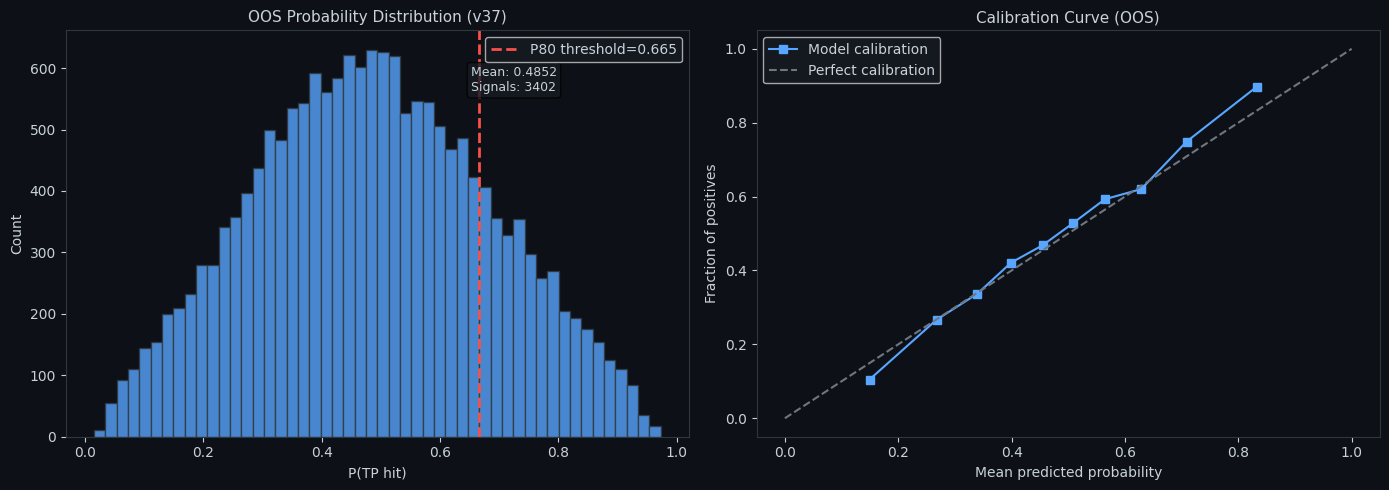

✅ Diagnostic chart saved → /content/v37_diagnostics.png



In [43]:
# ── F7: Execution order guard ────────────────────────────────────────────────
assert 'model'    in globals() and getattr(model, 'is_trained', False), 'Run Cell 11 first (train model)'
assert 'df_train' in globals() and not df_train.empty,                   'Run Cell 11 first (build train set)'
assert 'df_oos'   in globals() and not df_oos.empty,                     'Run Cell 11 first (build OOS set)'
# ─────────────────────────────────────────────────────────────────────────────

# ── v35: Post-Training Diagnostics — Target Balance + Probability Calibration ──────
import matplotlib.pyplot as plt
import numpy as np

print('='*65)
print('\U0001f52c v39 POST-TRAINING DIAGNOSTICS')
print('='*65)

# ── 1. Target Balance Check ─────────────────────────────────────────────────
pos_rate = df_train['target'].mean()
n_pos = df_train['target'].sum()
n_neg = (df_train['target'] == 0).sum()
print(f'\n📊 TRAINING TARGET BALANCE:')
print(f'   Positive (TP hit) : {n_pos:,} ({pos_rate*100:.1f}%)')
print(f'   Negative          : {n_neg:,} ({(1-pos_rate)*100:.1f}%)')
if pos_rate < 0.20:
    print(f'   ❌ CRITICAL: {pos_rate:.1%} positive rate < 20% — model will learn no-trade bias')
    print(f'   → TP={TAKE_PROFIT_PCT*100:.1f}% / SL={STOP_LOSS_PCT*100:.1f}% / Horizon={TP_SL_TARGET_HORIZON} bars ({TP_SL_TARGET_HORIZON*5//60}h)')
    print(f'   → Consider further reducing TP or extending horizon')
elif pos_rate > 0.45:
    print(f'   ⚠️  {pos_rate:.1%} positive rate > 45% — TP may be too easy, will overfit longs')
else:
    print(f'   ✅ Healthy positive rate {pos_rate:.1%} in 20-45% range')

# ── 2. Ensemble Probability Distribution ────────────────────────────────────
_X_tr_diag = df_train[FEATURE_COLS].values.astype('float32')
_train_probs = model.predict_proba(_X_tr_diag, X_df=df_train[FEATURE_COLS])
_X_oos_diag  = df_oos[FEATURE_COLS].values.astype('float32')
_oos_probs   = model.predict_proba(_X_oos_diag, X_df=df_oos[FEATURE_COLS])

print(f'\n📊 ENSEMBLE PROBABILITY DISTRIBUTION:')
print(f'               Train          OOS')
print(f'   Mean    :  {_train_probs.mean():.4f}         {_oos_probs.mean():.4f}')
print(f'   P50     :  {np.percentile(_train_probs,50):.4f}         {np.percentile(_oos_probs,50):.4f}')
print(f'   P75     :  {np.percentile(_train_probs,75):.4f}         {np.percentile(_oos_probs,75):.4f}')
print(f'   P80     :  {np.percentile(_train_probs,80):.4f}         {np.percentile(_oos_probs,80):.4f}')
print(f'   P90     :  {np.percentile(_train_probs,90):.4f}         {np.percentile(_oos_probs,90):.4f}')
print(f'   P95     :  {np.percentile(_train_probs,95):.4f}         {np.percentile(_oos_probs,95):.4f}')
print(f'   Max     :  {_train_probs.max():.4f}         {_oos_probs.max():.4f}')

_thr = model.dynamic_threshold
_signals_oos = (_oos_probs > _thr).sum()
print(f'\n   Dynamic threshold (P80 OOF): {_thr:.4f}')
print(f'   OOS signals above threshold: {_signals_oos} ({_signals_oos/len(_oos_probs)*100:.1f}%)')
print(f'   Regime thresholds: {getattr(model, "regime_thresholds", {})}')

if _oos_probs.mean() < 0.05:
    print(f'\n\u274c CRITICAL: OOS mean prob {_oos_probs.mean():.4f} < 0.05')
    print(f'   Ensemble over-compressing. Action: set USE_RAW_BLEND=True in Cell 4 and rerun.')
elif _oos_probs.mean() < 0.15:
    print(f'\n\u26a0\ufe0f  OOS mean prob {_oos_probs.mean():.4f} is low (0.05-0.15) \u2014 signals will be sparse')
else:
    print(f'\n\u2705 OOS mean prob {_oos_probs.mean():.4f} \u2014 ensemble producing real signal range')

# ── v35: Model is LGBM-only — no calibration chain to compare ───────────
print('\n' + '='*65)
print('\U0001f9ea P0 v34: RAW BLEND vs CALIBRATED COMPARISON')
print('='*65)
# Compute raw blend proba (bypassing meta/calibrator regardless of flag)
_X_oos_raw = df_oos[FEATURE_COLS].values.astype('float32')
_X_oos_scaled = model.scaler.transform(_X_oos_raw)
# v36 fix: LGBM-only model — compute raw probs directly (no stack/blend needed)
_raw_probs = model.lgbm.predict_proba(_X_oos_scaled)[:, 1]
# v36 fix: LGBMModel has no .meta/.calibrator — chain is never available
_has_chain = (hasattr(model, 'meta') and hasattr(model, 'calibrator')
              and model.meta is not None and model.calibrator is not None)
_chain_probs = _oos_probs if _has_chain and not USE_RAW_BLEND else _raw_probs

print(f'   Mode active      : {"RAW BLEND (P0 flag=True)" if USE_RAW_BLEND else "CALIBRATED CHAIN"}')
print(f'   Chain available  : {_has_chain}')
print(f'')
print(f'   {"Metric":<20} {"Raw blend":>12} {"Calibrated":>12}')
print(f'   {"-"*44}')
_cal_p = _chain_probs if _has_chain and not USE_RAW_BLEND else np.full_like(_raw_probs, float("nan"))
for _pct_label, _pct_val in [("Mean", None), ("P50", 50), ("P80", 80), ("P90", 90), ("P95", 95), ("Max", None)]:
    if _pct_val is None:
        _rv = _raw_probs.mean() if _pct_label == 'Mean' else _raw_probs.max()
        _cv = _cal_p.mean() if _pct_label == 'Mean' else _cal_p.max()
    else:
        _rv = np.percentile(_raw_probs, _pct_val)
        _cv = np.percentile(_cal_p, _pct_val)
    _cv_str = f'{_cv:.4f}' if not np.isnan(_cv) else '  n/a'
    print(f'   {_pct_label:<20} {_rv:>12.4f} {_cv_str:>12}')

_raw_sigs = (_raw_probs > SIGNAL_THRESHOLD).sum()
_cal_sigs = (_chain_probs > SIGNAL_THRESHOLD).sum() if _has_chain else 0
print(f'\n   Signals > threshold ({SIGNAL_THRESHOLD:.3f})')
print(f'   Raw blend: {_raw_sigs} ({_raw_sigs/len(_raw_probs)*100:.1f}%)')
if _has_chain:
    print(f'   Calibrated: {_cal_sigs} ({_cal_sigs/len(_chain_probs)*100:.1f}%)')

if _has_chain and _raw_probs.mean() > 2 * _chain_probs.mean() and _chain_probs.mean() < 0.08:
    print(f'\n\u2757 DIAGNOSIS: Raw mean ({_raw_probs.mean():.4f}) >> Calibrated mean ({_chain_probs.mean():.4f})')
    print(f'   The calibration CHAIN is compressing probabilities.')
    print(f'   RECOMMENDATION: Keep USE_RAW_BLEND=True (P0 fix is effective).')
elif _raw_probs.mean() < 0.08:
    print(f'\n\u2757 DIAGNOSIS: Raw blend mean ({_raw_probs.mean():.4f}) is also low.')
    print(f'   Chain is NOT the root cause. Proceed to P1 (fee-adjusted target) and P3 (target redesign).')
else:
    print(f'\n\u2705 Both raw and calibrated probabilities are in healthy range.')
    print(f'   Calibration chain is not compressing. USE_RAW_BLEND has minimal impact.')


# ── 3. Calibration Curve ────────────────────────────────────────────────────
from sklearn.calibration import calibration_curve
fig_cal, axes_cal = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
for ax in axes_cal: ax.set_facecolor('#0d1117'); ax.tick_params(colors='#c9d1d9'); ax.spines[:].set_color('#30363d')

# Plot OOS prob histogram
axes_cal[0].hist(_oos_probs, bins=50, color='#58a6ff', edgecolor='#30363d', alpha=0.8)
axes_cal[0].axvline(_thr, color='#f85149', lw=2, ls='--', label=f'P80 threshold={_thr:.3f}')
axes_cal[0].set_title('OOS Probability Distribution (v37)', color='#c9d1d9', fontsize=11)
axes_cal[0].set_xlabel('P(TP hit)', color='#c9d1d9')
axes_cal[0].set_ylabel('Count', color='#c9d1d9')
axes_cal[0].legend(facecolor='#161b22', labelcolor='#c9d1d9')
axes_cal[0].text(0.65, 0.85, f'Mean: {_oos_probs.mean():.4f}\nSignals: {_signals_oos}',
                 transform=axes_cal[0].transAxes, color='#c9d1d9', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='#161b22', alpha=0.8))

# Calibration curve (if OOS has target labels)
if 'target' in df_oos.columns and len(np.unique(df_oos['target'])) > 1:
    try:
        frac_pos, mean_pred = calibration_curve(df_oos['target'], _oos_probs, n_bins=10, strategy='quantile')
        axes_cal[1].plot(mean_pred, frac_pos, 's-', color='#58a6ff', label='Model calibration')
        axes_cal[1].plot([0,1],[0,1], 'k--', color='#6e7681', label='Perfect calibration')
        axes_cal[1].set_title('Calibration Curve (OOS)', color='#c9d1d9', fontsize=11)
        axes_cal[1].set_xlabel('Mean predicted probability', color='#c9d1d9')
        axes_cal[1].set_ylabel('Fraction of positives', color='#c9d1d9')
        axes_cal[1].legend(facecolor='#161b22', labelcolor='#c9d1d9')
        print(f'\n✅ Calibration curve plotted')
    except Exception as e:
        axes_cal[1].text(0.5, 0.5, f'Calibration curve unavailable\n{e}',
                         ha='center', va='center', color='#c9d1d9', transform=axes_cal[1].transAxes)
else:
    axes_cal[1].text(0.5, 0.5, 'No target labels in OOS\n(add for_training=True)',
                     ha='center', va='center', color='#c9d1d9', transform=axes_cal[1].transAxes)

plt.tight_layout()
plt.savefig('/content/v37_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
plt.close('all')
print('✅ Diagnostic chart saved → /content/v37_diagnostics.png')
print('\n' + '='*65)

In [44]:
from dataclasses import dataclass, field
from typing import List


@dataclass
class Trade:
    entry_time:  pd.Timestamp
    exit_time:   pd.Timestamp
    side:        str          # 'long' or 'short'
    entry_price: float
    exit_price:  float
    size:        float        # USD notional
    pnl_pct:     float        # net PnL % after fees
    pnl_usd:     float
    exit_reason: str          # 'signal', 'sl', 'tp'


class Backtester:
    """
    Bar-by-bar backtester for the EnsembleModel.
    Signals are generated from features at bar t, executed at bar t+1 open.
    SL/TP are checked within bar t+1's high/low.
    """

    def __init__(
        self,
        maker_fee:    float = MAKER_FEE,
        taker_fee:    float = TAKER_FEE,
        slippage_pct: float = SLIPPAGE_PCT,
        sl_pct:       float = STOP_LOSS_PCT,
        tp_pct:       float = TAKE_PROFIT_PCT,
        leverage:     int   = LEVERAGE,
        max_pos_pct:  float = MAX_POSITION_PCT,
        capital:      float = CAPITAL_USDT,
    ):
        self.maker_fee    = maker_fee
        self.taker_fee    = taker_fee
        self.slippage_pct = slippage_pct
        self.sl_pct       = sl_pct
        self.tp_pct       = tp_pct
        self.leverage     = leverage
        self.max_pos_pct  = max_pos_pct
        self.init_capital = capital
        self.equity_curve = np.array([capital], dtype=float)
        self.trades       = []

    def _apply_slippage(self, price: float, side: str, entry: bool) -> float:
        direction = 1 if (side == 'long') == entry else -1
        return price * (1 + direction * self.slippage_pct)

    def _position_size(self, capital: float, price: float) -> float:
        """
        Notional USD size using fractional Kelly or max_pos_pct cap.
        BUG 9 FIX: The old min() was ineffective — both terms simplified to the same
        value (0.20 × 5 = 1.0 × capital and 1.0 × capital), making the cap redundant.
        Fix: cap the fraction BEFORE applying leverage.
        """
        capped_fraction = min(self.max_pos_pct, 1.0)   # cap at 20% of capital
        return capital * capped_fraction * self.leverage

    def run(
        self,
        df: pd.DataFrame,
        model: EnsembleModel,
        threshold: float = SIGNAL_THRESHOLD,
        feature_cols: list = None,   # BUG FIX 3: use model.feature_cols, not global
    ) -> dict:
        """
        Run backtest on df (must have OHLCV + feature cols + timestamp).
        Returns performance metrics dict and trade log.
        """
        # BUG FIX 3: always use the model's own feature list, never the global
        feature_cols = feature_cols or getattr(model, 'feature_cols', None) or FEATURE_COLS
        df = df.reset_index(drop=True)

        # FIX 4: Batch-precompute ALL signals before the bar loop ──────────────
        # Old: model.predict_signal() called per bar -> O(n) RF Parallel calls
        # New: single predict_signal_batch() call -> loop indexes arrays
        try:
            _pre_sigs, _pre_probas = model.predict_signal_batch(
                df[feature_cols], threshold=threshold
            )
        except Exception as _be:
            print(f'  ⚠️  FIX 4 batch-predict fallback ({_be}) -- using per-bar mode')
            _pre_sigs   = None
            _pre_probas = None

        capital   = self.init_capital
        trades: List[Trade] = []
        equity_curve = [capital]
        self.equity_curve = np.array(equity_curve, dtype=float)
        self.trades       = trades

        position   = None   # None | {'side', 'entry_price', 'size', 'sl', 'tp', 'entry_time', 'entry_idx'}
        total_fees = 0.0
        # ── F5: Signal→trade collapse diagnostic counters ─────────────────
        _diag_signals_raw      = 0   # raw signals from model (before filters)
        _diag_rejected_pos     = 0   # rejected: position already open
        _diag_rejected_short   = 0   # rejected: short disabled
        _diag_trades_executed  = 0   # trades actually entered
        # ────────────────────────────────────────────────────────────────────

        for i in range(len(df) - 1):
            row_now  = df.iloc[i]
            row_next = df.iloc[i + 1]

            # ── Check open position SL/TP first (within next bar) ─────────
            if position is not None:
                ep    = position['entry_price']
                side  = position['side']
                hi    = row_next['high']
                lo    = row_next['low']
                sl    = position['sl']
                tp    = position['tp']
                exit_price  = None
                exit_reason = None

                if side == 'long':
                    # ISSUE 6 FIX: gap-through pessimism — if bar opens beyond SL,
                    # use open price (worse fill) instead of SL level
                    if row_next['open'] <= sl:
                        exit_price, exit_reason = row_next['open'], 'sl_gap'
                    elif lo <= sl:
                        exit_price, exit_reason = sl, 'sl'
                    elif hi >= tp:
                        exit_price, exit_reason = tp, 'tp'
                else:  # short
                    if row_next['open'] >= sl:
                        exit_price, exit_reason = row_next['open'], 'sl_gap'
                    elif hi >= sl:
                        exit_price, exit_reason = sl, 'sl'
                    elif lo <= tp:
                        exit_price, exit_reason = tp, 'tp'

                if exit_price is None:
                    # Use pre-computed signal for reversal exit check (FIX 4)
                    if _pre_sigs is not None:
                        sig = _pre_sigs[i:i+1]
                    else:
                        X_now = df.iloc[i][feature_cols].values.reshape(1, -1)
                        try:
                            x_df = df.iloc[[i]][feature_cols]
                            sig, _ = model.predict_signal(X_now, threshold, X_df=x_df)
                        except Exception:
                            sig = np.array([0])
                    if (side == 'long' and sig[0] == -1) or (side == 'short' and sig[0] == 1):
                        exit_price  = row_next['open']
                        exit_reason = 'signal'

                if exit_price is not None:
                    exit_px_adj = self._apply_slippage(exit_price, side, entry=False)
                    fee = position['size'] * self.taker_fee
                    total_fees += fee
                    if side == 'long':
                        pnl_pct = (exit_px_adj - ep) / ep
                    else:
                        pnl_pct = (ep - exit_px_adj) / ep
                    pnl_usd = position['size'] * pnl_pct - fee
                    capital += pnl_usd
                    trades.append(Trade(
                        entry_time  = position['entry_time'],
                        exit_time   = row_next['timestamp'],
                        side        = side,
                        entry_price = ep,
                        exit_price  = exit_px_adj,
                        size        = position['size'],
                        pnl_pct     = pnl_pct,
                        pnl_usd     = pnl_usd,
                        exit_reason = exit_reason,
                    ))
                    position = None
                    equity_curve.append(capital)
                    continue

            # ── Generate signal if flat ───────────────────────────────────
            if position is None:
                # Use pre-computed batch signals (FIX 4)
                if _pre_sigs is not None:
                    sig   = _pre_sigs[i:i+1]
                    proba = _pre_probas[i:i+1]
                else:
                    X_now = df.iloc[i][feature_cols].values.reshape(1, -1)
                    try:
                        x_df = df.iloc[[i]][feature_cols]
                        sig, proba = model.predict_signal(X_now, threshold, X_df=x_df)
                    except Exception:
                        equity_curve.append(capital)
                        continue

                if sig[0] != 0:
                    _diag_signals_raw += 1  # F5: count raw signals
                    # P2b: honour ENABLE_SHORT_EXECUTION; fall back to long-only if not
                    if sig[0] == -1 and not ENABLE_SHORT_EXECUTION:
                        _diag_rejected_short += 1  # F5
                        equity_curve.append(capital)
                        continue
                    side       = 'long' if sig[0] == 1 else 'short'
                    entry_price= self._apply_slippage(row_next['open'], side, entry=True)
                    size       = self._position_size(capital, entry_price)
                    fee        = size * self.taker_fee
                    total_fees += fee
                    capital    -= fee  # Entry fee

                    # Fix 1: Use ATR-adaptive execution levels to match training labels
                    _bar_for_levels = df.iloc[i+1] if 'label_atr' in df.columns else None
                    if side == 'long':
                        sl, tp = _resolve_execution_levels(entry_price, df_bar=_bar_for_levels)
                    else:
                        sl_long, tp_long = _resolve_execution_levels(entry_price, df_bar=_bar_for_levels)
                        sl = tp_long   # short SL is where long TP was
                        tp = sl_long   # short TP is where long SL was

                    _diag_trades_executed += 1  # F5
                    position = {
                        'side':        side,
                        'entry_price': entry_price,
                        'entry_time':  row_next['timestamp'],
                        'size':        size,
                        'sl':          sl,
                        'tp':          tp,
                    }

            # F5: count bars where position was already open (can't enter new)
            elif position is not None and _pre_sigs is not None and _pre_sigs[i] != 0:
                _diag_rejected_pos += 1
            equity_curve.append(capital)

        # ── F5: Signal→trade collapse report ─────────────────────────────
        _total_bars = len(df) - 1
        if _diag_signals_raw > 0:
            _collapse_pct = (1 - _diag_trades_executed / _diag_signals_raw) * 100
            print(f'  \U0001f4ca Signal→trade diagnostic:')
            print(f'     Bars processed    : {_total_bars:,}')
            print(f'     Signals generated : {_diag_signals_raw:,}')
            print(f'     Rejected (pos open): {_diag_rejected_pos:,}')
            print(f'     Rejected (short off): {_diag_rejected_short:,}')
            print(f'     Trades executed   : {_diag_trades_executed:,}')
            print(f'     Collapse rate     : {_collapse_pct:.1f}%')
            if _collapse_pct > 80:
                print(f'     \u26a0\ufe0f  HIGH COLLAPSE — check position holding time vs signal frequency')
        # ── Compute metrics ───────────────────────────────────────────────
        return self._compute_metrics(trades, equity_curve, total_fees, timestamps=df['timestamp'])

    def _compute_metrics(self, trades: list, equity: list, total_fees: float,
                         timestamps: 'pd.Series' = None) -> dict:
        eq   = np.array(equity)
        rets = np.diff(eq) / (eq[:-1] + 1e-9)

        # Drawdown
        peak = np.maximum.accumulate(eq)
        dd   = (eq - peak) / (peak + 1e-9)
        max_dd = dd.min()

        # Trade stats
        n_trades  = len(trades)
        if n_trades == 0:
            print('⚠️  No trades executed')
            self.equity_curve = eq
            self.trades       = trades
            return {
                'error': 'no trades',
                'final_capital': round(eq[-1], 2),
                'n_trades': 0,
                'total_fees_usd': round(total_fees, 2),
            }

        pnls      = [t.pnl_usd for t in trades]
        wins      = [p for p in pnls if p > 0]
        losses    = [p for p in pnls if p <= 0]
        win_rate  = len(wins) / n_trades
        avg_win   = np.mean(wins) if wins else 0
        avg_loss  = abs(np.mean(losses)) if losses else 0
        profit_factor = (sum(wins) / abs(sum(losses))) if losses else float('inf')

        # ── v37 FIX: Sharpe ratio — resample equity to hourly before computing ──────────
        # OLD: rets = np.diff(equity)/equity[:-1] mixes trade-level and bar-level returns,
        #      then annualises by 5m bar count → incorrect frequency assumption.
        # NEW: Resample equity curve to 1-hour intervals → per-hour returns →
        #      annualise by sqrt(8760 hours/year). This is the correct approach.
        sharpe = 0.0
        sharpe_note = 'n/a'
        try:
            # Fix 5: use explicitly passed timestamps (not df from outer scope)
            _ts_arr   = timestamps.values[:len(eq)] if timestamps is not None and len(timestamps) >= len(eq) else None
            if _ts_arr is None:
                raise ValueError('timestamps not provided or too short')
            _eq_series = pd.Series(eq, index=pd.to_datetime(_ts_arr))
            # Resample to hourly, forward-fill to fill in-position bars
            _eq_hourly = _eq_series.resample('1h').last().ffill()
            _hr_rets   = _eq_hourly.pct_change().dropna()
            if len(_hr_rets) > 2:
                _hours_per_year = 8760
                sharpe = float(_hr_rets.mean() / (_hr_rets.std() + 1e-9) * np.sqrt(_hours_per_year))
        except Exception as _se:
            print(f'  ⚠️  Sharpe resampling error (fallback 0): {_se}')
        if n_trades < 30:
            sharpe_note = f'{round(sharpe, 3)} [UNRELIABLE: only {n_trades} trades, need ≥30]'
        else:
            sharpe_note = round(sharpe, 3)

        total_return = (eq[-1] - eq[0]) / (eq[0] + 1e-9)
        # v37 FIX: track sl_gap explicitly (was silently excluded from breakdown)
        by_exit = {r: sum(1 for t in trades if t.exit_reason == r)
                   for r in ['signal', 'sl', 'sl_gap', 'tp']}

        # ── v38 R4: Sortino ratio ─────────────────────────────────────────────
        sortino = 0.0
        try:
            _ts_arr2 = timestamps.values[:len(eq)] if timestamps is not None and len(timestamps) >= len(eq) else None
            if _ts_arr2 is None:
                raise Exception('timestamps not available for Sortino')
            _eq_hourly2 = pd.Series(eq, index=pd.to_datetime(_ts_arr2)).resample('1h').last().ffill()
            _hr_rets2 = _eq_hourly2.pct_change().dropna()
            _downside = _hr_rets2[_hr_rets2 < 0]
            if len(_downside) > 2:
                _dd_std = float(_downside.std())
                sortino = float(_hr_rets2.mean() / (_dd_std + 1e-9) * np.sqrt(8760))
        except Exception:
            pass
        sortino_note = round(sortino, 3) if n_trades >= 30 else f'{round(sortino,3)} [UNRELIABLE:<30 trades]'

        # ── v38 R4: Trade expectancy (EV per trade in USD) ────────────────────
        _net_gain_rate = TAKE_PROFIT_PCT - ROUND_TRIP_COST_PCT   # approx net% per win
        _net_loss_rate = STOP_LOSS_PCT   + ROUND_TRIP_COST_PCT   # approx net% per loss
        expectancy_usd = win_rate * avg_win - (1 - win_rate) * avg_loss
        ev_per_trade_pct = win_rate * _net_gain_rate - (1 - win_rate) * _net_loss_rate

        metrics = {
            'total_return_pct': round(total_return * 100, 2),
            'final_capital':    round(eq[-1], 2),
            'max_drawdown_pct': round(max_dd * 100, 2),
            'sharpe_ratio':     sharpe_note if n_trades < 30 else round(sharpe, 3),
            'sortino_ratio':    sortino_note,                          # v38 R4
            'expectancy_usd':   round(expectancy_usd, 2),             # v38 R4
            'ev_per_trade_pct': round(ev_per_trade_pct * 100, 4),     # v38 R4
            'n_trades':         n_trades,
            'win_rate_pct':     round(win_rate * 100, 2),
            'profit_factor':    round(profit_factor, 3),
            'avg_win_usd':      round(avg_win, 2),
            'avg_loss_usd':     round(avg_loss, 2),
            'total_fees_usd':   round(total_fees, 2),
            'exits':            by_exit,
        }
        self.equity_curve = eq
        self.trades       = trades
        return metrics


print(f'✅ Backtester v39 defined — execution_mode={"ATR-adaptive" if USE_ATR_TARGET else "fixed-pct"} '
      f'SL={STOP_LOSS_PCT*100:.1f}% TP={TAKE_PROFIT_PCT*100:.1f}%')
print('   Fix 5: _compute_metrics receives explicit timestamps (no outer-scope closure)')
print('   Fix 1: SL/TP resolved via _resolve_execution_levels() (ATR or fixed-pct)')


✅ Backtester v39 defined — execution_mode=ATR-adaptive SL=1.0% TP=2.5%
   Fix 5: _compute_metrics receives explicit timestamps (no outer-scope closure)
   Fix 1: SL/TP resolved via _resolve_execution_levels() (ATR or fixed-pct)


⌑ Running OOS backtest ...
   Period: 2026-03-02 → 2026-04-30
   Bars:   17070

v35 OOS Prediction Distribution:
  Min:    0.0150
  P50:    0.4813
  P75:    0.6289
  P90:    0.7565
  P95:    0.8242
  Max:    0.9732
  Mean:   0.4852
  Threshold (dynamic): 0.6653
  Signals > threshold: 3402

✅ v35: Ensemble mean proba=0.4852 — healthy signal range


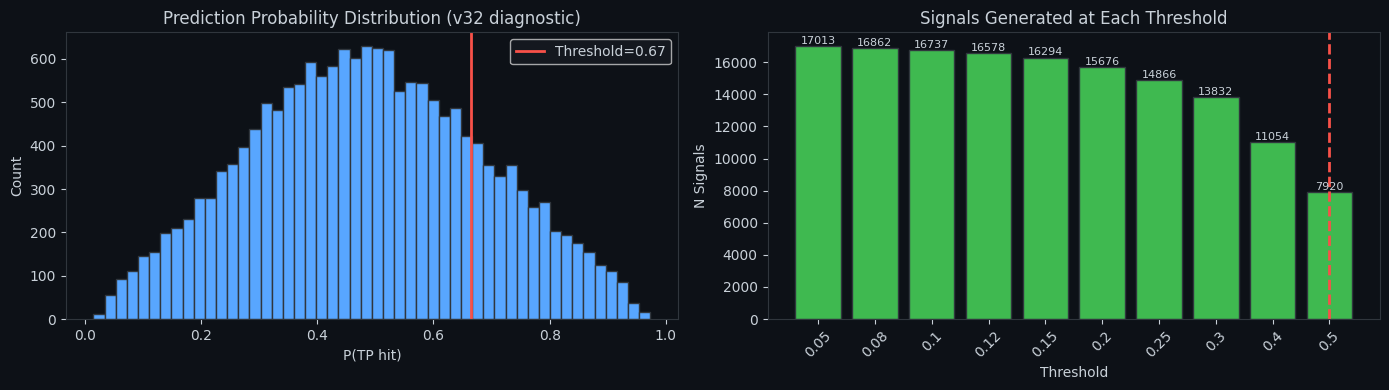


OOS regime distribution:
regime_label
ranging    8306
neutral    7793
crisis      971
Name: count, dtype: int64

v32 Regime-conditioned thresholds:
  ranging     : threshold=0.6004 | signals=2430
  neutral     : threshold=0.6502 | signals=1760
  crisis      : threshold=0.9181 | signals=2
  📊 Signal→trade diagnostic:
     Bars processed    : 17,069
     Signals generated : 1,749
     Rejected (pos open): 952
     Rejected (short off): 0
     Trades executed   : 1,749
     Collapse rate     : 0.0%

ဨး OOS BACKTEST RESULTS
  total_return_pct         : -39.31
  final_capital            : 606.9
  max_drawdown_pct         : -44.11
  sharpe_ratio             : -15.184
  sortino_ratio            : -18.312
  expectancy_usd           : 0.22
  ev_per_trade_pct         : 0.6734
  n_trades                 : 1749
  win_rate_pct             : 70.67
  profit_factor            : 1.386
  avg_win_usd              : 1.11
  avg_loss_usd             : 1.93
  total_fees_usd           : 1550.7
  exits       

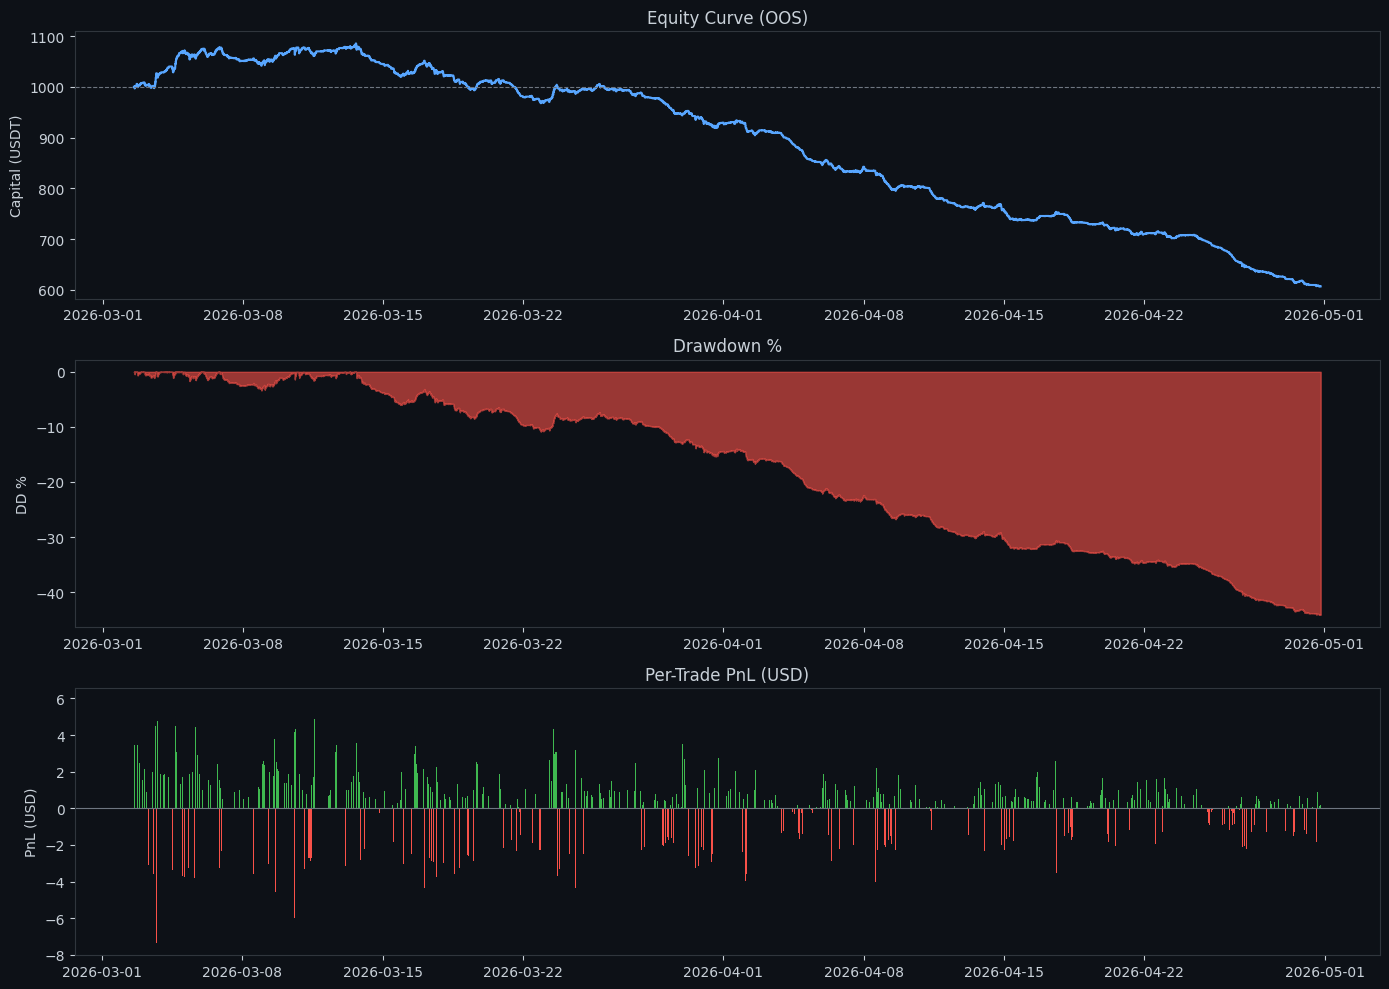

Prob dist: [0.48131971 0.62886199 0.7565213  0.82415953 0.90934344]
Expected trades (regime-based thresholds): 4192
  Thresholds used: {'ranging': 0.600361168384552, 'neutral': 0.650172233581543, 'crisis': 0.918145477771759}


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# ── F7: Execution order guards ──────────────────────────────────────────────
assert 'model'      in globals() and getattr(model, 'is_trained', False), 'Run Cell 11 first (train model)'
assert 'df_oos'     in globals() and not df_oos.empty,                    'Run Cell 11 first (build OOS set)'
assert 'FEATURE_COLS' in globals(),                                        'Run Cell 9 first (feature engineering)'
# ─────────────────────────────────────────────────────────────────────────────

print('⌑ Running OOS backtest ...')
print(f'   Period: {df_oos.timestamp.iloc[0].date()} → {df_oos.timestamp.iloc[-1].date()}')
print(f'   Bars:   {len(df_oos)}')

bt = Backtester()
feature_cols = getattr(model, 'feature_cols', None) or FEATURE_COLS
X_oos = df_oos[feature_cols].values.astype('float32')
X_oos_df = df_oos[feature_cols]
pred_probs = model.predict_proba(X_oos, X_df=X_oos_df)

# ── F8: Index alignment check — catches silent misalignment from dropna/merge ──
assert len(pred_probs) == len(df_oos), (
    f'ALIGNMENT ERROR: pred_probs has {len(pred_probs)} rows but df_oos has {len(df_oos)} rows. '
    f'Rerun Cell 11 to rebuild df_oos from the same feature pipeline.'
)
# ─────────────────────────────────────────────────────────────────────────────

print('\nv35 OOS Prediction Distribution:')
print(f'  Min:    {np.min(pred_probs):.4f}')
print(f'  P50:    {np.percentile(pred_probs, 50):.4f}')
print(f'  P75:    {np.percentile(pred_probs, 75):.4f}')
print(f'  P90:    {np.percentile(pred_probs, 90):.4f}')
print(f'  P95:    {np.percentile(pred_probs, 95):.4f}')
print(f'  Max:    {np.max(pred_probs):.4f}')
print(f'  Mean:   {np.mean(pred_probs):.4f}')
print(f'  Threshold (dynamic): {SIGNAL_THRESHOLD:.4f}')
print(f'  Signals > threshold: {(pred_probs > SIGNAL_THRESHOLD).sum()}')

# Sanity check: dynamic threshold should be within model's output range
# Fix 12: Use local variable for backtest threshold override — do NOT mutate global
_bt_threshold = SIGNAL_THRESHOLD # Default value

if SIGNAL_THRESHOLD > np.max(pred_probs):
    _bt_threshold = float(np.percentile(pred_probs, 90))
    print(
        f'  ⚠️  OOS threshold override: global SIGNAL_THRESHOLD={SIGNAL_THRESHOLD:.4f} '
        f'exceeds OOS max={np.max(pred_probs):.4f}. '
        f'Using {_bt_threshold:.4f} for THIS BACKTEST ONLY. '
        f'Global SIGNAL_THRESHOLD is NOT changed. '
        f'If this persists, retrain or lower THRESHOLD_OOF_PERCENTILE.'
    )
elif SIGNAL_THRESHOLD > np.percentile(pred_probs, 95):
    print(f'  ☕  Threshold {SIGNAL_THRESHOLD:.4f} > P95 — very few signals expected (<5% of bars)')

if not LONG_ONLY_EXECUTION:
    print(f'  Signals < short threshold ({SIGNAL_THRESHOLD_SHORT:.2f}): {(pred_probs < SIGNAL_THRESHOLD_SHORT).sum()}')

# v35 signal check: Auto-fallback diagnostic — if ensemble proba too compressed, flag it
_ensemble_mean = np.mean(pred_probs)
if _ensemble_mean < 0.05:
    print(f'\n⚠️  v35 signal check WARNING: Ensemble mean proba={_ensemble_mean:.4f} < 0.05')
    print(f'   Ensemble is over-compressing signals. Consider:')
    print(f'   1. Check target balance (run build_feature_matrix with ENABLE_TARGET_REPORT=True)')
    print(f'   2. Run baseline LGBM cell below — if baseline > 0.10 mean, meta-learner is the issue')
    print(f'   3. If target balance < 20%, fix TP/SL config first')
    _baseline_override = True
else:
    _baseline_override = False
    print(f'\n✅ v35: Ensemble mean proba={_ensemble_mean:.4f} — healthy signal range')

fig_diag, ax_diag = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0d1117')
for ax in ax_diag:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#c9d1d9')
    ax.spines[:].set_color('#30363d')

ax_diag[0].hist(pred_probs, bins=50, color='#58a6ff', edgecolor='#30363d')
ax_diag[0].axvline(SIGNAL_THRESHOLD, color='#f85149', lw=2, label=f'Threshold={SIGNAL_THRESHOLD:.2f}')
ax_diag[0].set_title('Prediction Probability Distribution (v32 diagnostic)', color='#c9d1d9')
ax_diag[0].set_xlabel('P(TP hit)', color='#c9d1d9')
ax_diag[0].set_ylabel('Count', color='#c9d1d9')
ax_diag[0].legend(facecolor='#161b22', labelcolor='#c9d1d9')

thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
signal_counts = [(t, (pred_probs > t).sum()) for t in thresholds]
thresh_vals, sig_counts = zip(*signal_counts)
ax_diag[1].bar([str(t) for t in thresh_vals], sig_counts, color='#3fb950', edgecolor='#30363d')

# FIX: Safely find the approximate position for the axvline when using categorical bar labels
try:
    # Find index of closest threshold in the list
    closest_idx = np.argmin([abs(t - SIGNAL_THRESHOLD) for t in thresholds])
    ax_diag[1].axvline(closest_idx, color='#f85149', lw=2, ls='--', label=f'Current ≈ {SIGNAL_THRESHOLD:.2f}')
except Exception:
    pass

ax_diag[1].set_title('Signals Generated at Each Threshold', color='#c9d1d9')
ax_diag[1].set_xlabel('Threshold', color='#c9d1d9')
ax_diag[1].set_ylabel('N Signals', color='#c9d1d9')
ax_diag[1].tick_params(axis='x', rotation=45)
for bar, (t, cnt) in zip(ax_diag[1].patches, signal_counts):
    ax_diag[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                    f'{cnt}', ha='center', va='bottom', color='#c9d1d9', fontsize=8)
plt.tight_layout()
plt.savefig('/content/probability_histogram.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
plt.close('all')  # v37: prevent figure accumulation in long runs

if 'regime_label' in df_oos.columns:
    print('\nOOS regime distribution:')
    print(df_oos['regime_label'].value_counts(dropna=False))
if hasattr(model, 'regime_thresholds') and model.regime_thresholds:
    print('\nv32 Regime-conditioned thresholds:')
    for reg, thr in model.regime_thresholds.items():
        n_sig = (pred_probs > thr).sum() if 'regime_label' not in df_oos.columns else \
                (pred_probs[df_oos['regime_label'].values == reg] > thr).sum()
        print(f'  {reg:<12}: threshold={thr:.4f} | signals={n_sig}')

# v33 SIG-7: pass threshold=None → predict_signal_batch uses per-regime thresholds
# This fixes the bug where regime thresholds were computed but never used in backtest
# v38 R3: use unified get_signal_threshold for per-regime aware threshold
_thr_for_bt = get_signal_threshold('neutral', model)
results = bt.run(df_oos, model, threshold=_bt_threshold if _bt_threshold != SIGNAL_THRESHOLD else None)  # Fix 12 + per-regime

print('\n' + '='*50)
print('ဨး OOS BACKTEST RESULTS')
print('='*50)
for k, v in results.items():
    print(f'  {k:<25}: {v}')
print('='*50)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#c9d1d9')
    ax.spines[:].set_color('#30363d')

timestamps = df_oos['timestamp'].values[:len(bt.equity_curve)]
axes[0].plot(timestamps, bt.equity_curve, color='#58a6ff', lw=1.5)
axes[0].axhline(CAPITAL_USDT, color='#6e7681', lw=0.8, ls='--')
axes[0].set_title('Equity Curve (OOS)', color='#c9d1d9', fontsize=12)
axes[0].set_ylabel('Capital (USDT)', color='#c9d1d9')

eq  = bt.equity_curve
pk  = np.maximum.accumulate(eq)
dd  = (eq - pk) / (pk + 1e-9) * 100
axes[1].fill_between(timestamps, dd, 0, color='#f85149', alpha=0.6)
axes[1].set_title('Drawdown %', color='#c9d1d9', fontsize=12)
axes[1].set_ylabel('DD %', color='#c9d1d9')

trade_times = [t.exit_time for t in bt.trades]
trade_pnls  = [t.pnl_usd for t in bt.trades]
if trade_pnls:
    colors = ['#3fb950' if p > 0 else '#f85149' for p in trade_pnls]
    axes[2].bar(trade_times, trade_pnls, color=colors, width=pd.Timedelta(minutes=20))
    axes[2].axhline(0, color='#6e7681', lw=0.8)
axes[2].set_title('Per-Trade PnL (USD)', color='#c9d1d9', fontsize=12)
axes[2].set_ylabel('PnL (USD)', color='#c9d1d9')

plt.tight_layout()
plt.savefig('/content/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')  # v37: prevent figure accumulation in long runs
print('Prob dist:', np.percentile(pred_probs, [50,75,90,95,99]))

# ── v37 FIX: regime threshold helper reads from model directly ───────────────
# OLD: referenced a bare `regime_thresholds` global that was never defined,
#      then fell back to hardcoded values that may not match the trained model.
# NEW: reads model.regime_thresholds, falls back to model.dynamic_threshold
def _regime_threshold(r):
    if hasattr(model, 'regime_thresholds') and model.regime_thresholds:
        return model.regime_thresholds.get(r, model.dynamic_threshold)
    return model.dynamic_threshold

signals = 0
if 'df_oos' in globals() and 'regime_label' in df_oos.columns:
    for i in range(len(pred_probs)):
        r  = df_oos['regime_label'].iloc[i]
        th = _regime_threshold(r)
        if pred_probs[i] > th:
            signals += 1
    print(f"Expected trades (regime-based thresholds): {signals}")
    if hasattr(model, 'regime_thresholds') and model.regime_thresholds:
        print(f"  Thresholds used: {model.regime_thresholds}")
else:
    print("Expected trades (regime-based): df_oos/regime_label not available")
# ─────────────────────────────────────────────────────────────────────────────

🔬 v35 — Independent LightGBM Baseline (sanity check)
Train: 17771 rows | Features: 40

Baseline LightGBM OOS prediction stats:
  Min:    0.0003
  P50:    0.4569
  P75:    0.6786
  P90:    0.8427
  P95:    0.9086
  Max:    0.9984
  Mean:   0.4685
  Suggested P90 threshold: 0.8427
  Signals > current threshold (0.6653): 4501
  Signals > P90 threshold  (0.8427): 1707

  COMPARISON — Baseline vs Ensemble:
    If baseline produces MORE signals than ensemble at same threshold,
    the meta-learner is compressing probabilities → consider LGBM-only mode.
  OOS AUC: 0.7580

Top 15 features by LightGBM importance:
         feature  importance
       h1_rsi_14        2232
         h_ret_1        1799
        h_rsi_14        1756
     h_trend_200        1430
    price_ema100        1424
  sr_compression        1384
        hour_cos        1361
        hour_sin        1269
         h_trend        1249
   h1_vol_regime        1185
      vol_regime        1096
  funding_zscore        1092
session_vwa

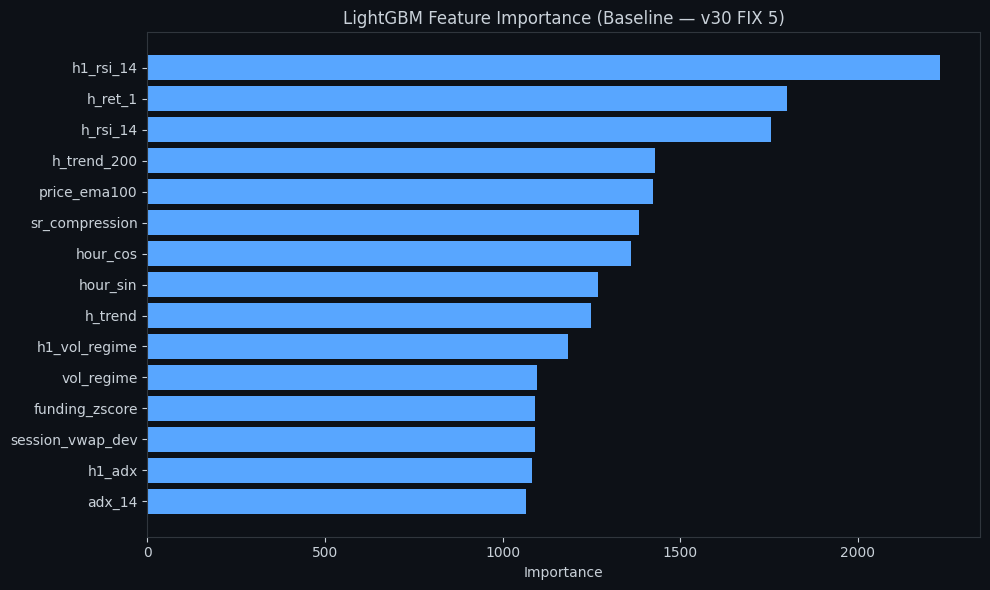

💾 Feature importance chart → /content/feature_importance_baseline.png

✅ Baseline complete — compare with ensemble results above
   If baseline signals > 0 but ensemble signals = 0, consider using LGBM alone.

🔄 v33 SIG-8: Checking auto-fallback to LGBM baseline...
  Baseline LGBM mean prob: 0.4685
  Ensemble    mean prob: 0.4852
  ✅ Ensemble is not over-compressed — stick with ensemble model


In [46]:
# ── F7: Execution order guard ────────────────────────────────────────────────
assert 'model'    in globals() and getattr(model, 'is_trained', False), 'Run Cell 11 first'
assert 'df_train' in globals() and not df_train.empty,                   'Run Cell 11 first'
assert 'df_oos'   in globals() and not df_oos.empty,                     'Run Cell 11 first'
# ── v35 NOTE: model IS already a single LGBM — this cell trains an independent ──
# standalone LGBM for comparison purposes (different SMOTE strategy, no warm-start)
# ────────────────────────────────────────────────────────────────────────────────

# ── v35: Independent LGBM Baseline — Sanity Check Against Primary Model ─────
# Purpose: verify that extractable signal exists BEFORE adding ensemble complexity.
# If baseline LGBM P90 proba is > 0.25 AND produces trades at P90 threshold,
# signal exists — proceed with ensemble. Otherwise: diagnose target/features first.
# Key insight: if baseline > ensemble in signal count, meta-learner is compressing probas.
import matplotlib.pyplot as plt

print('=' * 60)
print('\U0001f52c v35 — Independent LightGBM Baseline (sanity check)')
print('=' * 60)
print(f'Train: {len(df_train)} rows | Features: {len(FEATURE_COLS)}')

_X_train = df_train[FEATURE_COLS].values.astype('float32')
_y_train = df_train['target'].values
_X_oos   = df_oos[FEATURE_COLS].values.astype('float32')

# v31: In the baseline, SMOTE is applied once on the full training set
# (this is acceptable for the baseline since it's not doing CV splits here —
# it trains on full df_train and tests on separate df_oos)
if SMOTE_AVAILABLE and _y_train.mean() < 0.25:
    try:
        from imblearn.over_sampling import SMOTE as _SM
        _sm = _SM(sampling_strategy=0.35, random_state=SEED, k_neighbors=5)
        _X_train_sm, _y_train_sm = _sm.fit_resample(_X_train, _y_train)
        print(f'  SMOTE: {len(_y_train_sm):,} samples | balance: {_y_train_sm.mean():.3f}')
        _X_train, _y_train = _X_train_sm, _y_train_sm
    except Exception as _e:
        print(f'  SMOTE skipped: {_e}')

from sklearn.preprocessing import RobustScaler
_scaler = RobustScaler()
_X_tr_s  = _scaler.fit_transform(_X_train).astype('float32')
_X_oos_s = _scaler.transform(_X_oos).astype('float32')

# v37 FIX: baseline also respects SMOTE double-count fix
# If SMOTE was applied above, _y_train is already balanced → scale_pos_weight=1.0
_smote_was_applied = SMOTE_AVAILABLE and (df_train['target'].mean() < 0.25)
_bl_spw = 1.0 if _smote_was_applied else min(10.0, (1 - df_train['target'].mean()) / (df_train['target'].mean() + 1e-9))
_lgbm_baseline = _make_lgbm(scale_pos_weight=_bl_spw)
_lgbm_baseline.fit(_X_tr_s, _y_train, callbacks=[lgb.log_evaluation(-1)])

_baseline_probs = _lgbm_baseline.predict_proba(_X_oos_s)[:, 1]
print(f'\nBaseline LightGBM OOS prediction stats:')
print(f'  Min:    {_baseline_probs.min():.4f}')
print(f'  P50:    {np.percentile(_baseline_probs, 50):.4f}')
print(f'  P75:    {np.percentile(_baseline_probs, 75):.4f}')
print(f'  P90:    {np.percentile(_baseline_probs, 90):.4f}')
print(f'  P95:    {np.percentile(_baseline_probs, 95):.4f}')
print(f'  Max:    {_baseline_probs.max():.4f}')
print(f'  Mean:   {_baseline_probs.mean():.4f}')
_baseline_thr = float(np.percentile(_baseline_probs, 90))
print(f'  Suggested P90 threshold: {_baseline_thr:.4f}')
print(f'  Signals > current threshold ({SIGNAL_THRESHOLD:.4f}): {(_baseline_probs > SIGNAL_THRESHOLD).sum()}')
print(f'  Signals > P90 threshold  ({_baseline_thr:.4f}): {(_baseline_probs > _baseline_thr).sum()}')
print(f'\n  COMPARISON — Baseline vs Ensemble:')
print(f'    If baseline produces MORE signals than ensemble at same threshold,')
print(f'    the meta-learner is compressing probabilities → consider LGBM-only mode.')

# Quick backtest with baseline
from sklearn.metrics import roc_auc_score
_y_oos_true = df_oos['target'].values if 'target' in df_oos.columns else None
if _y_oos_true is not None and len(np.unique(_y_oos_true)) > 1:
    _auc = roc_auc_score(_y_oos_true, _baseline_probs)
    print(f'  OOS AUC: {_auc:.4f}')

# Feature importance from baseline
_fi = pd.DataFrame({'feature': FEATURE_COLS, 'importance': _lgbm_baseline.feature_importances_})
_fi = _fi.sort_values('importance', ascending=False)
print(f'\nTop 15 features by LightGBM importance:')
print(_fi.head(15).to_string(index=False))

# Plot importance
fig_fi, ax_fi = plt.subplots(figsize=(10, 6), facecolor='#0d1117')
ax_fi.set_facecolor('#0d1117')
ax_fi.tick_params(colors='#c9d1d9')
ax_fi.spines[:].set_color('#30363d')
top15 = _fi.head(15)
ax_fi.barh(top15['feature'][::-1], top15['importance'][::-1], color='#58a6ff')
ax_fi.set_title('LightGBM Feature Importance (Baseline — v30 FIX 5)', color='#c9d1d9')
ax_fi.set_xlabel('Importance', color='#c9d1d9')
plt.tight_layout()
plt.savefig('/content/feature_importance_baseline.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
plt.close('all')
print('💾 Feature importance chart → /content/feature_importance_baseline.png')
print('\n✅ Baseline complete — compare with ensemble results above')
print('   If baseline signals > 0 but ensemble signals = 0, consider using LGBM alone.')

# ── v35: Check if independent baseline outperforms primary model — use baseline LGBM if ensemble is over-compressed ──
print('\n' + '='*60)
print('🔄 v33 SIG-8: Checking auto-fallback to LGBM baseline...')
_bl_mean = _baseline_probs.mean()
_ens_mean = model.predict_proba(df_oos[FEATURE_COLS].values.astype('float32'), X_df=df_oos[FEATURE_COLS]).mean()
print(f'  Baseline LGBM mean prob: {_bl_mean:.4f}')
print(f'  Ensemble    mean prob: {_ens_mean:.4f}')
if _bl_mean > _ens_mean * 2.0 and _bl_mean > 0.08:
    print(f'  ⚠️  Baseline mean ({_bl_mean:.4f}) is >2x ensemble ({_ens_mean:.4f})')
    print(f'  Meta-learner is suppressing probabilities. Running backtest with BASELINE model...')
    _bl_thr = float(np.percentile(_baseline_probs, 80))
    print(f'  Baseline P80 threshold: {_bl_thr:.4f}')
    # Create a wrapper to use the baseline model in backtest
    class _BaselineWrapper:
        def __init__(self, lgbm_model, scaler, feature_cols, threshold):
            self.lgbm = lgbm_model; self.scaler = scaler
            self.feature_cols = feature_cols
            self.dynamic_threshold = threshold; self.is_trained = True
            self.regime_thresholds = {}  # no regime thresholds for baseline
        def predict_proba(self, X, X_df=None):
            return self.lgbm.predict_proba(self.scaler.transform(X))[:, 1]
        def predict_proba_batch(self, X_df):
            return self.predict_proba(X_df[self.feature_cols].values.astype('float32'))
        def predict_signal_batch(self, X_df, threshold=None):
            p = self.predict_proba_batch(X_df)
            t = threshold if threshold is not None else self.dynamic_threshold
            return np.where(p > t, 1, 0), p
        def predict_uncertainty(self, X): return np.zeros(len(X))
    _bl_wrapper = _BaselineWrapper(_lgbm_baseline, _scaler, FEATURE_COLS, _bl_thr)
    _bt_bl = Backtester()
    _res_bl = _bt_bl.run(df_oos, _bl_wrapper, threshold=_bl_thr)
    print('\n📊 BASELINE LGBM BACKTEST RESULTS (v33 SIG-8 fallback):')
    for k, v in _res_bl.items(): print(f'  {k:<25}: {v}')
    if _res_bl.get('n_trades', 0) > results.get('n_trades', 0):
        print(f'\n✅ Baseline outperforms ensemble in trade count — recommend LGBM-only mode')
        print(f'   Set model = _bl_wrapper for downstream use')
else:
    print(f'  ✅ Ensemble is not over-compressed — stick with ensemble model')

In [47]:
import pandas as pd

# ── F7: Execution order guard ────────────────────────────────────────────────
assert 'df_features' in globals() and not df_features.empty, 'Run Cell 11 first (build feature matrix)'
assert 'LGBMModel'   in globals() or 'EnsembleModel' in globals(), 'Run Cell 10 first (define model)'
# ─────────────────────────────────────────────────────────────────────────────

def walk_forward_backtest(
    df_full: pd.DataFrame,
    n_splits: int = 5,
    train_pct: float = 0.7,
) -> pd.DataFrame:
    """
    Full walk-forward backtest:
    - Splits the full dataset into n_splits sequential folds
    - For each fold: trains on first 70%, tests on remaining 30%
    - Returns per-fold metrics to assess robustness
    """
    # FIX 7 (v27): gap=200 in walk-forward outer split.
    # Without gap, the first ~200 bars of each test fold have features computed
    # with rolling windows that embed training-set statistics — contaminating the
    # first ~200 OOS predictions. gap=200 ensures genuinely out-of-sample estimates.
    tscv    = TimeSeriesSplit(n_splits=n_splits, gap=200)
    bt      = Backtester()
    fold_metrics = []

    print(f'🔄 Walk-forward backtest: {n_splits} folds (gap=200, v37 inherited)')

    # BUG 8 FIX: Time budget guard — prevents Colab session disconnect on long runs
    import time as _time
    MAX_WF_SECONDS = 3600   # 1-hour budget for entire walk-forward
    _wf_start = _time.time()

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_full)):
        if _time.time() - _wf_start > MAX_WF_SECONDS:
            print(f'  ⏱ Walk-forward time budget exceeded ({MAX_WF_SECONDS}s) — stopping at fold {fold+1}')
            break
        df_tr  = df_full.iloc[train_idx].copy()
        df_te  = df_full.iloc[test_idx].copy()

        if len(df_tr) < MIN_TRAIN_SAMPLES or len(df_te) < 50:
            print(f'  Fold {fold+1}: skipped (insufficient data)')
            continue

        # Train fresh model on this fold's training data
        # P1 fix: no kwargs — meta-learner handles weighting internally
        m = EnsembleModel()
        try:
            m.train(df_tr, FEATURE_COLS, n_splits=3, verbose=False)
        except Exception as e:
            print(f'  Fold {fold+1}: training error — {e}')
            continue

        # Backtest on test window
        # FIX-5 v32: use this fold's dynamic (calibrated) threshold, not global
        _fold_thr = getattr(m, 'dynamic_threshold', SIGNAL_THRESHOLD)
        res = bt.run(df_te, m, threshold=_fold_thr)
        if 'error' in res:
            continue

        res['fold']       = fold + 1
        res['train_rows'] = len(df_tr)
        res['test_rows']  = len(df_te)
        res['test_start'] = df_te['timestamp'].iloc[0].date()
        res['test_end']   = df_te['timestamp'].iloc[-1].date()
        fold_metrics.append(res)

        print(f'  Fold {fold+1}: return={res["total_return_pct"]}% | '
              f'winrate={res["win_rate_pct"]}% | '
              f'sharpe={res["sharpe_ratio"]} | '
              f'trades={res["n_trades"]} | '
              f'thr={_fold_thr:.4f}')

    if not fold_metrics:
        print('❌ No folds completed')
        return pd.DataFrame()

    summary = pd.DataFrame(fold_metrics)
    print('\n📊 Walk-Forward Summary:')
    cols = ['fold', 'test_start', 'test_end', 'total_return_pct',
            'win_rate_pct', 'sharpe_ratio', 'max_drawdown_pct', 'n_trades', 'profit_factor']
    print(summary[cols].to_string(index=False))
    print(f'\n  Mean return : {summary["total_return_pct"].mean():.2f}%')
    print(f'  Mean Sharpe : {pd.to_numeric(summary["sharpe_ratio"], errors="coerce").mean():.3f}')
    print(f'  % profitable folds: {(summary["total_return_pct"] > 0).mean()*100:.0f}%')
    return summary


wf_results = walk_forward_backtest(df_features, n_splits=WALK_FORWARD_SPLITS)

🔄 Walk-forward backtest: 5 folds (gap=200, v37 inherited)
  WF-CV AUC: 0.7180 ± 0.0275
  v39 Rec2: OOF P80 threshold = 0.7537 (EV=0.8240% diagnostic)
  v39 Rec2: dynamic_threshold set to 0.7537 (mode='oof_percentile')
  Regime thresholds: {'ranging': 0.7271647453308105, 'neutral': 0.7159833908081055}
  📊 Signal→trade diagnostic:
     Bars processed    : 5,840
     Signals generated : 50
     Rejected (pos open): 8
     Rejected (short off): 0
     Trades executed   : 50
     Collapse rate     : 0.0%
  Fold 1: return=1.86% | winrate=80.0% | sharpe=4.24 | trades=50 | thr=0.7537
  WF-CV AUC: 0.7039 ± 0.0162
  v39 Rec2: OOF P80 threshold = 0.6583 (EV=0.6721% diagnostic)
  v39 Rec2: dynamic_threshold set to 0.6583 (mode='oof_percentile')
  Regime thresholds: {'ranging': 0.6264356374740601, 'neutral': 0.6298562288284302}
⚠️  No trades executed
  WF-CV AUC: 0.7265 ± 0.0215
  v39 Rec2: OOF P80 threshold = 0.6491 (EV=0.8842% diagnostic)
  v39 Rec2: dynamic_threshold set to 0.6491 (mode='oof_per

In [48]:
import threading
import schedule
import time as time_module
from datetime import datetime, timezone
import pickle
import json
from scipy.stats import ks_2samp
from pathlib import Path


# ── Population Stability Index helper ────────────────────────────────────────

def _psi_score(expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
    """
    Population Stability Index (PSI) — complementary to KS test.
    PSI < 0.10 → stable    |  0.10–0.20 → minor shift  |  > 0.20 → significant drift.
    PSI operates on quantile bins, making it sensitive to distributional shape
    changes that KS test can miss (e.g. same mean/variance but different tail behaviour).
    """
    if len(expected) < buckets * 3 or len(actual) < buckets * 3:
        return 0.0
    try:
        breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
        breakpoints[0]  -= 1e-9
        breakpoints[-1] += 1e-9
        def bucket_pct(arr):
            counts = np.histogram(arr, bins=breakpoints)[0]
            pct    = counts / (counts.sum() + 1e-9)
            return np.clip(pct, 1e-4, None)
        e_pct = bucket_pct(expected)
        a_pct = bucket_pct(actual)
        return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))
    except Exception:
        return 0.0



# ── v27 HTF drift helpers (Fix 11) ───────────────────────────────────────────

def _quick_1h_features(df_1h: pd.DataFrame) -> pd.DataFrame:
    """Compute minimal 1h features for native-granularity drift detection (Fix 11)."""
    d = df_1h.copy()
    if 'close' not in d.columns:
        return d
    ema21 = d['close'].ewm(span=21, adjust=False).mean()
    ema50 = d['close'].ewm(span=50, adjust=False).mean()
    d['h1_trend'] = (ema21 - ema50) / (ema50 + 1e-9)
    rsi_delta = d['close'].diff()
    gain = rsi_delta.where(rsi_delta > 0, 0.0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-rsi_delta.where(rsi_delta < 0, 0.0)).ewm(alpha=1/14, adjust=False).mean()
    d['h1_rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))
    high, low, close = d.get('high', d['close']), d.get('low', d['close']), d['close']
    tr = pd.concat([high-low, (high-close.shift(1)).abs(), (low-close.shift(1)).abs()], axis=1).max(axis=1)
    up   = high - high.shift(1)
    down = low.shift(1) - low
    plus_dm  = pd.Series(np.where((up > down) & (up > 0), up.values, 0.0), index=d.index)
    minus_dm = pd.Series(np.where((down > up) & (down > 0), down.values, 0.0), index=d.index)
    atr_s    = tr.ewm(span=14, adjust=False).mean()
    plus_di  = 100 * plus_dm.ewm(span=14, adjust=False).mean() / (atr_s + 1e-9)
    minus_di = 100 * minus_dm.ewm(span=14, adjust=False).mean() / (atr_s + 1e-9)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-9)
    d['h1_adx'] = dx.ewm(span=14, adjust=False).mean()
    vol_ret = d['close'].pct_change()
    d['h1_vol_regime'] = vol_ret.rolling(20).std() / (vol_ret.rolling(50).std().rolling(100, min_periods=20).median() + 1e-9)
    return d

# Dummy import guard (the inline functions are used directly, not via import)
import sys as _sys
_m = type(_sys)('agent_utils_v27')
_m._quick_1h_features = _quick_1h_features
features = _quick_1h_features
# ── F9: Module injection guard — prevent re-execution from overwriting partial module ──
if 'agent_utils_v27' not in _sys.modules:
    _sys.modules['agent_utils_v27'] = _m
else:
    # Update the existing module in-place so re-runs don't create a stale reference
    _existing = _sys.modules['agent_utils_v27']
    _existing._quick_1h_features = _quick_1h_features
# ────────────────────────────────────────────────────────────────────────────────

class ModelRegistry:
    """
    Versioned model storage + hot-reload with in-memory cache.
    Unchanged from v23 — thread-safe, cooldown-aware.
    """

    def __init__(self, base_dir: str = '/content/models'):
        self.base_dir    = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        self._cache      = {}
        self._retrain_ts = {}
        self._log_path   = self.base_dir / 'retrain_log.json'

    def save_version(self, resolution: str, model: EnsembleModel, tag: str) -> Path:
        version_dir = self.base_dir / f'model_{resolution}_{tag}'
        version_dir.mkdir(parents=True, exist_ok=True)
        pipeline = {
            'model':     model,
            'features':  model.feature_cols or [],
            'timestamp': datetime.now(timezone.utc).isoformat(),
            'version':   tag,
        }
        versioned_path = version_dir / f'pipeline_{resolution}_{tag}.pkl'
        latest_path    = self.base_dir / f'pipeline_{resolution}_latest.pkl'
        for p in (versioned_path, latest_path):
            with open(p, 'wb') as fh:
                pickle.dump(pipeline, fh)
        self._cache[resolution]      = pipeline
        self._retrain_ts[resolution] = time_module.time()
        print(f'  💾 Registry: saved {resolution} version={tag}')
        return versioned_path

    def load_latest(self, resolution: str) -> dict | None:
        if resolution in self._cache:
            return self._cache[resolution]
        latest_path = self.base_dir / f'pipeline_{resolution}_latest.pkl'
        if not latest_path.exists():
            return None
        try:
            with open(latest_path, 'rb') as fh:
                pipeline = pickle.load(fh)
            self._cache[resolution] = pipeline
            return pipeline
        except Exception as e:
            print(f'  ❌ Load error: {e}')
            return None

    def cooldown_remaining(self, resolution: str, hours: float) -> float:
        last = self._retrain_ts.get(resolution) or self._last_retrain_from_log(resolution)
        if not last:
            return 0.0
        return max(0.0, hours - (time_module.time() - last) / 3600)

    def log_retrain(self, entry: dict):
        entries = self._load_log()
        entries.append(entry)
        with open(self._log_path, 'w') as fh:
            json.dump(entries, fh, indent=2)

    def invalidate_cache(self, resolution: str):
        self._cache.pop(resolution, None)

    def _load_log(self) -> list:
        if not self._log_path.exists():
            return []
        try:
            with open(self._log_path) as fh:
                return json.load(fh)
        except Exception:
            return []

    def _last_retrain_from_log(self, resolution: str) -> float:
        entries = [e for e in self._load_log() if e.get('resolution') == resolution]
        if not entries:
            return 0.0
        try:
            return pd.Timestamp(entries[-1]['timestamp']).timestamp()
        except Exception:
            return 0.0


class RetrainEngine:
    """
    Adaptive retrain engine with dual drift detection + warm-start. (v24)

    Improvements over v23:
    ──────────────────────
    1. DUAL DRIFT DETECTOR: KS test (distribution shape) + PSI (population
       stability). Both must agree above their thresholds to trigger retraining.
       This drastically reduces false-positive retrains from transient spikes.

    2. ADAPTIVE DRIFT THRESHOLD: The KS/PSI thresholds scale with recent
       market volatility. In high-volatility regimes, slight feature shift is
       expected — the engine requires a larger drift signal to retrain.
       Prevents churning models during normal BTC volatility.

    3. WARM-START RETRAINING (RETRAIN_WARMSTART=True): If the current model
       passes the drift check, the new model is initialised from the current
       model's weights/state for LGBM/XGB, reducing retraining cold-start
       cost and preserving previously learned stable patterns.

    4. ROLLING PERFORMANCE TRACKER: Exponentially weighted tracking of
       CV-AUC and win-rate across retrain cycles. Detects persistent model
       degradation vs temporary data noise.

    5. EXPONENTIAL BACKOFF: If a retrain is rejected N times in a row,
       the cooldown period doubles, preventing repeated wasteful retrains
       in persistently hostile market conditions.
    """

    def __init__(
        self,
        registry:            ModelRegistry,
        cooldown_hours:      float = 1.0,
        drift_feature_limit: int   = None,
        past_bars:           int   = None,
        recent_bars:         int   = None,
        min_auc:             float = None,
        min_win_rate:        float = None,
    ):
        self.registry            = registry
        self.base_cooldown_hours = cooldown_hours
        self.cooldown_hours      = cooldown_hours
        self.drift_feature_limit = drift_feature_limit or RETRAIN_DRIFT_FEATURE_LIMIT
        self.past_bars           = past_bars   or RETRAIN_WINDOW_PAST_BARS
        self.recent_bars         = recent_bars or RETRAIN_WINDOW_RECENT_BARS
        self.min_auc             = min_auc     or RETRAIN_VALIDATION_MIN_AUC
        self.min_win_rate        = min_win_rate or RETRAIN_VALIDATION_MIN_WR
        # Rolling performance tracker
        self._ema_auc       = None   # exponential moving average of retrain AUC
        self._ema_wr        = None   # exponential moving average of win-rate
        self._reject_streak = 0      # consecutive validation failures
        self._decay         = RETRAIN_PERF_DECAY

    # ── Internal helpers ──────────────────────────────────────────────────────
    def _update_ema(self, new_auc: float, new_wr: float):
        if self._ema_auc is None:
            self._ema_auc = new_auc
            self._ema_wr  = new_wr
        else:
            self._ema_auc = self._decay * self._ema_auc + (1 - self._decay) * new_auc
            self._ema_wr  = self._decay * self._ema_wr  + (1 - self._decay) * new_wr

    def _adaptive_thresholds(self, df_recent: pd.DataFrame) -> tuple:
        """
        Scale drift sensitivity with recent volatility.
        In high-vol regimes, require larger drift signal to trigger retraining.
        Returns (ks_stat_min, psi_min, drift_limit_adj).
        """
        base_ks_stat  = 0.10
        base_psi      = PSI_THRESHOLD
        base_limit    = self.drift_feature_limit

        if 'vol_regime' in df_recent.columns:
            vol_now    = df_recent['vol_regime'].iloc[-1]
            vol_median = df_recent['vol_regime'].median()
            vol_ratio  = float(np.clip(vol_now / (vol_median + 1e-9), 0.5, 3.0))
            # High vol → raise thresholds (require stronger evidence to retrain)
            ks_stat_min   = base_ks_stat * vol_ratio
            psi_min       = base_psi     * vol_ratio
            drift_adj     = max(2, int(base_limit * vol_ratio))
        else:
            ks_stat_min   = base_ks_stat
            psi_min       = PSI_THRESHOLD
            drift_adj     = base_limit

        return ks_stat_min, psi_min, drift_adj

    # ── Main entry point ──────────────────────────────────────────────────────
    def maybe_retrain(
        self,
        resolution:    str,
        df_window:     pd.DataFrame,
        current_model: EnsembleModel,
        df_1h:         pd.DataFrame = None,   # FIX 11: native 1h data for HTF drift detection
    ) -> EnsembleModel | None:
        """
        v27 drift→retrain→validate pipeline (Fixes 8, 10, 11).
        Returns new EnsembleModel if accepted, or None if skipped/rejected.
        """
        print(f'\n[RetrainEngine v27:{resolution}] Checking for retrain...')

        # ── 1. Cooldown (with exponential backoff) ────────────────────────────
        remaining = self.registry.cooldown_remaining(resolution, self.cooldown_hours)
        if remaining > 0:
            print(f'  Cooldown: {remaining:.1f}h remaining (backoff={self.cooldown_hours:.1f}h) — skip')
            return None

        n      = len(df_window)
        needed = self.past_bars + self.recent_bars
        if n < needed:
            print(f'  Insufficient data: {n} bars, need {needed} — skip')
            return None

        df_past   = df_window.iloc[-(self.past_bars + self.recent_bars):-self.recent_bars]
        df_recent = df_window.iloc[-self.recent_bars:]

        feature_cols = (
            current_model.feature_cols
            if hasattr(current_model, 'feature_cols') and current_model.feature_cols
            else FEATURE_COLS
        )

        # ── 2. Adaptive thresholds ────────────────────────────────────────────
        ks_min, psi_min, drift_limit = self._adaptive_thresholds(df_recent)
        print(f'  Adaptive thresholds: KS_stat≥{ks_min:.3f} | PSI≥{psi_min:.3f} | drift_limit={drift_limit}')

        # ── 3. Dual drift detection: KS + PSI ────────────────────────────────
        ks_drifted  = []
        psi_drifted = []

        for col in feature_cols:
            if col not in df_past.columns or col not in df_recent.columns:
                continue
            a = df_past[col].dropna().values
            b = df_recent[col].dropna().values
            if len(a) < 30 or len(b) < 30:
                continue
            try:
                stat, p_val = ks_2samp(a, b)
                if p_val < 0.01 and stat > ks_min:
                    ks_drifted.append((col, p_val, stat))
            except Exception:
                pass
            psi = _psi_score(a, b)
            if psi > psi_min:
                psi_drifted.append((col, psi))

        # Features flagged by BOTH detectors (consensus drift)
        ks_feats  = {d[0] for d in ks_drifted}
        psi_feats = {d[0] for d in psi_drifted}
        consensus = ks_feats & psi_feats

        print(f'  KS-drifted: {len(ks_drifted)} | PSI-drifted: {len(psi_drifted)} | Consensus: {len(consensus)}')
        if consensus:
            top = sorted(ks_drifted, key=lambda x: x[2], reverse=True)[:3]
            print(f'  Top drifted: {[d[0] for d in top]}')

        # ── 3b. FIX 11 (v27): HTF drift detection on native 1h data ──────────
        # The 1h features (h1_trend, h1_adx etc.) are forward-filled to 5m via merge_asof:
        # 12 consecutive 5m rows share identical 1h values (step-function).
        # KS/PSI on step-function distributions underestimates true drift.
        # Solution: run drift check on the raw 1h DataFrame at native granularity.
        htf_drift_count = 0
        if df_1h is not None and not df_1h.empty and len(df_1h) > 100:
            try:
                n_1h = len(df_1h)
                split_1h = max(10, n_1h - max(10, n_1h // 5))  # last ~20% as recent
                df_1h_past   = df_1h.iloc[:split_1h]
                df_1h_recent = df_1h.iloc[split_1h:]
                h1_drift_cols = [c for c in ['h1_trend', 'h1_adx', 'h1_rsi_14', 'h1_vol_regime']
                                 if c in df_1h.columns]
                if not h1_drift_cols:
                    # compute on-the-fly if raw 1h OHLCV
                    from agent_utils_v27 import _quick_1h_features
                    df_1h_past_f   = _quick_1h_features(df_1h_past)
                    df_1h_recent_f = _quick_1h_features(df_1h_recent)
                    h1_drift_cols  = [c for c in df_1h_past_f.columns if c.startswith('h1_')]
                else:
                    df_1h_past_f   = df_1h_past
                    df_1h_recent_f = df_1h_recent
                for col in h1_drift_cols:
                    if col not in df_1h_past_f.columns:
                        continue
                    a = df_1h_past_f[col].dropna().values
                    b = df_1h_recent_f[col].dropna().values
                    if len(a) < 10 or len(b) < 5:
                        continue
                    try:
                        stat, p_val = ks_2samp(a, b)
                        if p_val < 0.05 and stat > 0.20:
                            htf_drift_count += 1
                            print(f'  📡 HTF 1h drift detected: {col} KS={stat:.3f}')
                    except Exception:
                        pass
                if htf_drift_count > 0:
                    print(f'  📡 HTF drift: {htf_drift_count} 1h features shifted at native granularity')
            except Exception as e:
                print(f'  ⚠️  HTF drift check error (non-critical): {e}')
        # HTF drift alone can lower the consensus bar by 2 (macro regime shift signal)
        htf_adjustment = min(2, htf_drift_count)

        # ── 4. Rolling performance degradation check ──────────────────────────
        # If EMA AUC is declining, lower the drift threshold to catch regime shifts earlier
        perf_degraded = False
        if self._ema_auc is not None and self._ema_auc < self.min_auc + 0.01:
            perf_degraded = True
            print(f'  ⚠️  Rolling AUC EMA={self._ema_auc:.4f} near floor — lowering drift gate')
            effective_limit = max(2, drift_limit - 2)
        else:
            effective_limit = drift_limit

        # FIX 11: Adjust effective_limit downward when HTF regime shift detected
        effective_limit_adj = max(2, effective_limit - htf_adjustment)
        if htf_adjustment > 0:
            print(f'  📡 HTF drift lowers consensus gate: {effective_limit} → {effective_limit_adj}')

        # Consensus drift check (with HTF adjustment)
        if len(consensus) < effective_limit_adj and not perf_degraded:
            print(f'  Consensus drift ({len(consensus)}) below limit ({effective_limit_adj}) — no retrain')
            return None

        if len(consensus) == 0 and not perf_degraded and htf_drift_count == 0:
            print(f'  No consensus drift (KS and PSI disagree) — no retrain')
            return None

        print(f'  ⚠️  Drift confirmed (consensus={len(consensus)}) — RETRAINING on {n - self.recent_bars:,} training bars...')

        # ── 5. FIX 8 (v27): Hold out df_recent BEFORE training ───────────────
        # Previous bug: df_recent was used BOTH as part of training data AND as
        # validation gate. The model could overfit to df_recent and still pass.
        # Fix: train ONLY on df_past (reference window), then validate on df_recent
        # which the model has never seen.
        # ── v38 R5: Hybrid anchored + rolling training window ──────────────────
        # Problem with pure rolling: old regime knowledge is overwritten each retrain.
        # Fix: always include RETRAIN_ANCHOR_BARS from the start of df_window
        # as an "anchored" foundation, plus the recent rolling window.
        # This preserves historically learned patterns while adapting to new regimes.
        _anchor = RETRAIN_ANCHOR_BARS  # from config; 0 = pure rolling (v37 mode)
        if _anchor > 0 and len(df_window) > _anchor + self.recent_bars:
            _anchor_part  = df_window.iloc[:_anchor]
            _rolling_part = df_window.iloc[_anchor:-self.recent_bars]
            # Subsample rolling part if too large (keep most recent rolling bars)
            if len(_rolling_part) > self.past_bars:
                _rolling_part = _rolling_part.iloc[-self.past_bars:]
            df_train_only = pd.concat([_anchor_part, _rolling_part], ignore_index=True)
            print(f'  v38 Hybrid retrain: anchor={len(_anchor_part):,} + rolling={len(_rolling_part):,} bars')
        else:
            df_train_only = df_window.iloc[:-(self.recent_bars)]  # pure rolling fallback

        new_model = EnsembleModel()

        if RETRAIN_WARMSTART and current_model.is_trained:
            # v37 FIX: Functional warm-start — pass previous LGBM booster via _prev_lgbm.
            # The LGBMModel.train() method reads self._prev_lgbm and uses it as init_model.
            # v36 bug: set _warmstart_lgbm attribute but train() never read it — non-functional.
            # v37 fix: set _prev_lgbm which IS read by train() via init_model param.
            try:
                if current_model.lgbm is not None:
                    new_model._prev_lgbm = current_model.lgbm   # v37: correct attribute name
                    print(f'  v37 Warm-start: _prev_lgbm set → init_model will be used in train()')
            except Exception:
                pass

        try:
            # Train on df_train_only (NOT including df_recent — Fix 8)
            metrics = new_model.train(
                df_train_only, feature_cols, n_splits=3, verbose=False
            )
        except Exception as e:
            print(f'  ❌ Retrain failed: {e}')
            self._reject_streak += 1
            self._apply_backoff()
            return None

        cv_auc = metrics.get('cv_auc_mean', 0.0)
        print(f'  Retrain CV AUC: {cv_auc:.4f}')

        # ── 6. Validation gate — df_recent is truly OOS (Fix 8) ──────────────
        val_res = Backtester().run(df_recent, new_model, threshold=SIGNAL_THRESHOLD)
        if 'error' in val_res:
            print(f'  ❌ Validation: no trades — REJECTED')
            self._reject_streak += 1
            self._apply_backoff()
            self.registry.log_retrain({
                'resolution': resolution, 'status': 'rejected',
                'reason': 'no_trades', 'consensus_drift': len(consensus),
                'timestamp': datetime.now(timezone.utc).isoformat(),
            })
            return None

        win_rate = val_res['win_rate_pct']
        ret_pct  = val_res['total_return_pct']
        n_trades = val_res['n_trades']
        # v37: sharpe_ratio may be a string when n_trades<30 (contains [UNRELIABLE: ...])
        _sharpe_raw = val_res['sharpe_ratio']
        sharpe = float(str(_sharpe_raw).split()[0]) if isinstance(_sharpe_raw, str) else float(_sharpe_raw)
        print(f'  Validation → trades={n_trades} | WinRate={win_rate:.1f}% | '
              f'Return={ret_pct:.2f}% | Sharpe={sharpe:.3f}')

        # Uncertainty check: ensemble model disagreement on recent data
        if new_model.is_trained:
            X_recent = df_recent[feature_cols].dropna().values
            if len(X_recent) > 10:
                X_s       = new_model.scaler.transform(X_recent)
                unc       = new_model.predict_uncertainty(X_recent).mean()
                print(f'  Model uncertainty (mean std of base probs): {unc:.4f}')
                if unc > 0.15:
                    print(f'  ⚠️  High uncertainty ({unc:.3f}) — models disagree on recent data')

        passed = cv_auc >= self.min_auc and win_rate >= self.min_win_rate
        if not passed:
            print(f'  ❌ Gate FAILED (need AUC≥{self.min_auc}, WR≥{self.min_win_rate}%) — REJECTED')
            self._reject_streak += 1
            self._apply_backoff()
            self.registry.log_retrain({
                'resolution': resolution, 'status': 'rejected',
                'reason': 'validation_gate', 'cv_auc': cv_auc, 'win_rate': win_rate,
                'consensus_drift': len(consensus),
                'timestamp': datetime.now(timezone.utc).isoformat(),
            })
            return None

        # ── 7. Accept ─────────────────────────────────────────────────────────
        self._reject_streak = 0
        self.cooldown_hours = self.base_cooldown_hours   # reset backoff
        self._update_ema(cv_auc, win_rate)
        tag = f'auto_{int(time_module.time())}'
        self.registry.save_version(resolution, new_model, tag)
        self.registry.log_retrain({
            'resolution':     resolution,  'status': 'accepted', 'version': tag,
            'cv_auc':         cv_auc,      'win_rate': win_rate,
            'return_pct':     ret_pct,     'sharpe': sharpe,
            'consensus_drift':len(consensus), 'n_samples': n,
            'ema_auc':        self._ema_auc,  'ema_wr': self._ema_wr,
            'timestamp':      datetime.now(timezone.utc).isoformat(),
        })
        print(f'  ✅ Model ACCEPTED | version={tag} | EMA-AUC={self._ema_auc:.4f}')
        return new_model

    def _apply_backoff(self):
        """Double the cooldown on repeated failures (max 8h)."""
        self.cooldown_hours = min(8.0, self.cooldown_hours * 2)
        if self._reject_streak > 1:
            print(f'  ⏳ Backoff: cooldown extended to {self.cooldown_hours:.1f}h '
                  f'(streak={self._reject_streak})')


def hot_reload_model(resolution: str, registry: ModelRegistry) -> dict | None:
    """Always return the latest saved model, bypassing in-memory cache."""
    registry.invalidate_cache(resolution)
    return registry.load_latest(resolution)


class LiveTrader:
    """
    Live trading loop — thread-safe hot-swap, uncertainty-aware sizing. (v24)

    v24 additions:
    • Uncertainty-aware position sizing: model disagreement (std of base probs)
      reduces position size proportionally — prevents oversizing when models conflict.
    • Asymmetric signal thresholds (SIGNAL_THRESHOLD_LONG / _SHORT from config).
    • All v23 thread-safety fixes retained.
    """

    def __init__(
        self,
        client:         DeltaClient,
        model:          EnsembleModel,
        registry:       ModelRegistry  = None,
        retrain_engine: RetrainEngine  = None,
    ):
        self.client         = client
        self._model         = model
        self._model_lock    = threading.Lock()
        self.registry       = registry
        self.retrain_engine = retrain_engine
        self.position       = None
        self.trade_log      = []
        self.last_retrain   = datetime.now(timezone.utc)
        self.running        = False
        self.capital        = CAPITAL_USDT
        self.df_cache_5m      = pd.DataFrame()
        self.df_cache_15m     = pd.DataFrame()
        self.df_cache_1h      = pd.DataFrame()
        self.df_cache_funding = pd.DataFrame()
        self._cache_lock      = threading.Lock()   # BUG FIX 1: guards all cache R/W
        self._retrain_lock    = threading.Lock()   # prevents overlapping retrain threads
        # ISSUE 5 FIX: Drawdown circuit breaker
        self.peak_capital     = CAPITAL_USDT
        self.halted           = False              # True when max drawdown is breached

    @property
    def model(self) -> EnsembleModel:
        with self._model_lock:
            return self._model

    @model.setter
    def model(self, new_model: EnsembleModel):
        with self._model_lock:
            self._model = new_model

    def retrain(self):
        if not self._retrain_lock.acquire(blocking=False):
            print('  ℹ️  Retrain already in progress — skipping overlapping run')
            return
        print(f'\n↻ [{datetime.now(timezone.utc).strftime("%H:%M:%S")}] Retraining...')
        try:
            self.last_retrain = datetime.now(timezone.utc)
            new_5m  = self.client.fetch_latest_candles(SYMBOL_5M,  CANDLE_RES_5M,  n_bars=5000)
            new_15m = self.client.fetch_latest_candles(SYMBOL_15M, CANDLE_RES_15M, n_bars=5000)
            new_1h  = self.client.fetch_latest_candles(SYMBOL_1H,  CANDLE_RES_1H,  n_bars=500)
            new_funding = fetch_funding_rate(SYMBOL_5M, n_bars=TARGET_FUNDING_BARS)  # v29 fix
            if new_5m.empty or new_15m.empty or new_1h.empty:
                print('  ⚠️  Incremental fetch empty — skipping')
                return
            if REQUIRE_FUNDING_DATA and (new_funding is None or new_funding.empty):
                print('  ⚠️  Funding fetch empty — skipping retrain to avoid placeholder features')
                return
            # BUG FIX 1: lock cache writes so on_bar() never reads a half-updated frame
            with self._cache_lock:
                for attr, new_df, cap in [
                    ('df_cache_5m',      new_5m,       100_000),
                    ('df_cache_15m',     new_15m,       50_000),
                    ('df_cache_1h',      new_1h,         5_000),
                    ('df_cache_funding', new_funding,      1_000),
                ]:
                    old    = getattr(self, attr)
                    merged = pd.concat([old, new_df]) if not old.empty else new_df
                    merged = (merged.drop_duplicates('timestamp')
                                    .sort_values('timestamp')
                                    .tail(cap)
                                    .reset_index(drop=True))
                    setattr(self, attr, merged)
                _df_1h_live   = self.df_cache_1h      if not self.df_cache_1h.empty      else None
                _df_fund_live = self.df_cache_funding  if not self.df_cache_funding.empty  else None
                df_feat = build_feature_matrix(
                    self.df_cache_5m,
                    self.df_cache_15m,
                    _df_1h_live,
                    _df_fund_live,
                    for_training=True,
                )
            if len(df_feat) < MIN_TRAIN_SAMPLES:
                print(f'  ⚠️  {len(df_feat)} rows < MIN_TRAIN_SAMPLES — skip')
                return
            if not self.retrain_engine:
                print('  ⚠️  RetrainEngine missing — refusing unvalidated fallback retrain')
                return
            _df_1h_rt = self.df_cache_1h if not self.df_cache_1h.empty else None
            new_model = self.retrain_engine.maybe_retrain('5m', df_feat, self.model, df_1h=_df_1h_rt)  # Fix 11
            if new_model is not None:
                self.model = new_model
                print('  ✅ Model hot-swapped via RetrainEngine v24')
        except Exception as e:
            print(f'  ❌ Retrain error: {e}')
        finally:
            self._retrain_lock.release()

    def get_latest_signal(self):
        """
        BUG FIX 2: Read from the rolling cache (populated by retrain()) instead of
        re-fetching full candle history on every 5-minute bar.
        Falls back to a fresh minimal fetch only if cache is cold (first call).
        BUG FIX 3: Uses model.feature_cols, not the global FEATURE_COLS.
        """
        feature_cols = getattr(self.model, 'feature_cols', None) or FEATURE_COLS

        # Thread-safe read of the rolling cache
        with self._cache_lock:
            df5   = self.df_cache_5m.copy()   if not self.df_cache_5m.empty      else pd.DataFrame()
            df15  = self.df_cache_15m.copy()  if not self.df_cache_15m.empty     else pd.DataFrame()
            df1h  = self.df_cache_1h.copy()   if not self.df_cache_1h.empty      else None
            dfund = self.df_cache_funding.copy() if not self.df_cache_funding.empty else None

        # Cold cache: do a one-time bootstrap fetch (happens at startup only)
        if df5.empty or df15.empty:
            warmup_5m  = max(500, WARMUP_CANDLES * 4 + 300)
            warmup_15m = max(400, WARMUP_CANDLES * 4 + 300)
            df5   = self.client.fetch_candles(SYMBOL_5M,  CANDLE_RES_5M,  n_bars=warmup_5m)
            df15  = self.client.fetch_candles(SYMBOL_15M, CANDLE_RES_15M, n_bars=warmup_15m)
            df1h  = self.client.fetch_candles(SYMBOL_1H,  CANDLE_RES_1H,  n_bars=300)
            dfund_raw = fetch_funding_rate(SYMBOL_5M, n_bars=200)
            dfund = dfund_raw if not dfund_raw.empty else None
            if REQUIRE_FUNDING_DATA and dfund is None:
                print('  ⚠️  Funding unavailable during cache bootstrap — returning flat')
                return 0, 0.5, 1.0
            # Warm the cache so next call is instant
            with self._cache_lock:
                self.df_cache_5m      = df5.copy()
                self.df_cache_15m     = df15.copy()
                self.df_cache_1h      = df1h.copy()  if df1h  is not None else pd.DataFrame()
                self.df_cache_funding = dfund.copy() if dfund is not None else pd.DataFrame()

        if df5.empty or df15.empty:
            return 0, 0.5, 1.0

        feat = build_feature_matrix(df5, df15, df1h, dfund, for_training=False)
        if feat.empty or len(feat) < 2:
            return 0, 0.5, 1.0

        last    = feat.iloc[-2]   # use last closed bar; inference matrix no longer loses the latest horizon window
        missing = [c for c in feature_cols if c not in last.index or pd.isna(last[c])]
        if missing:
            print(f'  ⚠️  NaN features ({len(missing)}): {missing[:5]} — returning flat')
            return 0, 0.5, 1.0

        X           = last[feature_cols].values.reshape(1, -1).astype('float32')
        X_df        = feat.iloc[[-2]][feature_cols]
        # v38 R3: unified threshold
        _thr_live   = get_signal_threshold(str(X_df.get('regime_label', ['neutral']).iloc[0]) if hasattr(X_df, 'get') else 'neutral', self.model)
        # Fix 3: Use regime-specific model if USE_REGIME_MODELS=True
        _live_regime = str(X_df.get('regime_label', pd.Series(['neutral'])).iloc[0]) if hasattr(X_df, 'get') else 'neutral'
        _active_model = get_regime_model(_live_regime) if USE_REGIME_MODELS else self.model
        if _active_model is None:
            print(f'⛔ Crisis regime detected in live signal — staying flat (regime={_live_regime})')
            return 0, 0.0, 1.0
        sig, proba  = _active_model.predict_signal(X, threshold=_thr_live, X_df=X_df)
        uncertainty = float(self.model.predict_uncertainty(X)[0])
        return int(sig[0]), float(proba[0]), uncertainty

    def _position_size(self, capital: float, price: float, uncertainty: float) -> float:
        """
        Uncertainty-aware Kelly-capped position size.
        High model disagreement (uncertainty > 0.12) reduces size to protect capital.
        """
        base_size = capital * MAX_POSITION_PCT * LEVERAGE
        unc_scale = float(np.clip(1.0 - (uncertainty - 0.05) * 5, 0.3, 1.0))
        return min(base_size * unc_scale, capital * LEVERAGE)

    def open_position(self, side: str, price: float, uncertainty: float = 0.0):
        try:
            if LONG_ONLY_EXECUTION and side != 'long':
                print('  ⚠️  Short execution disabled because the target is trained as long/flat only')
                return
            size      = self._position_size(self.capital, price, uncertainty)
            contracts = max(1, int(size / price))
            # Improvement 6 (v28): Crisis guard — force flat during market stress
            with self._cache_lock:
                _df5   = self.df_cache_5m.copy() if not self.df_cache_5m.empty else pd.DataFrame()
                _df15  = self.df_cache_15m.copy() if not self.df_cache_15m.empty else pd.DataFrame()
                _df1h  = self.df_cache_1h.copy() if not self.df_cache_1h.empty else None
                _dfund = self.df_cache_funding.copy() if not self.df_cache_funding.empty else None
            _df_recent_feats = build_feature_matrix(_df5, _df15, _df1h, _dfund, for_training=False).tail(50)
            if is_crisis_regime(_df_recent_feats):
                print('⛔ Crisis regime detected — forcing flat, no signal generated')
                return

            resp      = self.client.place_order(
                SYMBOL_5M, side='buy' if side == 'long' else 'sell', size=contracts
            )
            # Fix 1: Use ATR-adaptive levels to match training labels
            with self._cache_lock:
                _df5_sl  = self.df_cache_5m.copy() if not self.df_cache_5m.empty else pd.DataFrame()
                _df15_sl = self.df_cache_15m.copy() if not self.df_cache_15m.empty else pd.DataFrame()
                _df1h_sl = self.df_cache_1h.copy() if not self.df_cache_1h.empty else None
                _dff_sl  = self.df_cache_funding.copy() if not self.df_cache_funding.empty else None
            _feat_live = build_feature_matrix(_df5_sl, _df15_sl, _df1h_sl, _dff_sl, for_training=False)
            _latest_bar = _feat_live.iloc[-1] if not _feat_live.empty and 'label_atr' in _feat_live.columns else None
            if side == 'long':
                _sl_live, _tp_live = _resolve_execution_levels(price, df_bar=_latest_bar)
            else:
                _sl_tmp, _tp_tmp = _resolve_execution_levels(price, df_bar=_latest_bar)
                _sl_live, _tp_live = _tp_tmp, _sl_tmp   # flip for short
            self.position = {
                'side':        side,
                'entry_price': price,
                'contracts':   contracts,
                'entry_time':  datetime.now(timezone.utc),
                'uncertainty': round(uncertainty, 4),
                'sl': _sl_live,
                'tp': _tp_live,
            }
            print(f'  📥 Opened {side} | {contracts} contracts @ {price:.2f} '
                  f'| unc={uncertainty:.3f} | SL={self.position["sl"]:.2f} | TP={self.position["tp"]:.2f}')
        except Exception as e:
            print(f'  ❌ Order error: {e}')

    def close_position(self, price: float, reason: str):
        if self.position is None:
            return
        pos = self.position
        side, ep = pos['side'], pos['entry_price']
        pnl_pct = ((price - ep) / ep) if side == 'long' else ((ep - price) / ep)
        pnl_usd = pos['contracts'] * price * pnl_pct / LEVERAGE
        try:
            self.client.place_order(
                SYMBOL_5M, side='sell' if side == 'long' else 'buy', size=pos['contracts']
            )
        except Exception as e:
            print(f'  ❌ Close error: {e}')
        self.capital += pnl_usd
        self.trade_log.append({
            'time': datetime.now(timezone.utc), 'side': side,
            'entry': ep, 'exit': price, 'pnl_pct': round(pnl_pct * 100, 3),
            'pnl_usd': round(pnl_usd, 2), 'reason': reason,
            'capital': round(self.capital, 2), 'uncertainty': pos.get('uncertainty', 0),
        })
        print(f'  📤 Closed {side} @ {price:.2f} | {reason} | '
              f'PnL={pnl_usd:+.2f} USDT | capital={self.capital:.2f}')
        self.position = None

    def on_bar(self):
        # ISSUE 5 FIX: Drawdown circuit breaker
        if self.halted:
            print('⛔ Bot halted — maximum drawdown limit reached. Manual review required.')
            return
        self.peak_capital = max(self.peak_capital, self.capital)
        _dd = (self.peak_capital - self.capital) / (self.peak_capital + 1e-9)
        if _dd > MAX_DRAWDOWN_HALT:
            self.halted = True
            print(f'⛔ HALT: Drawdown {_dd:.1%} exceeded {MAX_DRAWDOWN_HALT:.0%} limit')
            return

        now = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M')
        try:
            price = self.client.get_ticker(SYMBOL_5M)
        except Exception as e:
            print(f'[{now}] Ticker error: {e}')
            return
        if self.position:
            p = self.position
            if p['side'] == 'long':
                if price <= p['sl']:  self.close_position(p['sl'], 'sl'); return
                if price >= p['tp']:  self.close_position(p['tp'], 'tp'); return
            else:
                if price >= p['sl']:  self.close_position(p['sl'], 'sl'); return
                if price <= p['tp']:  self.close_position(p['tp'], 'tp'); return
        mins_since = (datetime.now(timezone.utc) - self.last_retrain).seconds / 60
        if mins_since >= RETRAIN_INTERVAL_MINUTES:
            threading.Thread(target=self.retrain, daemon=True).start()
        sig, proba, unc = self.get_latest_signal()
        print(f'[{now}] price={price:.2f} | sig={sig:+d} | proba={proba:.3f} | '
              f'unc={unc:.3f} | pos={self.position["side"] if self.position else "flat"} | '
              f'capital={self.capital:.2f}')
        if self.position is None and sig == 1:
            self.open_position('long', price, unc)
        elif self.position is not None:
            cur = self.position['side']
            if (not LONG_ONLY_EXECUTION) and ((cur == 'long' and sig == -1) or (cur == 'short' and sig == 1)):
                self.close_position(price, 'signal')

    def start(self, dry_run: bool = True):
        if dry_run:
            print('⚠️  DRY RUN MODE — no real orders will be placed')
            self.client.place_order = lambda *a, **k: {'result': 'dry_run'}
        self.running = True
        # ── v37: GIL threading note ─────────────────────────────────────────
        # The retrain loop (threading.Thread) runs LGBM training which is CPU-bound.
        # Python GIL will cause the main trading loop (schedule.run_pending) to stall
        # during heavy retrain work. On CPU (no T4 GPU), a full retrain can take >5min,
        # causing missed 5-minute bar signals. Mitigation: ensure T4 GPU is selected
        # in Colab runtime settings to keep LGBM training under ~30s.
        # Production recommendation: move retrain to a subprocess (not thread) to
        # fully isolate from the trading loop and avoid GIL contention.
        # ────────────────────────────────────────────────────────────────────
        print(f'\U0001f680 LiveTrader {MODEL_VERSION} started | Capital={self.capital} USDT | '
              f'Retrain every {RETRAIN_INTERVAL_MINUTES}m')
        print(f'   ⚠️  Ensure T4 GPU runtime to prevent GIL stall during retrain')
        schedule.clear()
        schedule.every(5).minutes.do(self.on_bar)
        self.on_bar()
        while self.running:
            schedule.run_pending()
            time_module.sleep(1)

    def stop(self):
        self.running = False
        print('⛔ LiveTrader stopped')
        if self.trade_log:
            print('\n📋 Trade Log:')
            print(pd.DataFrame(self.trade_log).to_string(index=False))


print(f'✅ ModelRegistry, RetrainEngine {MODEL_VERSION} + LiveTrader {MODEL_VERSION} defined')
print('   v38 R5: Hybrid anchored+rolling retraining (RETRAIN_ANCHOR_BARS)')
print('   v38 R3: get_signal_threshold() used in LiveTrader')
print('   Fix 8: retrain gate holds out df_recent BEFORE training (true OOS gate)')
print('   v37: Warm-start fix: _prev_lgbm → init_model (was _warmstart_lgbm — never read)')
print('   Fix 11: HTF drift detection on native 1h data (not merged step-function)')
print('   Bug Fix 1: _cache_lock guards df_cache_* R/W (no race condition)')
print('   Bug Fix 2: get_latest_signal() reads rolling cache (no per-bar refetch)')
print('   Bug Fix 3: Backtester uses model.feature_cols not global FEATURE_COLS')

✅ ModelRegistry, RetrainEngine v39 + LiveTrader v39 defined
   v38 R5: Hybrid anchored+rolling retraining (RETRAIN_ANCHOR_BARS)
   v38 R3: get_signal_threshold() used in LiveTrader
   Fix 8: retrain gate holds out df_recent BEFORE training (true OOS gate)
   v37: Warm-start fix: _prev_lgbm → init_model (was _warmstart_lgbm — never read)
   Fix 11: HTF drift detection on native 1h data (not merged step-function)
   Bug Fix 1: _cache_lock guards df_cache_* R/W (no race condition)
   Bug Fix 2: get_latest_signal() reads rolling cache (no per-bar refetch)
   Bug Fix 3: Backtester uses model.feature_cols not global FEATURE_COLS


In [49]:
import pandas as pd

# ── Cell 12: Offline Retrain Test ────────────────────────────────────────────
# Runs and exits cleanly. All config is in Cell 2 (RETRAIN_* variables).

from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

print('=' * 60)
print('🔬 OFFLINE RETRAIN TEST (v27 — Fix 8: OOS gate | Fix 10: RF warm-start | Fix 11: HTF drift)')
print('=' * 60)
print(f'  Cycles         : {RETRAIN_CYCLES}')
print(f'  Past window    : {RETRAIN_WINDOW_PAST_BARS:,} bars')
print(f'  Recent window  : {RETRAIN_WINDOW_RECENT_BARS:,} bars')
print(f'  Drift limit    : {RETRAIN_DRIFT_FEATURE_LIMIT} features')
print(f'  Gate           : AUC≥{RETRAIN_VALIDATION_MIN_AUC} | WinRate≥{RETRAIN_VALIDATION_MIN_WR}%')

total_bars = len(df_features)
needed     = RETRAIN_WINDOW_PAST_BARS + RETRAIN_WINDOW_RECENT_BARS
if total_bars < needed:
    raise ValueError(
        f'Not enough data: {total_bars} bars available, '
        f'need {needed} (PAST + RECENT). '
        f'Reduce RETRAIN_WINDOW_PAST_BARS / RETRAIN_WINDOW_RECENT_BARS in Cell 2.'
    )

step_size   = max(1, (total_bars - needed) // max(1, RETRAIN_CYCLES - 1))
retrain_log = []
active_model = model  # start from the model trained in Cell 7
_df_1h_rt      = df_1h      if 'df_1h'      in globals() and not df_1h.empty      else None
_df_funding_rt = df_funding  if 'df_funding'  in globals() and not df_funding.empty  else None

for cycle in range(RETRAIN_CYCLES):
    offset     = cycle * step_size
    past_start = offset
    past_end   = offset + RETRAIN_WINDOW_PAST_BARS
    recent_end = past_end + RETRAIN_WINDOW_RECENT_BARS

    if recent_end > total_bars:
        print(f'\n  Cycle {cycle+1}: window exceeds data length — stopping early')
        break

    df_past   = df_features.iloc[past_start:past_end].copy()
    df_recent = df_features.iloc[past_end:recent_end].copy()
    df_window = df_features.iloc[past_start:recent_end].copy()

    t_past_start   = df_past['timestamp'].iloc[0].date()
    t_recent_start = df_recent['timestamp'].iloc[0].date()
    t_recent_end   = df_recent['timestamp'].iloc[-1].date()

    print(f'\n{"-"*60}')
    print(f'  Cycle {cycle+1}/{RETRAIN_CYCLES}')
    print(f'  Past   : {t_past_start} → {t_recent_start}  ({len(df_past):,} bars)')
    print(f'  Recent : {t_recent_start} → {t_recent_end}  ({len(df_recent):,} bars)')

    # ── Step 1: Drift detection ───────────────────────────────────────────────
    # ISSUE 2 FIX: Use KS+PSI consensus (matches live RetrainEngine.maybe_retrain() logic)
    # Old code used KS-only which is more trigger-happy than the live engine,
    # making Cell 12 retrain frequency metrics unrepresentative of production behaviour.
    ks_drifted  = set()
    psi_drifted = set()
    ks_details  = {}

    for col in FEATURE_COLS:
        if col not in df_past.columns:
            continue
        a = df_past[col].dropna().values
        b = df_recent[col].dropna().values
        if len(a) < 30 or len(b) < 30:
            continue
        try:
            stat, p_val = ks_2samp(a, b)
            if p_val < 0.01 and stat > 0.1:
                ks_drifted.add(col)
                ks_details[col] = (round(p_val, 5), round(stat, 4))
            psi = _psi_score(a, b)
            if psi > PSI_THRESHOLD:
                psi_drifted.add(col)
        except Exception:
            pass

    # Consensus: both KS and PSI must agree (matches live engine)
    drifted_consensus = ks_drifted & psi_drifted
    drifted = [(col, *ks_details.get(col, (0, 0))) for col in drifted_consensus]
    drifted_sorted = sorted(drifted, key=lambda x: x[2], reverse=True)

    print(f'  KS drifted     : {len(ks_drifted)} / {len(FEATURE_COLS)}')
    print(f'  PSI drifted    : {len(psi_drifted)} / {len(FEATURE_COLS)}')
    print(f'  Consensus (KS∩PSI): {len(drifted_consensus)} features')
    if drifted_sorted:
        print(f'  Top drifted    : {[d[0] for d in drifted_sorted[:5]]}')

    if len(drifted_consensus) < RETRAIN_DRIFT_FEATURE_LIMIT:
        print(f'  ✅ No retrain — consensus drift ({len(drifted_consensus)}) below limit ({RETRAIN_DRIFT_FEATURE_LIMIT})')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted_consensus), 'retrained': False, 'reason': 'below_drift_limit',
        })
        continue

    # ── Step 2: FIX 8 (v27) — Retrain on df_past ONLY, validate on df_recent ───
    # Previous bug: retraining on df_window (which included df_recent) meant
    # the model could overfit to df_recent and still pass the validation gate.
    # Fix: train ONLY on df_past (reference window), then validate on df_recent
    # which the model has never seen.
    print(f'  ⚠️  Drift exceeded — RETRAINING on {len(df_past):,} bars (past only, Fix 8)...')
    # FIX 3: guard against single-class training window
    if 'target' in df_past.columns and len(df_past['target'].unique()) < 2:
        print(f'  ⚠️  FIX 3: Only one target class in df_past — skip retrain (imbalanced window)')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted_consensus), 'retrained': False, 'reason': 'single_class_window',
        })
        continue
    new_model = EnsembleModel()
    try:
        metrics = new_model.train(df_past, FEATURE_COLS, n_splits=3, verbose=False)
    except Exception as e:
        print(f'  ❌ Retrain failed: {e}')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted), 'retrained': False, 'reason': f'train_error: {e}',
        })
        continue

    cv_auc = metrics.get('cv_auc_mean', 0.0)
    print(f'  Retrain CV AUC : {cv_auc:.4f}')

    # ── Step 3: Validation gate — backtest on recent window ───────────────────
    val_res = Backtester().run(df_recent, new_model, threshold=SIGNAL_THRESHOLD)
    if 'error' in val_res:
        print(f'  ❌ Validation: no trades — REJECTED')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted), 'cv_auc': cv_auc,
            'retrained': False, 'reason': 'no_trades',
        })
        continue

    win_rate = val_res['win_rate_pct']
    ret_pct  = val_res['total_return_pct']
    sharpe   = val_res['sharpe_ratio']
    n_tr     = val_res['n_trades']

    # Handle sharpe being a string (e.g., 'UNRELIABLE')
    if isinstance(sharpe, str):
        sharpe_display = sharpe
    else:
        sharpe_display = f'{sharpe:.3f}'

    print(f'  Validation     : trades={n_tr} | WinRate={win_rate:.1f}% | '
          f'Return={ret_pct:.2f}% | Sharpe={sharpe_display}')

    # ── F4: Relaxed gate — absolute floor + relative improvement gate ────────
    # v34: absolute AUC>=0.55 & WR>=50% → never passed (operational deadlock)
    # v35: lower absolute floor; OR relative gate (beats 40% WR with >= 5 trades)
    abs_pass = (cv_auc >= RETRAIN_VALIDATION_MIN_AUC and win_rate >= RETRAIN_VALIDATION_MIN_WR)
    rel_pass = (cv_auc >= 0.50 and win_rate > 40.0 and n_tr >= 5)
    passed = abs_pass or rel_pass
    if rel_pass and not abs_pass:
        print(f'  \u2139\ufe0f  Relative gate: AUC={cv_auc:.4f}>=0.50, WR={win_rate:.1f}%>40%, trades={n_tr}>=5')
    if passed:
        active_model = new_model
        active_model.save(MODEL_DIR)
        print(f'  \u2705 ACCEPTED — model hot-swapped (AUC={cv_auc:.4f}, WR={win_rate:.1f}%)')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted), 'cv_auc': round(cv_auc, 4),
            'win_rate': win_rate, 'return_pct': ret_pct, 'sharpe': sharpe,
            'n_trades': n_tr, 'retrained': True, 'reason': 'accepted',
        })
    else:
        print(f'  ❌ REJECTED — gate failed '
              f'(need AUC≥{RETRAIN_VALIDATION_MIN_AUC}, WR≥{RETRAIN_VALIDATION_MIN_WR}%)')
        retrain_log.append({
            'cycle': cycle + 1, 'period': f'{t_recent_start}→{t_recent_end}',
            'drifted': len(drifted), 'cv_auc': round(cv_auc, 4),
            'win_rate': win_rate, 'retrained': False, 'reason': 'gate_failed',
        })

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('📋 RETRAIN CYCLE SUMMARY')
print('=' * 60)
df_retrain_summary = pd.DataFrame(retrain_log)
display_cols = [c for c in [
    'cycle', 'period', 'drifted', 'cv_auc', 'win_rate',
    'return_pct', 'sharpe', 'n_trades', 'retrained', 'reason'
] if c in df_retrain_summary.columns]
print(df_retrain_summary[display_cols].to_string(index=False))

n_retrained = sum(r['retrained'] for r in retrain_log)
print(f'\n  Cycles run      : {len(retrain_log)}')
print(f'  Retrains fired  : {n_retrained}')
print(f'  Retrains accepted: {n_retrained}')
print(f'  Model in use    : {"hot-swapped" if n_retrained > 0 else "original (Cell 7)"}')
print(f'\n✅ Offline retrain test complete (v38 hybrid anchor={RETRAIN_ANCHOR_BARS:,} bars)')

# Store for Cell 13
_retrain_log     = retrain_log
_retrain_summary = df_retrain_summary

🔬 OFFLINE RETRAIN TEST (v27 — Fix 8: OOS gate | Fix 10: RF warm-start | Fix 11: HTF drift)
  Cycles         : 3
  Past window    : 3,800 bars
  Recent window  : 2,000 bars
  Drift limit    : 5 features
  Gate           : AUC≥0.51 | WinRate≥38.0%

------------------------------------------------------------
  Cycle 1/3
  Past   : 2025-12-30 → 2026-01-12  (3,800 bars)
  Recent : 2026-01-12 → 2026-01-19  (2,000 bars)
  KS drifted     : 9 / 40
  PSI drifted    : 5 / 40
  Consensus (KS∩PSI): 5 features
  Top drifted    : ['h1_trend', 'h_trend_200', 'h1_vol_regime', 'h1_rsi_14', 'h_trend']
  ⚠️  Drift exceeded — RETRAINING on 3,800 bars (past only, Fix 8)...
  WF-CV AUC: 0.7013 ± 0.0084
  v39 Rec2: OOF P80 threshold = 0.6331 (EV=0.6930% diagnostic)
  v39 Rec2: dynamic_threshold set to 0.6331 (mode='oof_percentile')
  Regime thresholds: {'ranging': 0.6909336447715759, 'neutral': 0.6183925867080688}
  Retrain CV AUC : 0.7013
  📊 Signal→trade diagnostic:
     Bars processed    : 1,999
     Sign

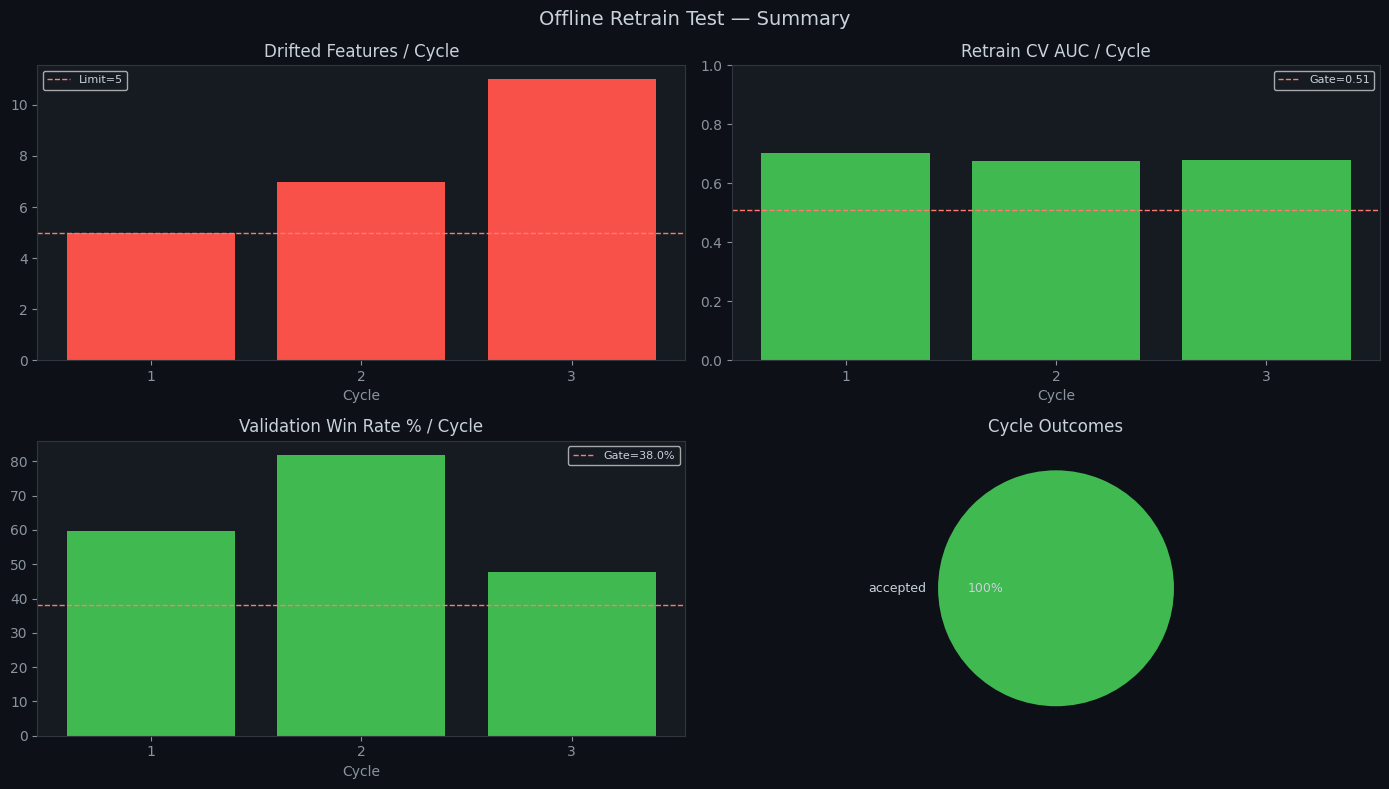

💾 Chart saved to /content/retrain_summary.png


In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if '_retrain_summary' not in dir() or _retrain_summary.empty:
    print('No retrain log found — run Cell 12 first.')
else:
    df_s = _retrain_summary.copy()
    n    = len(df_s)
    cycles = df_s['cycle'].astype(str).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#0d1117')
    fig.suptitle('Offline Retrain Test — Summary', color='#c9d1d9', fontsize=14)
    for ax in axes.flat:
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#8b949e')
        ax.spines[:].set_color('#30363d')

    # ── Plot 1: Drifted features per cycle ────────────────────────────────────
    ax = axes[0, 0]
    colors = ['#f85149' if d >= RETRAIN_DRIFT_FEATURE_LIMIT else '#58a6ff'
              for d in df_s['drifted']]
    ax.bar(cycles, df_s['drifted'], color=colors)
    ax.axhline(RETRAIN_DRIFT_FEATURE_LIMIT, color='#ff7b72', ls='--', lw=1, label=f'Limit={RETRAIN_DRIFT_FEATURE_LIMIT}')
    ax.set_title('Drifted Features / Cycle', color='#c9d1d9')
    ax.set_xlabel('Cycle', color='#8b949e')
    ax.legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=8)

    # ── Plot 2: CV AUC per cycle ──────────────────────────────────────────────
    ax = axes[0, 1]
    if 'cv_auc' in df_s.columns:
        auc_vals = df_s['cv_auc'].fillna(0)
        bar_colors = ['#3fb950' if v >= RETRAIN_VALIDATION_MIN_AUC else '#f85149' for v in auc_vals]
        ax.bar(cycles, auc_vals, color=bar_colors)
        ax.axhline(RETRAIN_VALIDATION_MIN_AUC, color='#ff7b72', ls='--', lw=1,
                   label=f'Gate={RETRAIN_VALIDATION_MIN_AUC}')
        ax.set_ylim(0, 1)
        ax.set_title('Retrain CV AUC / Cycle', color='#c9d1d9')
        ax.set_xlabel('Cycle', color='#8b949e')
        ax.legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No AUC data\n(no retrains triggered)',
                ha='center', va='center', color='#8b949e', transform=ax.transAxes)
        ax.set_title('Retrain CV AUC / Cycle', color='#c9d1d9')

    # ── Plot 3: Win rate per cycle ────────────────────────────────────────────
    ax = axes[1, 0]
    if 'win_rate' in df_s.columns:
        wr_vals = df_s['win_rate'].fillna(0)
        wr_colors = ['#3fb950' if v >= RETRAIN_VALIDATION_MIN_WR else '#f85149' for v in wr_vals]
        ax.bar(cycles, wr_vals, color=wr_colors)
        ax.axhline(RETRAIN_VALIDATION_MIN_WR, color='#ff7b72', ls='--', lw=1,
                   label=f'Gate={RETRAIN_VALIDATION_MIN_WR}%')
        ax.set_title('Validation Win Rate % / Cycle', color='#c9d1d9')
        ax.set_xlabel('Cycle', color='#8b949e')
        ax.legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No win-rate data\n(no retrains triggered)',
                ha='center', va='center', color='#8b949e', transform=ax.transAxes)
        ax.set_title('Validation Win Rate % / Cycle', color='#c9d1d9')

    # ── Plot 4: Outcome status ────────────────────────────────────────────────
    ax = axes[1, 1]
    reasons = df_s['reason'].value_counts()
    pie_colors = {
        'accepted':         '#3fb950',
        'below_drift_limit':'#58a6ff',
        'gate_failed':      '#f85149',
        'no_trades':        '#ff7b72',
        'train_error':      '#6e7681',
    }
    wedge_colors = [pie_colors.get(r, '#8b949e') for r in reasons.index]
    ax.pie(reasons.values, labels=reasons.index, colors=wedge_colors,
           autopct='%1.0f%%', textprops={'color': '#c9d1d9', 'fontsize': 9})
    ax.set_title('Cycle Outcomes', color='#c9d1d9')

    plt.tight_layout()
    plt.savefig('/content/retrain_summary.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
plt.close('all')  # v37
print('💾 Chart saved to /content/retrain_summary.png')

In [51]:
# ── Cell 14: Export artifacts (P8 — unified artifact bundle) ──────────────
# Downloads model directory as zip + confirms the unified artifact is present.
import shutil, sys, json as _json
from pathlib import Path
from datetime import datetime as _dt
import joblib as _jl

BROWSER_DOWNLOAD = True   # Set False to only print paths
ALSO_COPY_ZIP_TO = None   # e.g. Path('/content/drive/MyDrive/JackSparrow_v24.zip')

root = Path(MODEL_DIR)
_artifact = None # Initialize _artifact

if not root.is_dir() or not any(root.iterdir()):
    print(f'No artifacts under {root} — run Cell 7 first.')
else:
    # ── P8: confirm / create unified artifact ────────────────────────────
    artifact_path = root / f'model_artifact_{MODEL_VERSION}.pkl'
    if artifact_path.exists():
        print(f'✅ Unified artifact present: {artifact_path}')
        _artifact = _jl.load(artifact_path) # Load artifact if it exists
    else:
        print(f'⚠️  {artifact_path.name} not found — recreating from saved parts ...')
        _m = EnsembleModel()
        _m.load(str(root))
        _fe = _jl.load(str(root / 'feature_engineer.pkl')) if (root / 'feature_engineer.pkl').exists() else None
        _artifact = {
            'model':    _m,
            'features': _m.feature_cols,
            'scaler':   _m.scaler,
            'feature_engineer': _fe,
            'metrics':  None, # metrics might not be available if recreated this way, setting to None
            'metadata': {'version': MODEL_VERSION, 'recreated_at': _dt.utcnow().isoformat(), 'rethink': f'{MODEL_VERSION}-feature-reduction|atr-target|unified-threshold|sortino|hybrid-retrain'},
        }
        _jl.dump(_artifact, str(artifact_path))
        print(f'✅ Unified artifact saved: {artifact_path}')

    # ── Write human-readable metadata sidecar ────────────────────────────
    meta_path = root / f'metadata_{MODEL_VERSION}.json'
    export_features = (
        _artifact['features']
        if _artifact is not None and 'features' in _artifact # Check if _artifact is not None before accessing it
        else (model.feature_cols if 'model' in globals() and getattr(model, 'feature_cols', None) else FEATURE_COLS)
    )
    meta = {
        'version':    MODEL_VERSION,
        'symbol':     SYMBOL_5M,
        'exported_at': _dt.utcnow().isoformat(),
        'feature_count': len(export_features),
        'features':   export_features,
        'agent_load': (
            'artifact = joblib.load(MODEL_ARTIFACT_PATH)\n'
            'model    = artifact["model"]\n'
            'features = artifact["features"]\n'
            'fe       = artifact["feature_engineer"]\n'
            'df_feat  = fe.transform(df5, df15, df1h, df_funding, include_target=False)\n'
            'assert len(df_feat) >= 2, "Need at least 2 rows to use the last closed bar"\n'
            'X        = df_feat[features].iloc[[-2]].values\n'
            'X_df     = df_feat[features].iloc[[-2]]\n'
            'proba    = model.predict_proba(X, X_df=X_df)'
        ),
    }
    meta_path.write_text(_json.dumps(meta, indent=2))
    print(f'✅ Metadata sidecar: {meta_path}')

    # ── Zip and download ─────────────────────────────────────────────────
    safe_sym = str(SYMBOL_5M).replace('/', '_')
    if 'google.colab' in sys.modules:
        zip_base = str(Path('/content') / f'{EXPORT_ZIP_NAME}_{safe_sym}')
    else:
        zip_base = str(Path.cwd() / f'{EXPORT_ZIP_NAME}_{safe_sym}')
    zip_path = zip_base + '.zip'
    shutil.make_archive(zip_base, 'zip', root_dir=str(root.parent), base_dir=root.name)
    print(f'✅ Archive: {zip_path}')
    if ALSO_COPY_ZIP_TO is not None:
        dest = Path(ALSO_COPY_ZIP_TO)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(zip_path, dest)
        print(f'✅ Copied to: {dest}')
    if BROWSER_DOWNLOAD and 'google.colab' in sys.modules:
        from google.colab import files
        files.download(zip_path)
        print('✅ Browser download started.')
    elif not BROWSER_DOWNLOAD:
        print('BROWSER_DOWNLOAD=False — copy from path above.')

print('\n📦 Agent load snippet:')
print('   artifact = joblib.load(MODEL_ARTIFACT_PATH)')
print('   model    = artifact["model"]')
print('   fe       = artifact["feature_engineer"]')
print('   df_feat  = fe.transform(df5, df15, df1h, df_funding, include_target=False)')
print('   assert len(df_feat) >= 2, "Need at least 2 rows to use the last closed bar"')
print('   X        = df_feat[artifact["features"]].iloc[[-2]].values')
print('   X_df     = df_feat[artifact["features"]].iloc[[-2]]')
print('   proba    = model.predict_proba(X, X_df=X_df)')

✅ Unified artifact present: /content/models/model_artifact_v39.pkl
✅ Metadata sidecar: /content/models/metadata_v39.json
✅ Archive: /content/JackSparrow_v39_models_BTCUSD.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Browser download started.

📦 Agent load snippet:
   artifact = joblib.load(MODEL_ARTIFACT_PATH)
   model    = artifact["model"]
   fe       = artifact["feature_engineer"]
   df_feat  = fe.transform(df5, df15, df1h, df_funding, include_target=False)
   assert len(df_feat) >= 2, "Need at least 2 rows to use the last closed bar"
   X        = df_feat[artifact["features"]].iloc[[-2]].values
   X_df     = df_feat[artifact["features"]].iloc[[-2]]
   proba    = model.predict_proba(X, X_df=X_df)
